# Modelling the Health Condition of Machines Using Sub-Gaussian Distributions

**Course:** Computer Modelling and Simulation of Stochastic Processes  
**Authors:** Mateusz Ćwiek, Rafał Głodek, Hubert Nowak, Romain Steffein, Kacper Ujma

The notebook is organized as a project report. It first introduces the modelling assumptions, then presents the one-dimensional model, its simulation and estimation pipeline, extends the same idea to the two-dimensional sub-Gaussian model, and finally applies the pipeline to the IMS Bearing Dataset. The Monte Carlo parts are intentionally left as executable cells with the parameters used in the study; they may take longer to recompute than the single-trajectory examples.

-----

### Imports

In [42]:
import importlib
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import simulation1d
import estimation1d
import simulation2d
import estimation2d
import plotting_utils
import monte_carlo_utils

importlib.reload(simulation1d)
importlib.reload(estimation1d)
importlib.reload(simulation2d)
importlib.reload(estimation2d)
importlib.reload(plotting_utils)
importlib.reload(monte_carlo_utils)

from simulation1d import simulate_1d_model
from estimation1d import estimate_1d_model, summarize_1d_estimation, estimate_1d_model_fixed_ar_order
from simulation2d import simulate_2d_model
from estimation2d import estimate_2d_model_fixed_var1, summarize_2d_estimation
from monte_carlo_utils import (
    run_mc_1d_for_alpha,
    run_mc_2d_for_alpha,
)
from plotting_utils import (
    add_regime_annotations,
    plot_2d_acf_ccf_diagnostics,
    plot_mc_1d_acf_after_ar,
    plot_mc_1d_acf_before_ar,
    plot_mc_1d_alpha_boxplots,
    plot_mc_1d_phi_boxplots,
    plot_mc_1d_residual_trajectories,
    plot_mc_1d_scale_trajectories,
    plot_mc_1d_trend_trajectories,
    plot_real_acf_ccf_diagnostics,
)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


## Introduction and Motivation

Machine condition monitoring is the continuous observation of a machine during operation using signals from vibration sensors, acoustic sensors or other diagnostic measurements. The practical goal is to detect deterioration early enough to support predictive maintenance decisions: replacing or inspecting a component before a failure causes downtime, secondary damage or safety risk.

A health index (HI) is a lower-dimensional diagnostic signal constructed from raw measurements. Instead of modelling millions of vibration samples directly, the project models a time series whose level and variability summarize machine condition. The expected degradation path is divided into regimes: a **normal / healthy state**, a **warning / degradation state**, and an **alarm / critical state**. In synthetic data these regimes are controlled by predefined change points; in real data they must be detected or taken from a documented reference analysis.

Stochastic modelling is needed because degradation signals are not deterministic curves. Even after trend extraction, they contain random fluctuations, temporal dependence and occasional impulses. The seminar materials and reference thesis motivate alpha-stable and sub-Gaussian models because they can represent heavy-tailed behaviour that is not captured well by purely Gaussian noise.


-----

## One-dimensional degradation model

The aim of the model is to describe the evolution of a single machine health index over time. A health index usually reflects the condition of a machine component and is expected to change as the machine gradually degrades.

Let ${S(t)}$ denote the observed one-dimensional health index. The model assumes that $S(t)$ consists of two parts:

$$
S(t) = R(t) + T(t),
$$

where:

* $R(t)$ is the random component,
* $T(t)$ is the deterministic trend component.

The deterministic trend describes the general direction of degradation, while the random component represents fluctuations around this trend.

The degradation process is divided into three regimes. The change points between regimes are denoted by $\tau_1$ and $\tau_2$, where:

$$
1 < \tau_1 < \tau_2 < N.
$$

The three regimes can be interpreted as:

1. normal operating state,
2. warning state with visible degradation,
3. critical state with fast degradation.

### Random component

The random component is modeled as

$$
R(t) = SC(t) R_2(t),
$$

where:

* $SC(t)$ is a time-dependent scale function,
* $R_2(t)$ is a stationary autoregressive process.

The scale function allows the variability of the signal to increase over time, which reflects the fact that a degrading machine often produces more unstable measurements.

The process $R_2(t)$ is assumed to follow an autoregressive model of order $p$, denoted by AR($p$):

$$
R_2(t) - \phi_1 R_2(t-1) - \dots - \phi_p R_2(t-p) = R_3(t),
$$

where $\phi_1, \dots, \phi_p$ are autoregressive coefficients and $R_3(t)$ is an independent noise sequence.

In this model, the noise does not have to be Gaussian. Instead, it is assumed to follow a symmetric $\alpha$-stable distribution. This makes the model more flexible, because $\alpha$-stable distributions allow heavy tails and extreme observations.

A standard symmetric $\alpha$-stable random variable has characteristic function

$$
\varphi(t) = \exp(-|t|^\alpha),
$$

where $\alpha \in (0,2]$ is the stability parameter.

The parameter $\alpha$ controls the heaviness of the tails. For $\alpha = 2$, the distribution becomes Gaussian. For $\alpha < 2$, the distribution is non-Gaussian and heavy-tailed, which makes it suitable for modeling impulsive disturbances.

### Scale function

The scale function $SC(t)$ changes its form depending on the degradation regime. In the first two regimes it grows linearly, while in the third regime it grows exponentially:

$$
SC(t) =
\begin{cases}
a_1t + b_1, & 0 < t \leq \tau_1, \\
a_2t + b_2, & \tau_1 < t \leq \tau_2, \\
a_3 \exp(b_3t), & \tau_2 < t \leq N.
\end{cases}
$$

The parameters of this function are determined from boundary conditions:

$$
SC(1) = \sigma_1, \quad
SC(\tau_1) = \sigma_2, \quad
SC(\tau_2) = \sigma_3, \quad
SC(N) = \sigma_4.
$$

These values describe how the variability of the health index changes during the lifetime of the machine.

### Trend function

The trend function $T(t)$ represents the deterministic part of degradation. It is constant in the first regime, linear in the second regime, and exponential in the third regime:

$$
T(t) =
\begin{cases}
c_1, & 0 < t \leq \tau_1, \\
a_2t + c_2, & \tau_1 < t \leq \tau_2, \\
a_3 \exp(b_3t) + c_3, & \tau_2 < t \leq N.
\end{cases}
$$

The constants $c_2$ and $c_3$ are chosen so that the trend function is continuous at the regime change points $\tau_1$ and $\tau_2$.

The trend and scale functions have similar shapes in the second and third regimes. This means that as degradation becomes stronger, both the expected level of the health index and its variability increase.

### Final form of the model

The complete one-dimensional degradation model is therefore

$$
S(t) = SC(t)R_2(t) + T(t),
$$

where $R_2(t)$ follows an AR($p$) model with symmetric $\alpha$-stable noise.

This structure allows the model to capture three important properties of machine health indices:

* non-stationary trend caused by degradation,
* increasing variability over time,
* heavy-tailed random fluctuations caused by impulsive noise.

Therefore, the model is suitable for describing health index trajectories in which the machine condition changes slowly at first and then deteriorates rapidly near the end of its useful lifetime.

-----

## Simulation of artificial data from the 1D model

In this part, we generate artificial trajectories of a one-dimensional health index using the degradation model

$$
S(t) = SC(t)R_2(t) + T(t).
$$

The model combines three elements:

* $T(t)$ - deterministic trend describing the general degradation path,
* $SC(t)$ - time-dependent scale controlling the increasing variability,
* $R_2(t)$ - autoregressive random component.

The simulation is divided into three degradation regimes. In the first regime, the machine works under normal conditions. In the second regime, degradation becomes visible. In the third regime, degradation accelerates rapidly.

We use the following parameters:

$$
N = 2000, \qquad \tau_1 = \frac{N}{3}, \qquad \tau_2 = \frac{2N}{3}, \qquad \phi = 0.5.
$$

The scale increases from $\sigma_1 = 1$ to $\sigma_4 = 25$, while the trend starts from $c_1 = 10$. The random component follows an AR(1) process with symmetric $\alpha$-stable noise.

By changing the value of $\alpha$, we can control the heaviness of the noise tails. For $\alpha = 2$, the noise is Gaussian. For $\alpha < 2$, the noise is heavy-tailed and may contain impulsive observations.

The goal of this simulation is to show that the proposed model can generate artificial health-index trajectories with realistic degradation behavior: slow changes at the beginning, increasing variability over time, and rapid deterioration near the end of the observation period.

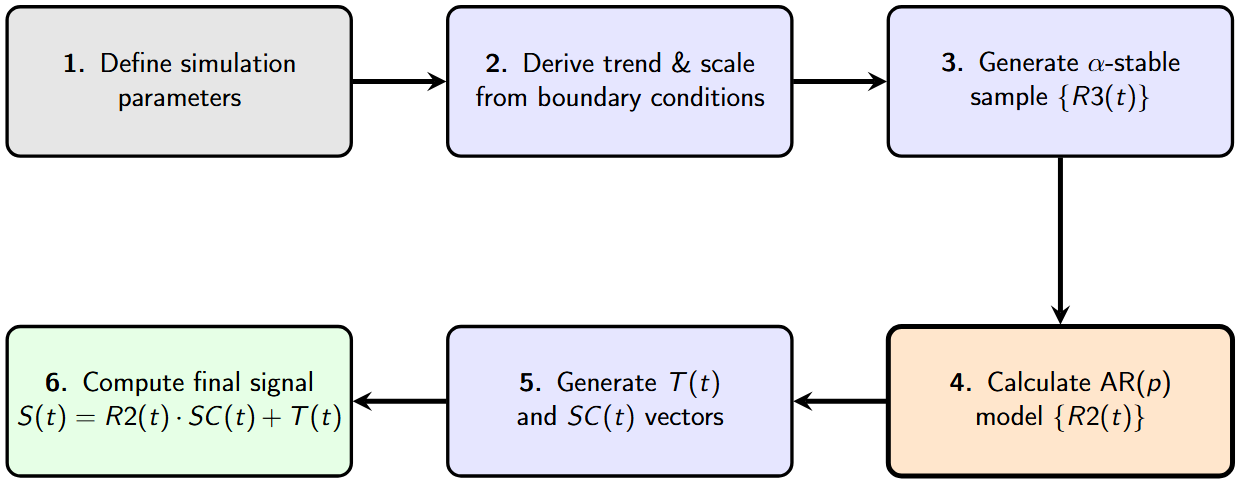

In [43]:
N = 2000
tau1 = N / 3
tau2 = 2 * N / 3

base_params = dict(
    N=N,
    tau1=tau1,
    tau2=tau2,
    phi=(0.5,),
    gamma=1.0,
    sigma1=1.0,
    sigma2=2.5,
    sigma3=5.0,
    sigma4=25.0,
    c1=10.0,
)

In [ ]:
simulation = simulate_1d_model(
    **base_params,
    alpha=1.9,
    random_state=42,
)

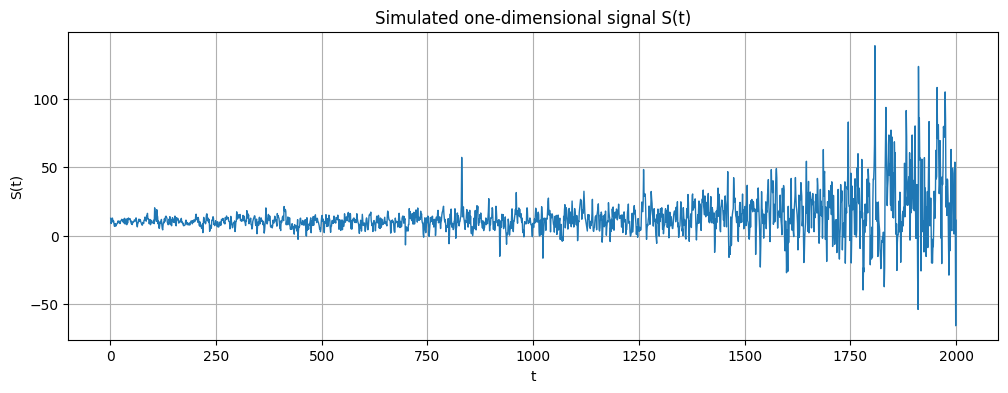

In [45]:
t = simulation["t"]

plt.figure(figsize=(12, 4))
plt.plot(t, simulation["S"], linewidth=1)
plt.title("Simulated one-dimensional signal S(t)")
plt.xlabel("t")
plt.ylabel("S(t)")
plt.grid(True)
plt.show()

The simulated degradation signal clearly illustrates the three operating regimes defined in the model. During the initial stage, the machine operates under normal conditions, and the signal exhibits relatively low variability around the baseline trend. In the second stage, the degradation process becomes noticeable, leading to a gradual increase in both the trend and the signal variability. In the final stage, the signal becomes highly volatile, with large fluctuations reflecting the accelerated degradation phase that typically precedes machine failure.

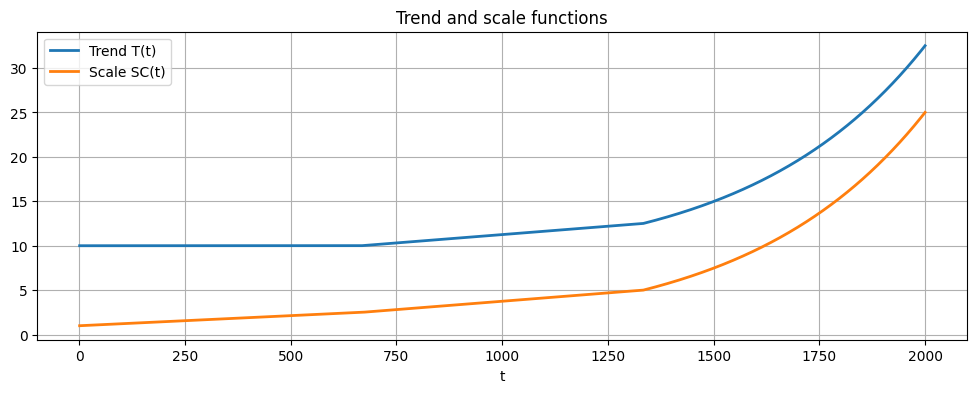

In [46]:
plt.figure(figsize=(12, 4))
plt.plot(t, simulation["T"], label="Trend T(t)", linewidth=2)
plt.plot(t, simulation["SC"], label="Scale SC(t)", linewidth=2)
plt.title("Trend and scale functions")
plt.xlabel("t")
plt.legend()
plt.grid(True)
plt.show()

The figure illustrates the deterministic components of the degradation model: the trend function $T(t)$ and the scale function $SC(t)$. Both functions are divided into three regimes corresponding to different stages of machine degradation. During the initial stage, the trend remains nearly constant, while the scale increases only slightly, representing stable machine operation with low variability. In the second stage, both functions begin to increase gradually, indicating the onset of degradation and a moderate rise in signal variability. In the final stage, the trend and the scale grow rapidly, reflecting accelerated deterioration of the machine. The increasing scale models the higher uncertainty and larger fluctuations that typically occur as the machine approaches failure.

-----

## Estimation procedure for 1D model

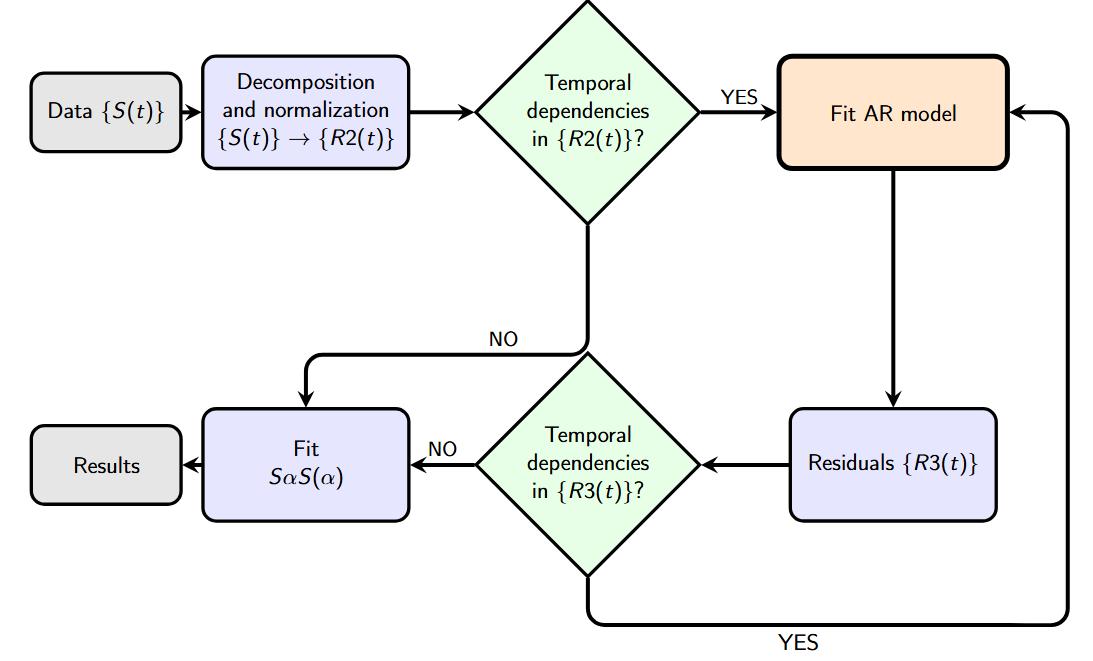

### 1. Data: $S(t)$

The starting point is the observed one-dimensional signal

$$
\{S(t)\}_{t=1}^{N}.
$$

In the context of machine condition monitoring, $S(t)$ represents a health index trajectory. It is obtained from raw sensor measurements by feature extraction, for example by using RMS, variance, kurtosis or another diagnostic feature. The signal is not assumed to be stationary, because during degradation both its trend and variability may change over time.

---

### 2. Decomposition and normalization: $S(t)\to R2(t)$

The first step is to separate the deterministic trend from the observed signal. The trend is estimated using the moving median in a window of length $w$:

$$
\widehat{T}(t)=MM_w(S(t)).
$$

Then the random component is obtained as

$$
\widehat{R}(t)=S(t)-\widehat{T}(t).
$$

The moving median is used instead of the moving average because the signal may contain extreme observations caused by heavy-tailed or impulsive noise.

Next, the time-varying scale is estimated locally from $\widehat{R}(t)$. For this purpose, a robust scale estimator of Rousseeuw-Croux type is used:

$$
SC_x^Q
=
d\{|x_i-x_j|;\ i<j\}_{(k)}.
$$

Here $d$ is a normalizing constant, ${.}_{(k)}$ denotes the $k$-th order statistic, and the estimator is computed from pairwise absolute differences inside a local window. In the moving-window procedure this gives the estimated scale function

$$
\widehat{SC}(t).
$$

After removing the scale effect, the normalized component is defined as

$$
\widehat{R2}(t)
=
\frac{\widehat{R}(t)}{\widehat{SC}(t)}.
$$

This step is important because the autoregressive modelling is performed on the normalized component, which should be closer to stationarity than the original signal.

---

### 3. Checking temporal dependencies in $R2(t)$

After normalization, we check whether the process $\{\widehat{R2}(t)\}$ still contains temporal dependence. This is done using the robust autocorrelation function.

For a stationary signal $\mathbf{x}={x_1,\dots,x_n}$ and lag $h$, define

$$
\mathbf{u}=(x_1,\dots,x_{n-h}),
\qquad
\mathbf{v}=(x_{h+1},\dots,x_n).
$$

The robust ACF estimator is

$$
\widehat{\rho}_{\mathbf{x}}^Q(h)
=
\frac{
(SC_{\mathbf{u}+\mathbf{v}}^Q)^2
-
(SC_{\mathbf{u}-\mathbf{v}}^Q)^2
}{
(SC_{\mathbf{u}+\mathbf{v}}^Q)^2
+
(SC_{\mathbf{u}-\mathbf{v}}^Q)^2
}.
$$

If the estimated autocorrelations are close to zero for positive lags, then the normalized component can be treated as approximately independent and we can proceed directly to distribution fitting. If significant temporal dependence is present, an autoregressive model has to be fitted.

---

### 4. Fitting the AR model

If temporal dependence is detected in $\{\widehat{R2}(t)\}$, we model it using an autoregressive process of order $p$:

$$
R2(t)
=
\phi_1R2(t-1)+\dots+\phi_pR2(t-p)+R3(t),
$$

where $R3(t)$ is the residual noise sequence.

The parameters $\phi_1,\dots,\phi_p$ are estimated by a robust version of the Yule-Walker method. In the classical Yule-Walker equations,

$$
\mathbf{R}\boldsymbol{\phi}=\boldsymbol{\rho},
$$

the standard autocorrelations are replaced by robust ACF estimates. Thus,

$$
\widehat{\boldsymbol{\phi}}
=
\widehat{\mathbf{R}}^{-1}\widehat{\boldsymbol{\rho}},
$$

where $\widehat{\mathbf{R}}$ is constructed from robust autocorrelations and $\widehat{\boldsymbol{\rho}}$ contains robust autocorrelations for lags $1,\dots,p$.

The order $p$ can be selected by fitting several candidate models and checking the residual autocorrelation. For each candidate $p$, residuals are computed and the diagnostic statistic

$$
K(p)
=
\max_{h=1,\dots,h_{\max}}
\left|
\widehat{\rho}_{\widehat{R3}}^Q(h)
\right|^2
$$

is evaluated. A smaller value of $K(p)$ means that the residuals contain weaker temporal dependence. Therefore, the preferred AR order is the one for which the residual dependence is sufficiently small; if several orders give similar results, the simpler model is preferred.

---

### 5. Residuals: $R3(t)$

After fitting the AR model, the residual sequence is obtained as

$$
\widehat{R3}(t)
=
\widehat{R2}(t)
-
\sum_{j=1}^{p}
\widehat{\phi}_j\widehat{R2}(t-j).
$$

The residuals represent the part of the normalized signal that is not explained by the autoregressive dependence structure. Ideally, $\{\widehat{R3}(t)\}$ should behave like an independent noise sequence.

---

### 6. Checking temporal dependencies in $R3(t)$

The robust ACF is computed again, this time for the residual sequence $\{\widehat{R3}(t)\}$. The purpose of this step is to verify whether the AR model has successfully removed temporal dependence.

If the residual autocorrelations are still significant, the AR model is not sufficient and the fitting step should be repeated, for example with a different model order. If the residual autocorrelations are close to zero, the residuals can be treated as approximately independent and the procedure moves to distribution fitting.

---

### 7. Fitting the $S\alpha S(\alpha)$ distribution

Once the residual sequence has no visible temporal dependence, we fit a symmetric $\alpha$-stable distribution to $\{\widehat{R3}(t)\}$. The key parameter is the stability index $\alpha$, which controls the heaviness of the tails. Values close to $2$ correspond to Gaussian-like behaviour, while smaller values indicate heavier tails and more impulsive observations.

The stability index is estimated using McCulloch's quantile method. Let $x_q$ denote the empirical quantile of order $q$. The method uses the statistics

$$
v_{\alpha}
=
\frac{x_{0.95}-x_{0.05}}
{x_{0.75}-x_{0.25}},
$$

and

$$
v_{\beta}
=
\frac{x_{0.95}+x_{0.05}-2x_{0.5}}
{x_{0.95}-x_{0.05}}.
$$

Then the stability parameter is obtained from tabulated inverse functions:

$$
\widehat{\alpha}
=
\psi_1(v_{\alpha},v_{\beta}).
$$

In the symmetric case, the skewness parameter is expected to be close to zero, and the main quantity of interest is $\widehat{\alpha}$.

---

### 8. Results

The final output of the procedure consists of:

$$
\widehat{T}(t), \qquad
\widehat{SC}(t), \qquad
\widehat{R2}(t),
$$

the fitted AR parameters

$$
\widehat{p},
\qquad
\widehat{\phi}_1,\dots,\widehat{\phi}_{\widehat{p}},
$$

the residual sequence

$$
\widehat{R3}(t),
$$

and the estimated stability index

$$
\widehat{\alpha}.
$$


-----

## Monte Carlo Study for the 1D Model

The Monte Carlo study is the final validation of the one-dimensional estimation pipeline. Instead of discussing a separate single-trajectory estimation example, this section follows the same order as the estimation block diagram.

Because the data are simulated, the true trend, scale, AR coefficient and stability index are known. The purpose of the Monte Carlo experiment is to check whether the estimation procedure recovers them with acceptable bias and variability.

### 1. Monte Carlo setup

We simulate $M=100$ independent trajectories of length $N=2000$ for four stability-index values,

$$
\alpha\in\{1.85,1.90,1.95,2.00\}.
$$

The true autoregressive coefficient is $\phi_{true}=0.5$. The trend is estimated by a moving median with window 501, the scale by the robust moving $SC_Q$ estimator with window 151, and the AR order is fixed at 1 because the data-generating model is AR(1). The cell below either loads cached Monte Carlo results or recomputes them and saves the cache.

In [47]:
MC_1D_ALPHA_VALUES = [1.85, 1.90, 1.95, 2.00]
MC_1D_REPLICATIONS = 100
MC_1D_TRUE_PHI = base_params["phi"][0]
MC_1D_TREND_WINDOW = 501
MC_1D_SCALE_WINDOW = 151
MC_1D_AR_ORDER = 1
MC_1D_H_MAX = 30

alphas_order = MC_1D_ALPHA_VALUES
n_replications = MC_1D_REPLICATIONS

MC_1D_CACHE = Path("mc_1d_results_AR1_M100_alpha_185_190_195_200.pkl")
USE_CACHED_1D_MC = True
RECOMPUTE_1D_MC = False

mc_1d_setup = pd.DataFrame([{
    "N": base_params["N"],
    "alpha_values": MC_1D_ALPHA_VALUES,
    "replications": MC_1D_REPLICATIONS,
    "true_phi": MC_1D_TRUE_PHI,
    "trend_window": MC_1D_TREND_WINDOW,
    "scale_window": MC_1D_SCALE_WINDOW,
    "ar_order": MC_1D_AR_ORDER,
    "acf_max_lag": MC_1D_H_MAX,
    "cache_file": str(MC_1D_CACHE),
}])

mc_1d_setup

,N,alpha_values,replications,true_phi,trend_window,scale_window,ar_order,acf_max_lag,cache_file
0,2000,"[1.85, 1.9, 1.95, 2.0]",100,0.5,501,151,1,30,mc_1d_results_AR1_M100_alpha_185_190_195_200.pkl


In [48]:
if USE_CACHED_1D_MC and MC_1D_CACHE.exists() and not RECOMPUTE_1D_MC:
    with open(MC_1D_CACHE, "rb") as f:
        mc_1d_final = pickle.load(f)
    print(f"Loaded 1D Monte Carlo results from {MC_1D_CACHE}")
else:
    mc_1d_final = {}

    for idx, alpha in enumerate(MC_1D_ALPHA_VALUES):
        print(f"Running 1D Monte Carlo for alpha={alpha}...")
        mc_1d_final[alpha] = run_mc_1d_for_alpha(
            alpha=alpha,
            base_params=base_params,
            n_replications=MC_1D_REPLICATIONS,
            base_seed=10_000 + idx * 10_000,
            trend_window=MC_1D_TREND_WINDOW,
            scale_window=MC_1D_SCALE_WINDOW,
            h_max=MC_1D_H_MAX,
        )

    with open(MC_1D_CACHE, "wb") as f:
        pickle.dump(mc_1d_final, f)

    print(f"Computed and saved 1D Monte Carlo results to {MC_1D_CACHE}")

Loaded 1D Monte Carlo results from mc_1d_results_AR1_M100_alpha_185_190_195_200.pkl


### 2. Trend estimation

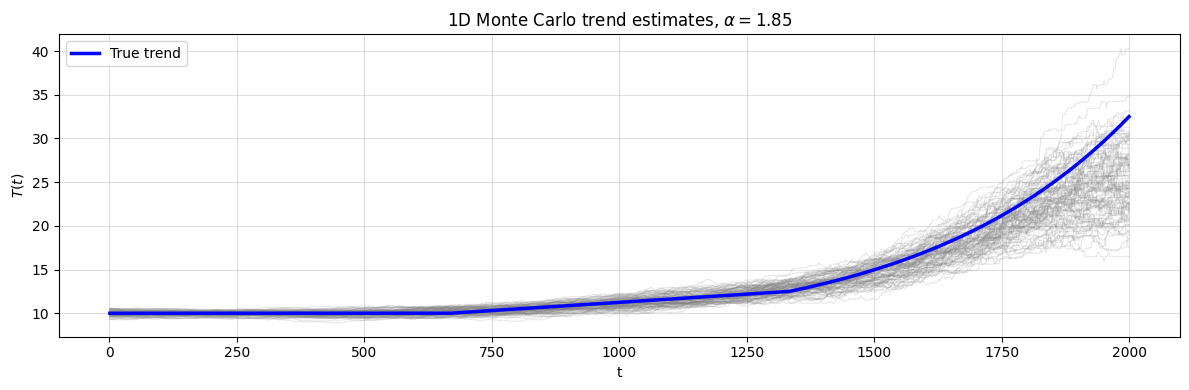

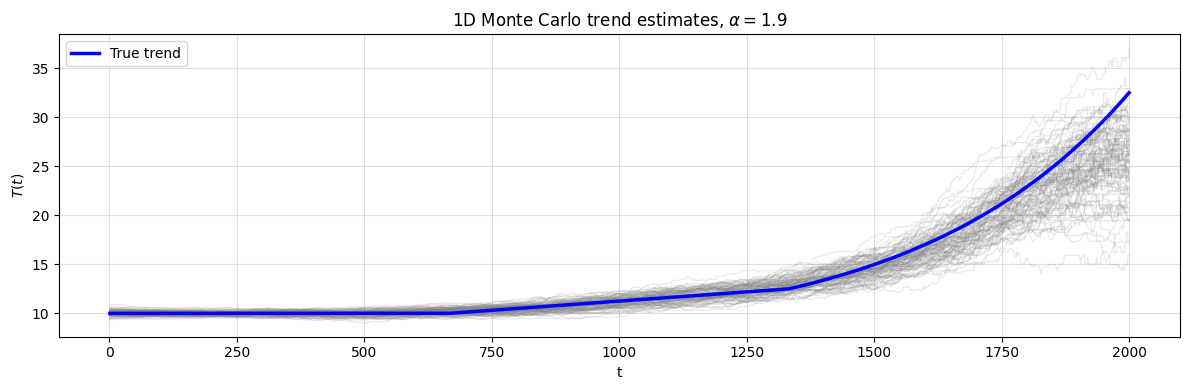

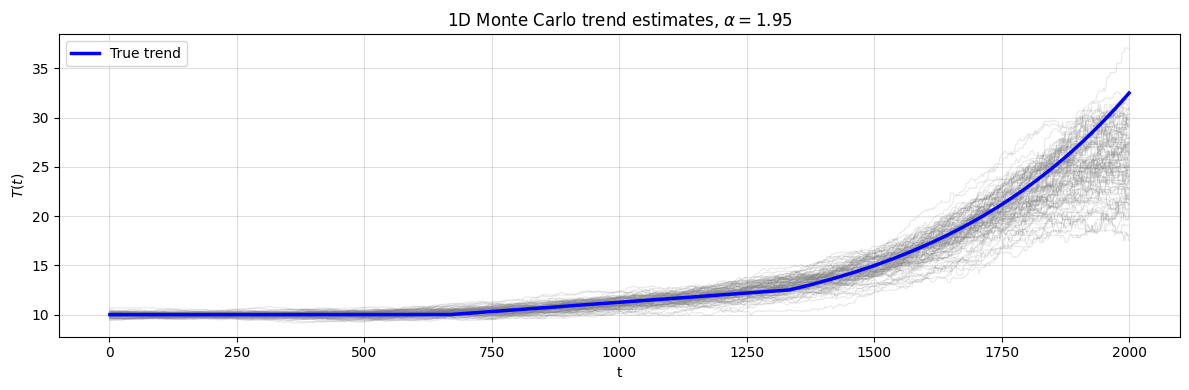

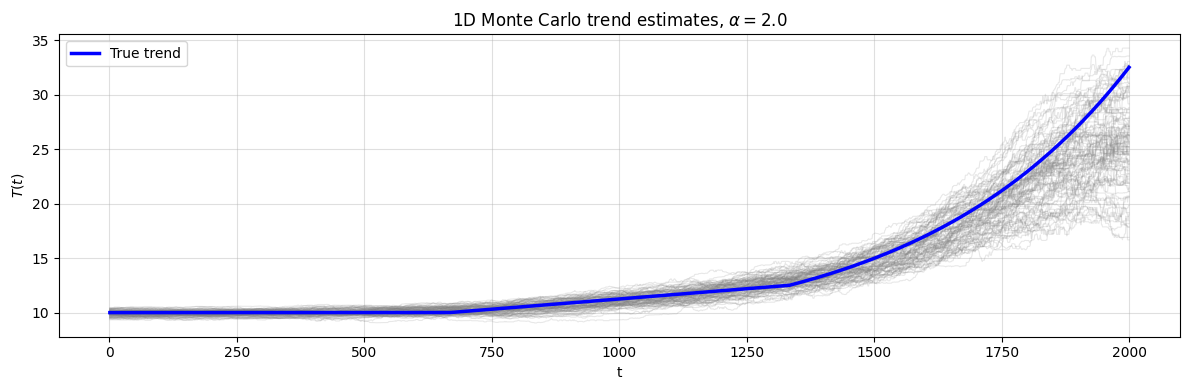

In [49]:
for alpha in MC_1D_ALPHA_VALUES:
    plot_mc_1d_trend_trajectories(mc_1d_final[alpha])

The figures show the trend estimates obtained from 100 independent Monte Carlo simulations for different values of the stability index $\alpha$. The blue curve denotes the true deterministic trend, whereas the gray curves represent the estimated trends for individual realizations. During the first degradation stage, the estimates are tightly clustered around the true trend, reflecting the low variability of the simulated signal. As the degradation progresses, the spread of the estimated trends gradually increases. The largest dispersion is observed in the final degradation regime, where the signal variability is intentionally amplified by the scale function. Despite the increasing diversity of individual estimates, the ensemble of trajectories follows the true degradation path, indicating that the estimator captures the underlying trend while reflecting the uncertainty introduced by the stochastic degradation process.

### 3. Scale estimation

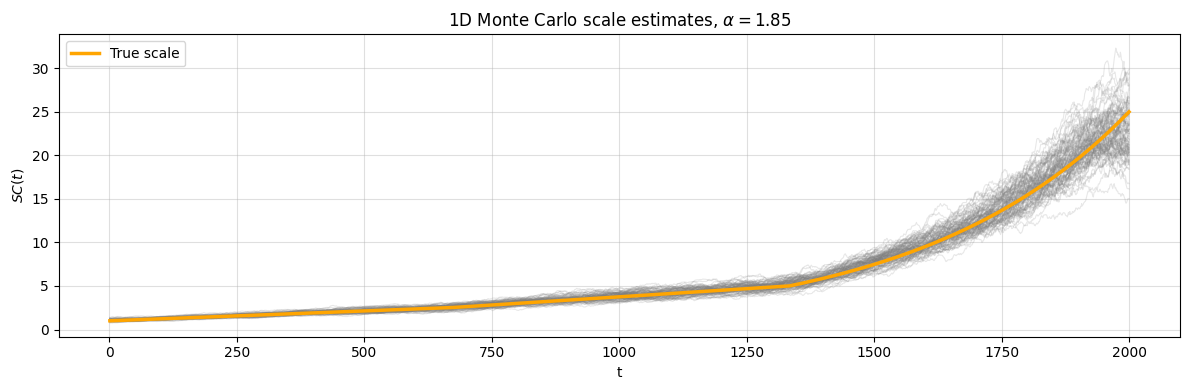

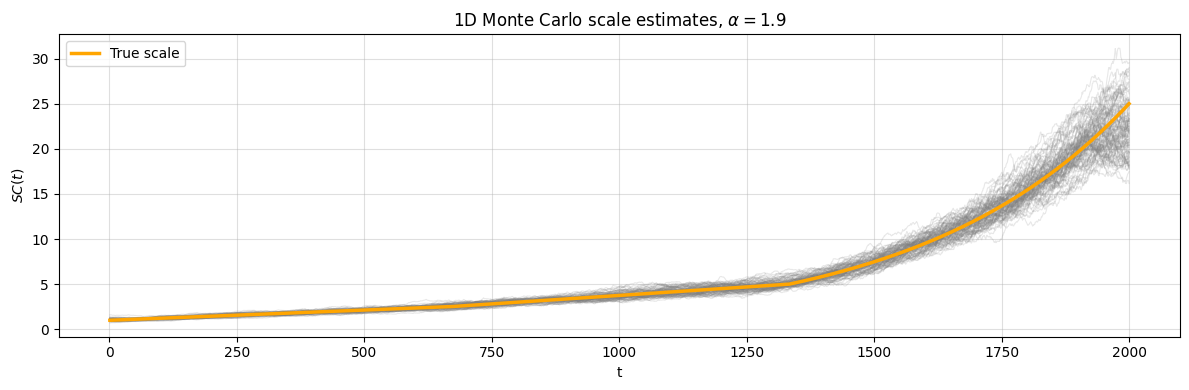

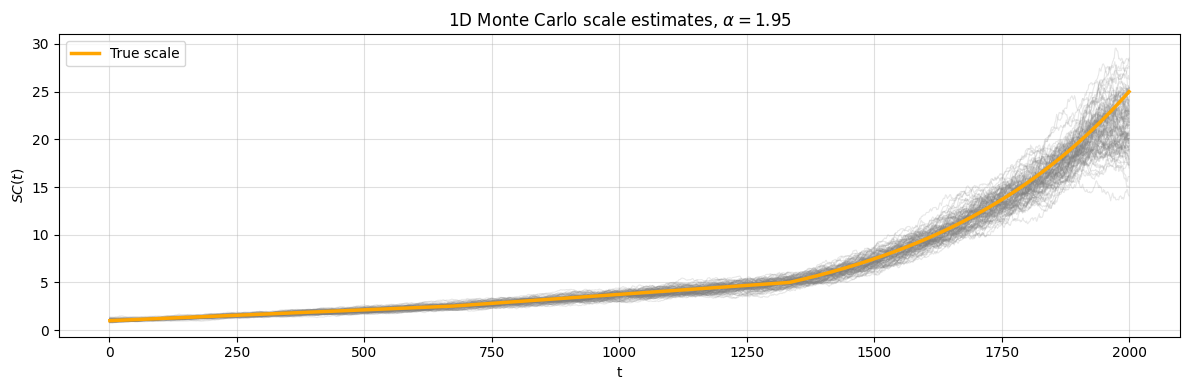

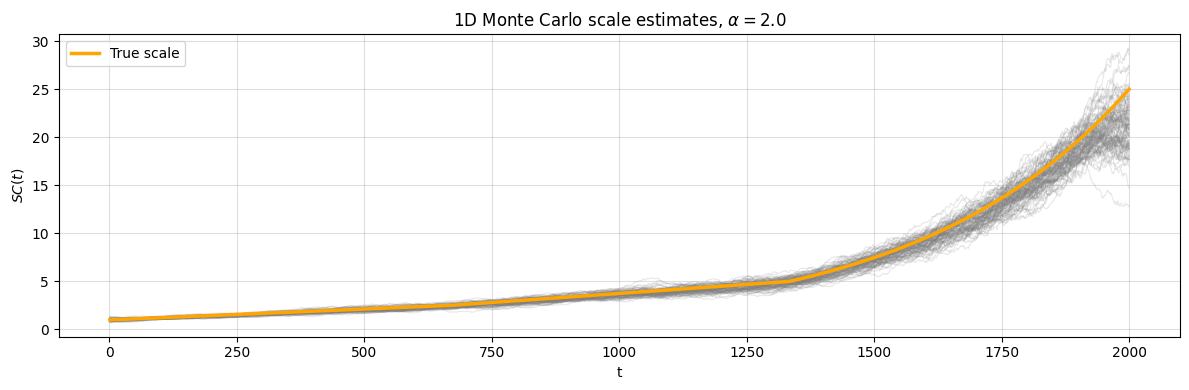

In [50]:
for alpha in MC_1D_ALPHA_VALUES:
    plot_mc_1d_scale_trajectories(mc_1d_final[alpha])

The figures present the Monte Carlo estimates of the scale function. The orange curve represents the true scale function, while the gray curves correspond to the estimated scales for individual simulations. During the early stage of degradation, the estimates remain tightly concentrated around the true scale, reflecting the relatively low variability of the signal. As the degradation progresses, the dispersion of the estimated scale functions gradually increases, with the largest differences appearing in the accelerated degradation regime. This behavior is expected because the underlying process becomes increasingly stochastic as the scale grows. Despite the larger spread near the end of the trajectories, the estimates consistently reproduce the overall increasing pattern of the true scale function, confirming that the robust scale estimator effectively captures the time-varying variability of the degradation process.

### 4. ACF before AR fitting


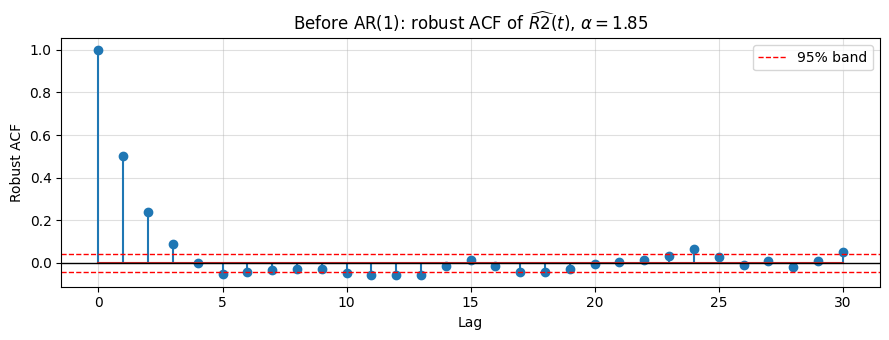

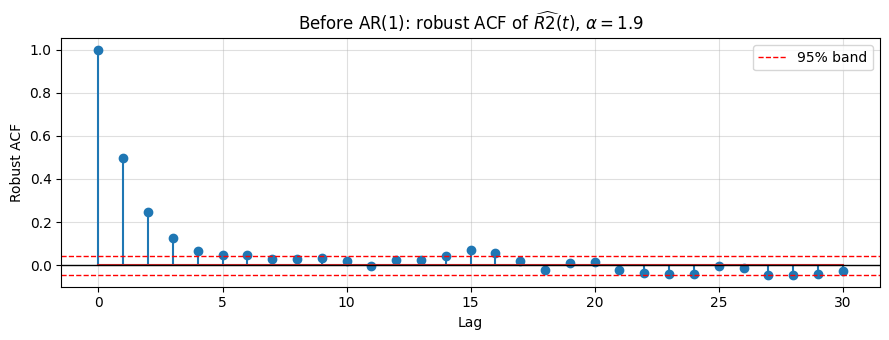

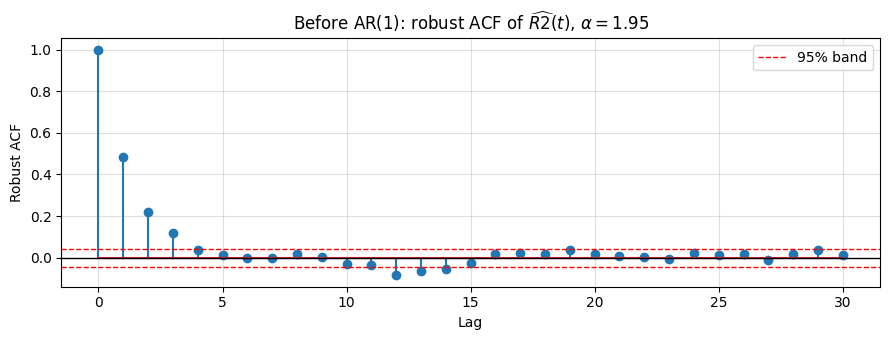

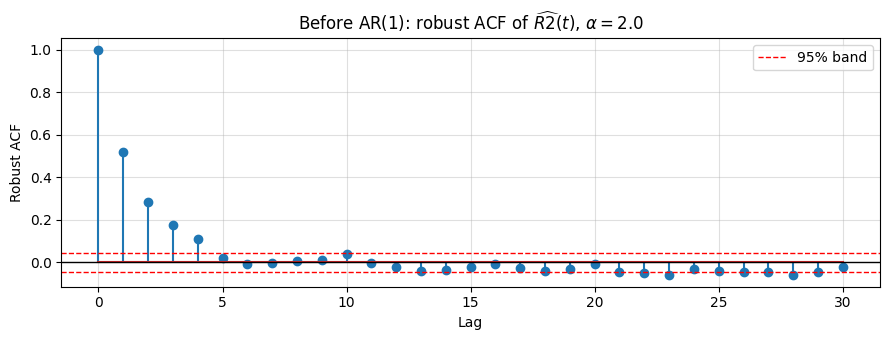

In [51]:
for alpha in MC_1D_ALPHA_VALUES:
    plot_mc_1d_acf_before_ar(mc_1d_final[alpha], ci_level=0.95)

The ACF plots show a strong autocorrelation at the first few lags, followed by a rapid decay, which is characteristic of an $AR(1)$ process. This confirms that temporal dependence remains after detrending and normalization, motivating the estimation of the $AR(1)$ coefficient in the next step.

### 5. AR parameter estimation

In [52]:
phi_summary_1d = pd.DataFrame([
    {
        "true_alpha": alpha,
        "true_phi": MC_1D_TRUE_PHI,
        "mean_phi_hat": np.mean(mc_1d_final[alpha]["phi_hats"]),
        "median_phi_hat": np.median(mc_1d_final[alpha]["phi_hats"]),
        "std_phi_hat": np.std(mc_1d_final[alpha]["phi_hats"], ddof=1),
        "n_replications": MC_1D_REPLICATIONS,
    }
    for alpha in MC_1D_ALPHA_VALUES
])

phi_summary_1d

,true_alpha,true_phi,mean_phi_hat,median_phi_hat,std_phi_hat,n_replications
0,1.85,0.5,0.506525,0.507124,0.020441,100
1,1.90,0.5,0.500638,0.502745,0.021544,100
2,1.95,0.5,0.496793,0.495754,0.020993,100
3,2.00,0.5,0.491720,0.494268,0.022605,100


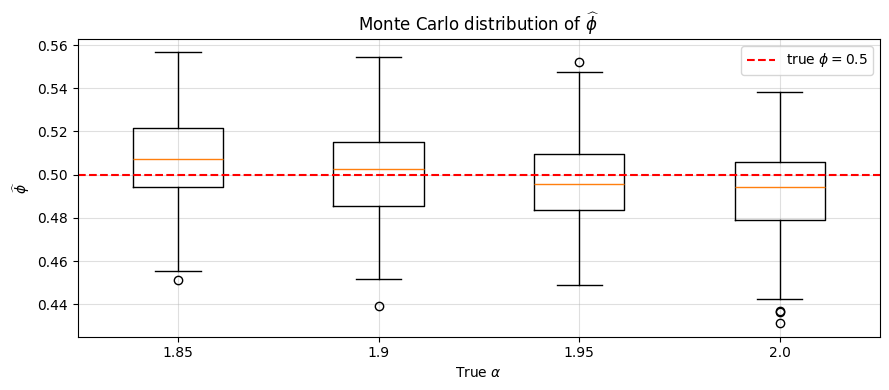

In [53]:
plot_mc_1d_phi_boxplots(
    mc_1d_final,
    MC_1D_ALPHA_VALUES,
    true_phi=MC_1D_TRUE_PHI,
)

The boxplots present the Monte Carlo distribution of the estimated AR(1) coefficient for different values of the stability index $\alpha$. In all considered scenarios, the estimates remain concentrated around the true value, $\phi = 0.5$, indicating that the proposed estimation procedure accurately recovers the temporal dependence of the process. Although a slight downward shift of the median can be observed as $\alpha$ increases, the differences are small and the estimated coefficients remain close to the true value. Overall, the results demonstrate that the robust AR(1) estimator provides stable and reliable estimates across the considered range of noise distributions.

### 6. Residuals

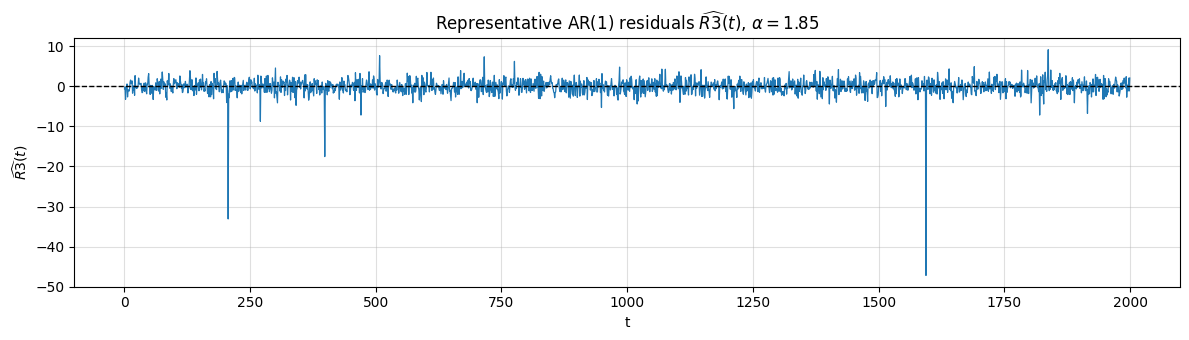

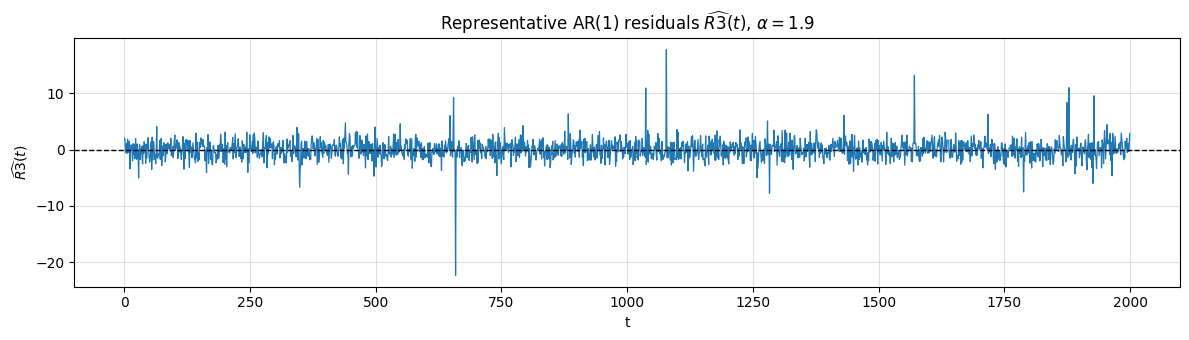

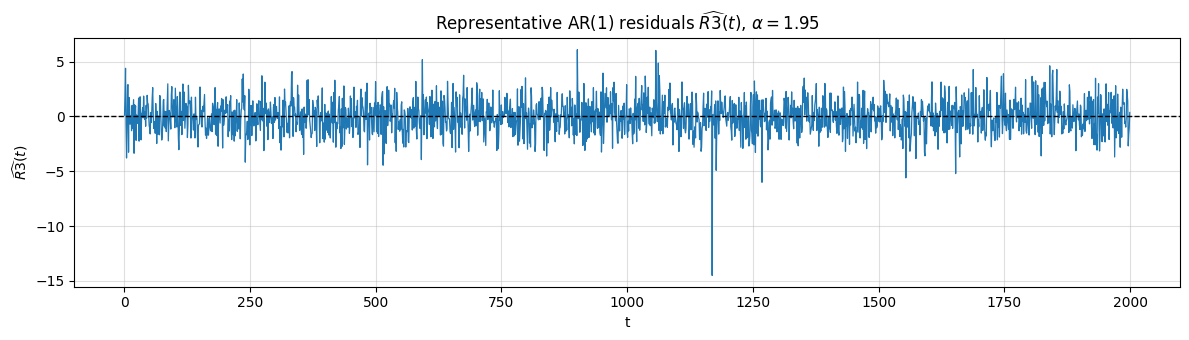

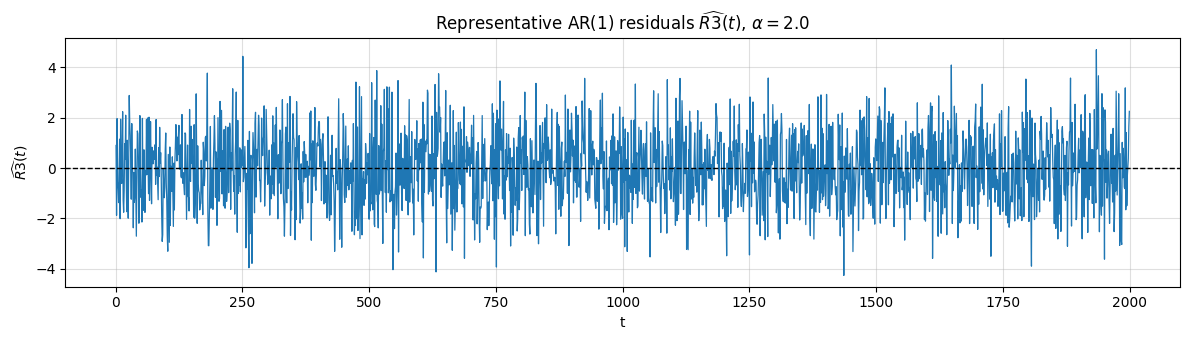

In [54]:
for alpha in MC_1D_ALPHA_VALUES:
    plot_mc_1d_residual_trajectories(mc_1d_final[alpha])

The representative residual trajectories oscillate around zero and no longer exhibit any visible systematic temporal structure. This indicates that the fitted AR(1) model has successfully captured the first-order dependence present in the normalized signal. Nevertheless, the residuals are not purely Gaussian. For smaller values of $\alpha$, occasional large positive and negative impulses are still observed, reflecting the heavy-tailed nature of the random noise. As $\alpha$ increases towards 2, these extreme observations become less frequent and the residual process appears more homogeneous. Overall, the residual plots suggest that the autoregressive component has been effectively removed, while the remaining variability is mainly due to the random fluctuations in the signal.

### 7. ACF after AR fitting

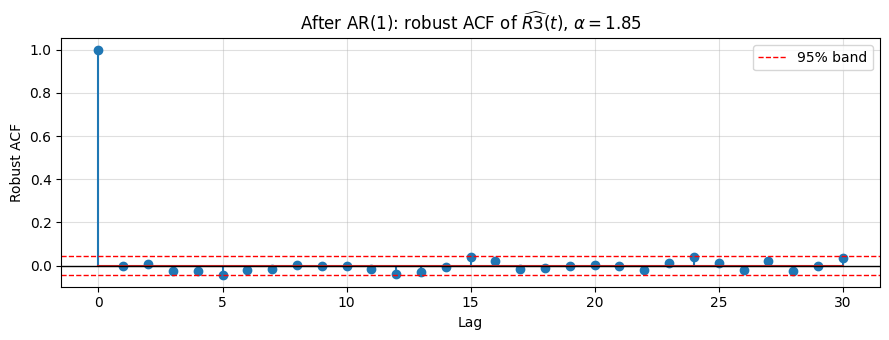

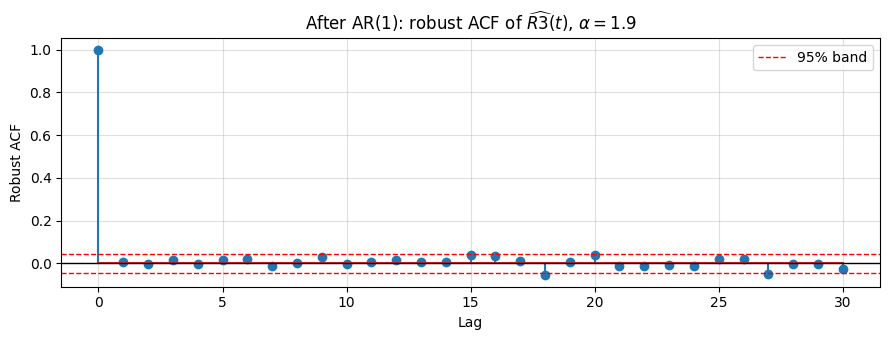

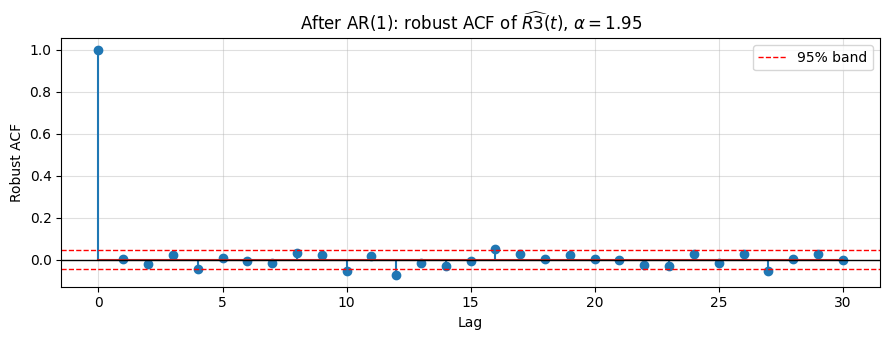

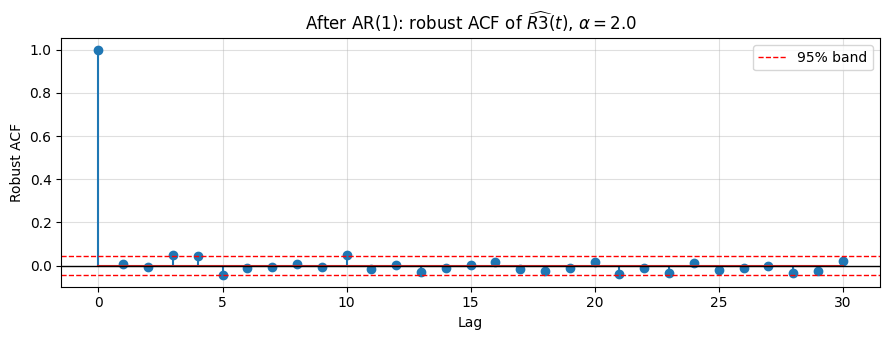

In [55]:
for alpha in MC_1D_ALPHA_VALUES:
    plot_mc_1d_acf_after_ar(mc_1d_final[alpha], ci_level=0.95)

The ACF plots of the residuals show that the temporal dependence observed before AR(1) modeling has been effectively removed. For all considered values of $\alpha$, the autocorrelation coefficients at non-zero lags are close to zero and mostly remain within the 95% confidence bounds, indicating the absence of significant serial correlation. Minor fluctuations outside the confidence limits are expected due to random variation and do not reveal any systematic dependence. Overall, the results confirm that the AR(1) model successfully captures the dominant temporal structure, leaving residuals that behave approximately as an uncorrelated random process.

### 8. Stability index estimation

In [56]:
alpha_summary_1d = pd.DataFrame([
    {
        "true_alpha": alpha,
        "mean_alpha_hat": np.mean(mc_1d_final[alpha]["alpha_hats"]),
        "median_alpha_hat": np.median(mc_1d_final[alpha]["alpha_hats"]),
        "std_alpha_hat": np.std(mc_1d_final[alpha]["alpha_hats"], ddof=1),
        "n_replications": MC_1D_REPLICATIONS,
    }
    for alpha in MC_1D_ALPHA_VALUES
])

alpha_summary_1d

,true_alpha,mean_alpha_hat,median_alpha_hat,std_alpha_hat,n_replications
0,1.85,1.867957,1.866071,0.072825,100
1,1.90,1.908314,1.913825,0.064777,100
2,1.95,1.939421,1.954353,0.057825,100
3,2.00,1.971059,2.000000,0.046542,100


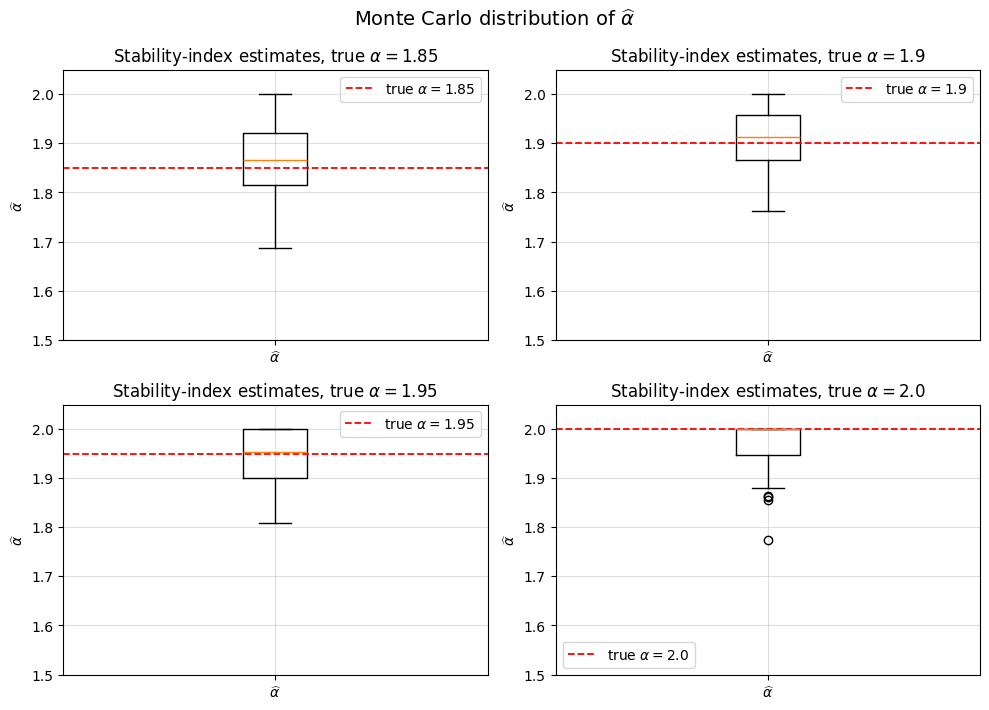

In [57]:
plot_mc_1d_alpha_boxplots(
    mc_1d_final,
    MC_1D_ALPHA_VALUES,
)

The boxplots show that the estimated stability index remains close to the true value for all considered scenarios. The estimates are concentrated around the corresponding values of $\alpha$, indicating that the proposed estimation procedure accurately captures the tail behaviour of the residual distribution. A slight tendency to overestimate the stability index can be observed for smaller values of $\alpha$. However, these deviations are small, and the estimator provides stable and reliable estimates across the entire range of considered stability indices.

-----

## Multidimensional degradation model

The one-dimensional degradation model can be extended to the multidimensional case in order to describe several health indices at the same time. This is useful when the condition of a machine is monitored using multiple sensors or when one raw signal is transformed into several diagnostic features.

Let ${S(t)}$ be a $k$-dimensional health-index process. For each time point $t$, we observe a vector

$$
S(t) =
\begin{pmatrix}
S_1(t) \\
\vdots \\
S_k(t)
\end{pmatrix}.
$$

The multidimensional degradation model is defined as

$$
S(t) = R(t) + T(t),
$$

where:

* $R(t)$ is the random vector component,
* $T(t)$ is the deterministic trend vector.

As in the one-dimensional case, the degradation process is divided into three regimes. The regime change points are denoted by $\tau_1$ and $\tau_2$, where

$$
1 < \tau_1 < \tau_2 < N.
$$

The same change points are used for all components of the vector process, because all health indices describe the degradation of the same machine or machine component.

### Random component

For each component $i = 1, \dots, k$, the random part is written as

$$
R_i(t) = SC_i(t)R_{2,i}(t),
$$

where:

* $SC_i(t)$ is the scale function of the $i$-th component,
* $R_{2,i}(t)$ is the $i$-th component of a stationary vector autoregressive process.

In vector form, the process $R_2(t)$ follows a VAR($p$) model:

$$
R_2(t) = \Theta_1 R_2(t-1) + \dots + \Theta_p R_2(t-p) + R_3(t),
$$

where:

* $\Theta_1, \dots, \Theta_p$ are $k \times k$ autoregressive matrices,
* $R_3(t)$ is a vector of random innovations.

The VAR model is a natural multidimensional extension of the AR model. It allows each component of the process to depend not only on its own past values, but also on past values of the other components. Therefore, it can describe cross-dependence between different health indices.

### Sub-Gaussian noise

In the multidimensional model, the innovation vector $R_3(t)$ is assumed to follow a multivariate sub-Gaussian symmetric $\alpha$-stable distribution.

This distribution can be constructed as

$$
R_3(t) = A_t^{1/2}G_t,
$$

where:

$$
G_t \sim N(0, \Sigma)
$$

is a $k$-dimensional Gaussian vector with covariance matrix $\Sigma$, and $A_t$ is a positive $\alpha/2$-stable random variable.

The parameter $\alpha \in (0,2]$ controls the heaviness of the distribution tails. For $\alpha = 2$, the model reduces to the Gaussian case. For $\alpha < 2$, the noise is heavy-tailed and can generate impulsive observations.

The covariance matrix $\Sigma$ controls the dependence structure between the components of the Gaussian vector used in the construction of the sub-Gaussian noise. As a result, the model can include both heavy-tailed behavior and dependence between different health indices.

### Scale vector

The scale vector is defined as

$$
SC(t) =
\begin{pmatrix}
SC_1(t) \\
\vdots \\
SC_k(t)
\end{pmatrix}.
$$

Each component $SC_i(t)$ has the same three-regime structure as in the one-dimensional case:

$$
SC_i(t) =
\begin{cases}
a_{1,i}t + b_{1,i}, & 0 < t \leq \tau_1, \\
a_{2,i}t + b_{2,i}, & \tau_1 < t \leq \tau_2, \\
a_{3,i}\exp(b_{3,i}t), & \tau_2 < t \leq N.
\end{cases}
$$

The parameters are determined from boundary conditions:

$$
SC_i(1) = \sigma_{1,i}, \quad
SC_i(\tau_1) = \sigma_{2,i}, \quad
SC_i(\tau_2) = \sigma_{3,i}, \quad
SC_i(N) = \sigma_{4,i}.
$$

This means that each health index can have its own scale dynamics, but all components follow the same degradation regimes.

### Trend vector

The deterministic trend vector is given by

$$
T(t) =
\begin{pmatrix}
T_1(t) \\
\vdots \\
T_k(t)
\end{pmatrix}.
$$

For each component $i = 1, \dots, k$, the trend is defined as

$$
T_i(t) =
\begin{cases}
c_{1,i}, & 0 < t \leq \tau_1, \\
a_{2,i}t + c_{2,i}, & \tau_1 < t \leq \tau_2, \\
a_{3,i}\exp(b_{3,i}t) + c_{3,i}, & \tau_2 < t \leq N.
\end{cases}
$$

The constants $c_{2,i}$ and $c_{3,i}$ are chosen so that the trend function is continuous at the regime change points $\tau_1$ and $\tau_2$.

The first regime corresponds to stable machine operation, so the trend is constant. In the second regime, degradation becomes visible and the trend increases linearly. In the third regime, degradation accelerates and the trend grows exponentially.

### Final form of the model

The complete multidimensional degradation model can be written as

$$
S(t) = SC(t) \odot R_2(t) + T(t),
$$

where $\odot$ denotes component-wise multiplication.

This model captures several important properties of multidimensional health-index data:

* non-stationary degradation trend,
* increasing variability over time,
* temporal dependence within each component,
* cross-dependence between different components,
* heavy-tailed random fluctuations.

Therefore, the multidimensional model is suitable for generating and analyzing artificial health-index trajectories when several diagnostic signals are considered simultaneously.

-----

## Simulation of artificial data from the 2D model

In this part, we generate one artificial two-dimensional health-index trajectory. The model has the form

$$
S(t) = SC(t) \odot R_2(t) + T(t),
$$

where $T(t)$ is the trend vector, $SC(t)$ is the scale vector, and $R_2(t)$ is a stationary VAR(1) process.

The simulation uses the same time horizon and regime change points as in the one-dimensional case:

$$
N = 2000, \qquad \tau_1 = \frac{N}{3}, \qquad \tau_2 = \frac{2N}{3}.
$$

The two components have different trend and scale levels, but they are generated jointly. Their dependence is introduced through the VAR(1) matrix and the covariance matrix of the sub-Gaussian innovations:

$$
\Theta =
\begin{pmatrix}
0.5 & 0.2 \\
-0.1 & 0.6
\end{pmatrix},
\qquad
\Sigma =
\begin{pmatrix}
0.64 & 0.32 \\
0.32 & 0.64
\end{pmatrix}.
$$

We simulate the trajectory for $\alpha = 1.9$, so the noise is heavy-tailed but still close to the Gaussian case. The goal is to show that the multidimensional model can generate artificial health-index data with three main properties: increasing degradation trend, increasing variability, and dependence between components.

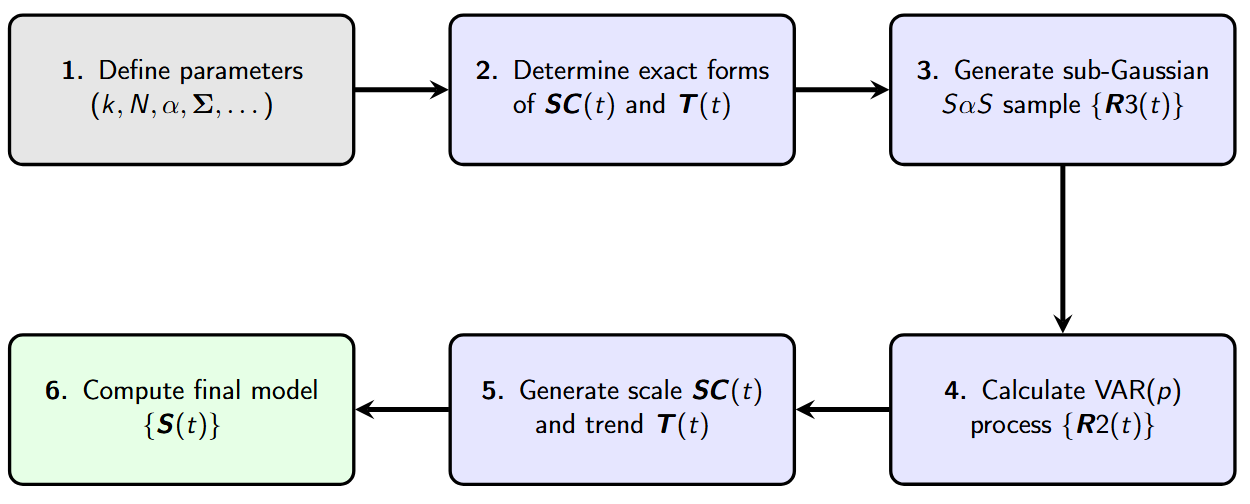

In [58]:
N = 2000
tau1 = N / 3
tau2 = 2 * N / 3

Theta_true = np.array([
    [0.5, 0.2],
    [-0.1, 0.6],
])

Sigma_true = np.array([
    [0.64, 0.32],
    [0.32, 0.64],
])

base_params_2d = dict(
    N=N,
    tau1=tau1,
    tau2=tau2,
    Theta=Theta_true,
    Sigma=Sigma_true,
    sigma_1=np.array([1.0, 0.8]),
    sigma_2=np.array([2.5, 1.5]),
    sigma_3=np.array([5.0, 2.0]),
    sigma_4=np.array([25.0, 10.0]),
    c1=np.array([10.0, -5.0]),
)

In [59]:
sim2d = simulate_2d_model(
    **base_params_2d,
    alpha=1.9,
    random_state=42,
)

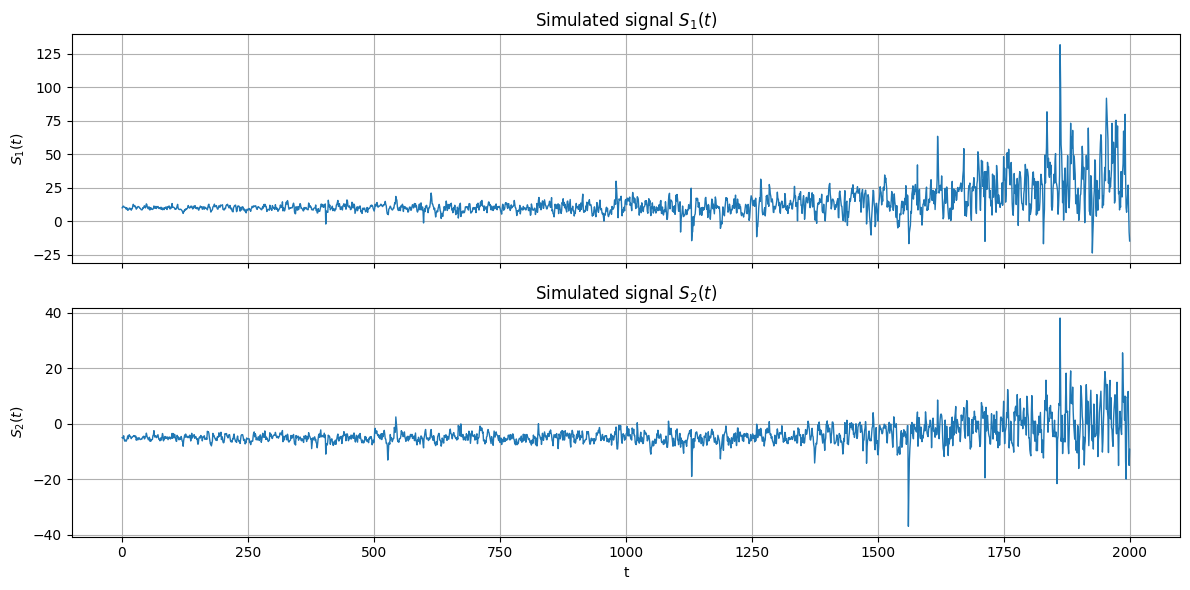

In [60]:
t = sim2d["t"]
S = sim2d["S"]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t, S[:, 0], linewidth=1)
axes[0].set_title(r"Simulated signal $S_1(t)$")
axes[0].set_ylabel(r"$S_1(t)$")
axes[0].grid(True)

axes[1].plot(t, S[:, 1], linewidth=1)
axes[1].set_title(r"Simulated signal $S_2(t)$")
axes[1].set_xlabel("t")
axes[1].set_ylabel(r"$S_2(t)$")
axes[1].grid(True)

plt.tight_layout()
plt.show()

The simulated two-dimensional trajectory shows that both health-index components exhibit the expected degradation behaviour throughout the observation period. During the initial stage, both signals remain relatively stable with low variability. As time progresses, the fluctuations become more pronounced, and in the final stage both components display substantially larger amplitudes together with several extreme observations. Although the two signals evolve on different scales and around different trend levels, they exhibit similar degradation dynamics, reflecting the common underlying degradation process.

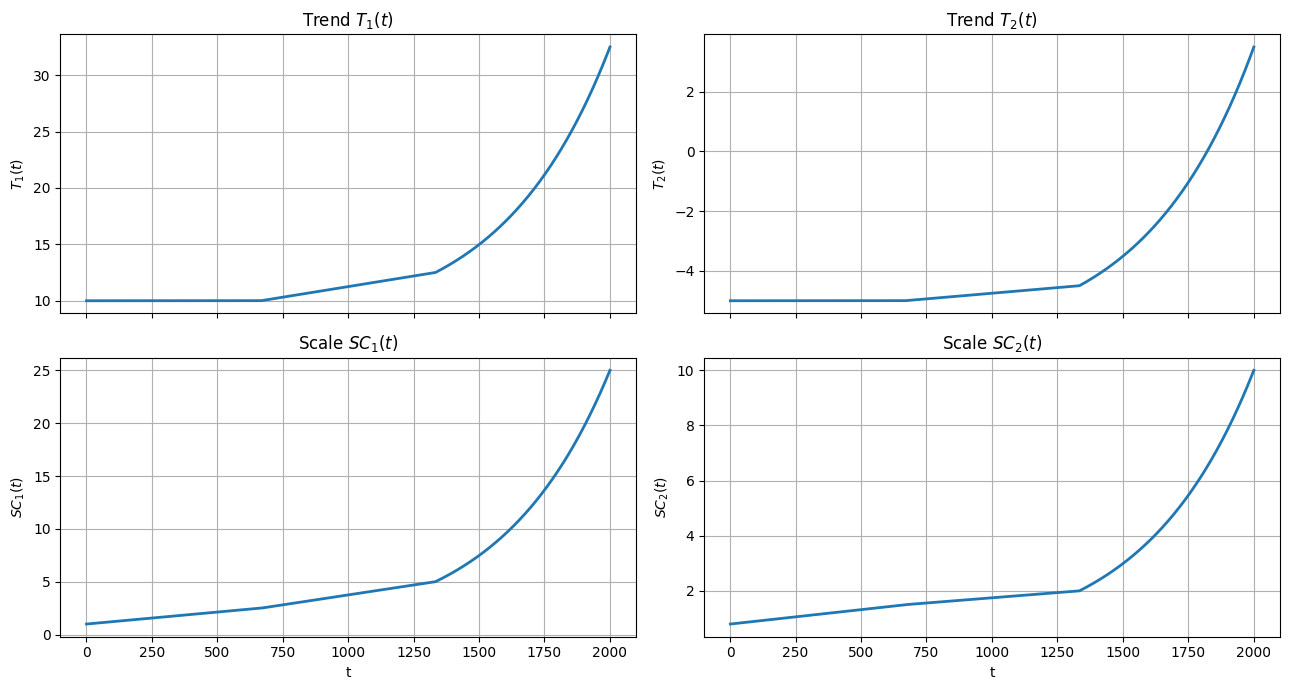

In [61]:
T = sim2d["T"]
SC = sim2d["SC"]

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)

axes[0, 0].plot(t, T[:, 0], linewidth=2)
axes[0, 0].set_title(r"Trend $T_1(t)$")
axes[0, 0].set_ylabel(r"$T_1(t)$")
axes[0, 0].grid(True)

axes[0, 1].plot(t, T[:, 1], linewidth=2)
axes[0, 1].set_title(r"Trend $T_2(t)$")
axes[0, 1].set_ylabel(r"$T_2(t)$")
axes[0, 1].grid(True)

axes[1, 0].plot(t, SC[:, 0], linewidth=2)
axes[1, 0].set_title(r"Scale $SC_1(t)$")
axes[1, 0].set_xlabel("t")
axes[1, 0].set_ylabel(r"$SC_1(t)$")
axes[1, 0].grid(True)

axes[1, 1].plot(t, SC[:, 1], linewidth=2)
axes[1, 1].set_title(r"Scale $SC_2(t)$")
axes[1, 1].set_xlabel("t")
axes[1, 1].set_ylabel(r"$SC_2(t)$")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

The trend and scale functions define the deterministic evolution of both health-index components throughout the degradation process. Although the two components operate on different levels, they follow a similar three-stage degradation pattern. During the initial stage, both trend and scale change only slightly, corresponding to stable machine operation. In the second stage, gradual increases become visible, indicating the onset of degradation. The final stage is characterized by a rapid growth of both trend and scale, reflecting accelerated deterioration together with increasing variability of the observed signals. The differences in the magnitude of the functions demonstrate that each component may respond differently to the same underlying degradation process.

-----

## Estimation procedure for the multidimensional model

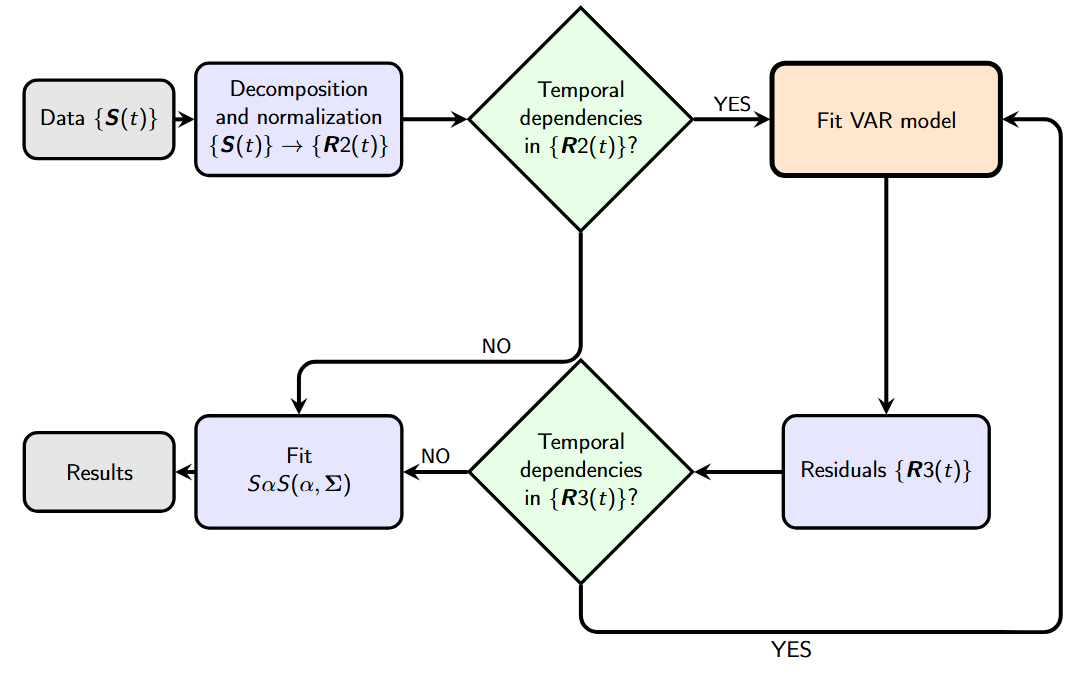

### 1. Data: $\mathbf{S}(t)$

The starting point is the observed multidimensional health index trajectory

$$
\{\mathbf{S}(t)\}_{t=1}^{N}.
$$

Each component $S_i(t)$ can represent a different sensor channel, a different bearing component or a different diagnostic feature extracted from the same machine. In contrast to the one-dimensional case, the model must describe not only the behaviour of each component separately, but also the dependence between components.

---

### 2. Decomposition and normalization: $\mathbf{S}(t)\to \mathbf{R2}(t)$

The decomposition step is performed componentwise. For each component $i=1,\dots,d$, the deterministic trend is estimated using the moving median:

$$
\widehat{T}_i(t)=MM_w(S_i(t)).
$$

Then the random component is obtained as

$$
\widehat{R}_i(t)=S_i(t)-\widehat{T}_i(t).
$$

In vector notation,

$$
\widehat{\mathbf{R}}(t)
=
\mathbf{S}(t)-\widehat{\mathbf{T}}(t).
$$

Next, the scale function is estimated separately for each component. For a local window $x={x_1,\dots,x_n}$, the robust Rousseeuw-Croux scale estimator is

$$
SC_x^Q
=
d\{|x_i-x_j|;\ i<j\}_{(k)}.
$$

Here $d$ is a normalizing constant, ${.}_{(k)}$ denotes the $k$-th order statistic, and the estimator is based on pairwise absolute differences. Applied in a moving window to the residual component $\widehat{R}_i(t)$, it gives

$$
\widehat{SC}_i(t).
$$

The normalized process is therefore

$$
\widehat{R2}_i(t)
=
\frac{\widehat{R}_i(t)}{\widehat{SC}_i(t)},
\qquad i=1,\dots,d.
$$

Equivalently,

$$
\widehat{\mathbf{R2}}(t)
=
\widehat{\mathbf{R}}(t)\oslash \widehat{\mathbf{SC}}(t),
$$

where $\oslash$ denotes componentwise division. After this step, the process $\{\widehat{\mathbf{R2}}(t)\}$ should be closer to stationarity and can be analysed using vector autoregressive methods.

---

### 3. Checking temporal dependencies in $\mathbf{R2}(t)$

After normalization, we check whether the process $\{\widehat{\mathbf{R2}}(t)\}$ contains temporal dependencies. In the multidimensional case, two types of dependencies are important:

1. dependence inside each component,
2. dependence between different components.

The first type is analysed using robust ACF, and the second type using robust CCF.

For two one-dimensional stationary signals

$$
\mathbf{x}={x_1,\dots,x_n},
\qquad
\mathbf{y}={y_1,\dots,y_n},
$$

and lag $h$, define

$$
\mathbf{u}=(x_1,\dots,x_{n-h}),
\qquad
\mathbf{v}=(y_{h+1},\dots,y_n).
$$

The robust CCF estimator is

$$
\widehat{\rho}_{\mathbf{x},\mathbf{y}}^Q(h)
=
\frac{
(SC_{\mathbf{u}+\mathbf{v}}^Q)^2
-
(SC_{\mathbf{u}-\mathbf{v}}^Q)^2
}{
(SC_{\mathbf{u}+\mathbf{v}}^Q)^2
+
(SC_{\mathbf{u}-\mathbf{v}}^Q)^2
}.
$$

For ACF, both vectors are taken from the same component, so $\mathbf{x}=\mathbf{y}$. For CCF, $\mathbf{x}$ and $\mathbf{y}$ are taken from two different components.

If the robust ACF/CCF values are close to zero for positive lags, the normalized process may be treated as approximately temporally independent. If significant dependence is present, a VAR model is fitted.

---

### 4. Fitting the VAR model

If temporal dependence is detected in $\{\widehat{\mathbf{R2}}(t)\}$, we model it using a vector autoregressive process of order $p$:

$$
\mathbf{R2}(t)
=
\mathbf{\Theta}_1\mathbf{R2}(t-1)
+
\dots
+
\mathbf{\Theta}_p\mathbf{R2}(t-p)
+
\mathbf{R3}(t),
$$

where $\mathbf{\Theta}_1,\dots,\mathbf{\Theta}_p$ are autoregression matrices and $\mathbf{R3}(t)$ is the residual noise vector.

In the multidimensional case, the parameters of the VAR model are estimated using a robust version of the Yule-Walker approach based on normalized covariation. For stationary time series $\{x_i(t)\}$ and $\{x_j(t)\}$, the robust normalized covariation is

$$
\widehat{NCV}_{i,j}(h)
=
\frac{
\sum_{t=r}^{l} x_i(t)\operatorname{sgn}(x_j(t-h))
}{
\sum_{t=r}^{L}|x_j(t)|
},
$$

where

$$
r=\max(1,1+h),
\qquad
l=\min(L,L+h),
$$

and $L$ is the length of the analysed trajectories.

This measure replaces classical covariance-type quantities in the multidimensional Yule-Walker system. As a result, the fitted model is less sensitive to extreme observations generated by heavy-tailed noise.

---

### 5. Residuals: $\mathbf{R3}(t)$

After fitting the VAR model, residuals are computed as

$$
\widehat{\mathbf{R3}}(t)
=
\widehat{\mathbf{R2}}(t)
-
\sum_{j=1}^{p}
\widehat{\mathbf{\Theta}}_j
\widehat{\mathbf{R2}}(t-j).
$$

The residual vector $\widehat{\mathbf{R3}}(t)$ represents the part of the normalized signal that is not explained by temporal dependence. Ideally, this sequence should no longer contain lagged dependence either within components or between components.

---

### 6. Checking temporal dependencies in $\mathbf{R3}(t)$

The robust ACF and CCF diagnostics are then repeated for the residual sequence $\{\widehat{\mathbf{R3}}(t)\}$.

The goal is to verify whether the VAR model has removed temporal dependence. We analyse:

$$
\widehat{\rho}_{R3_i,R3_i}^Q(h)
$$

for dependence inside each residual component, and

$$
\widehat{\rho}_{R3_i,R3_j}^Q(h),
\qquad i\neq j,
$$

for cross-dependence between residual components.

If the ACF/CCF values of residuals are still significant, then the fitted VAR model is not sufficient and the fitting step should be repeated, for example with a different order $p$. If the residual dependence is close to zero, the residuals can be treated as approximately independent realizations from a multivariate noise distribution.

---

### 7. Fitting the $S\alpha S(\alpha,\mathbf{\Sigma})$ distribution

After removing temporal dependence, the residual sequence $\{\widehat{\mathbf{R3}}(t)\}$ is modelled using a multivariate sub-Gaussian $S\alpha S$ distribution.

A sub-Gaussian random vector can be represented as

$$
\mathbf{X}=A^{1/2}\mathbf{G},
$$

where

$$
\mathbf{G}\sim N(\mathbf{0},\mathbf{\Sigma})
$$

and $A$ is a positive stable random variable independent of $\mathbf{G}$. The parameter $\alpha$ controls tail heaviness, while the matrix $\mathbf{\Sigma}$ describes the dependence structure of the Gaussian vector used in the construction.

---

#### 7.1. Estimation of $\alpha$

The stability index $\alpha$ is estimated componentwise using McCulloch's quantile method.

For each residual component $\widehat{R3}_i(t)$, empirical quantiles are used to compute

$$
v_{\alpha}
=
\frac{x_{0.95}-x_{0.05}}
{x_{0.75}-x_{0.25}},
$$

and

$$
v_{\beta}
=
\frac{x_{0.95}+x_{0.05}-2x_{0.5}}
{x_{0.95}-x_{0.05}}.
$$

Then

$$
\widehat{\alpha}_i
=
\psi_1(v_{\alpha},v_{\beta}).
$$

The final multidimensional estimate is obtained by averaging the componentwise estimates:

$$
\widehat{\alpha}
=
\frac{1}{d}
\sum_{i=1}^{d}
\widehat{\alpha}_i.
$$

---

#### 7.2. Estimation of $\mathbf{\Sigma}$

After estimating $\alpha$, the covariance matrix $\mathbf{\Sigma}$ is estimated using the empirical characteristic function.

For observations $\mathbf{X}_1,\dots,\mathbf{X}_n$, the empirical characteristic function is

$$
\widehat{\phi}_{\mathbf{X}}(\mathbf{k})
=
\frac{1}{n}
\sum_{j=1}^{n}
\exp\left(i\mathbf{k}^{\top}\mathbf{X}_j\right).
$$

For the sub-Gaussian model, the theoretical characteristic function has the form

$$
\phi_{\mathbf{X}}(\mathbf{k})
=
\exp\left\{
-\frac{1}{2}
\left|
\mathbf{k}^{\top}\mathbf{\Sigma}\mathbf{k}
\right|^{\alpha/2}
\right\}.
$$

The matrix $\mathbf{\Sigma}$ is estimated by minimizing the squared difference between the empirical and theoretical characteristic functions over a grid $\mathbf{D}$:

$$
\widehat{\mathbf{\Sigma}}
=
\arg\min_{\mathbf{\Sigma}}
\sum_{\mathbf{k}\in\mathbf{D}}
\left|
\widehat{\phi}_{\mathbf{X}}(\mathbf{k})
-
\exp\left\{
-\frac{1}{2}
\left|
\mathbf{k}^{\top}\mathbf{\Sigma}\mathbf{k}
\right|^{\widehat{\alpha}/2}
\right\}
\right|^2.
$$

This step is specific to the multidimensional model, because in the one-dimensional case only the stability index $\alpha$ was estimated.

---

### 8. Results

The final output of the multidimensional estimation procedure consists of:

$$
\widehat{\mathbf{T}}(t),
\qquad
\widehat{\mathbf{SC}}(t),
\qquad
\widehat{\mathbf{R2}}(t),
$$

the fitted VAR parameters

$$
\widehat{p},
\qquad
\widehat{\mathbf{\Theta}}_1,\dots,\widehat{\mathbf{\Theta}}_{\widehat{p}},
$$

the residual sequence

$$
\widehat{\mathbf{R3}}(t),
$$

and the fitted sub-Gaussian distribution parameters

$$
\widehat{\alpha},
\qquad
\widehat{\mathbf{\Sigma}}.
$$


-----

## Monte Carlo Study for the 2D Model

The two-dimensional Monte Carlo study validates the full multidimensional estimation pipeline in the same order as the block diagram.

Because the data are simulated, the true trend vectors, scale vectors, VAR matrix, stability index and dependence matrix are known. The purpose of the Monte Carlo experiment is to verify that the estimation procedure recovers these known quantities with acceptable bias and variability.

### 1. Monte Carlo setup

For each $\alpha\in\{1.85,1.90,1.95,2.00\}$ we simulate $M=100$ trajectories of length $N=2000$. The true VAR(1) matrix and dependence matrix are

$$
\Theta_{true}=\begin{bmatrix}0.5&0.2\\-0.1&0.6\end{bmatrix},\qquad
\Sigma_{true}=\begin{bmatrix}0.64&0.32\\0.32&0.64\end{bmatrix}.
$$

The trend window is 501 and the scale window is 151. A fixed scale multiplier is used in the 2D simulation pipeline, consistently with the report configuration. The cells below load cached Monte Carlo results when available; otherwise they recompute the study and save the cache.

In [62]:
MC_2D_ALPHA_VALUES = [1.85, 1.90, 1.95, 2.00]
MC_2D_REPLICATIONS = 100
MC_2D_TREND_WINDOW = 501
MC_2D_SCALE_WINDOW = 151
MC_2D_VAR_ORDER = 1
MC_2D_H_MAX = 30
scale_multiplier_2d = 1.6629888237094692

alphas_order_2d = MC_2D_ALPHA_VALUES
n_replications_2d = MC_2D_REPLICATIONS
n_replications_2d_sigma = MC_2D_REPLICATIONS

MC_2D_CACHE = Path("mc_2d_results_VAR1_M100_alpha_185_190_195_200.pkl")
MC_2D_SIGMA_CACHE = Path("mc_2d_sigma_results_VAR1_M100_alpha_185_190_195_200.pkl")
USE_CACHED_2D_MC = True
RECOMPUTE_2D_MC = False

mc_2d_setup = pd.DataFrame([{
    "N": base_params_2d["N"],
    "alpha_values": MC_2D_ALPHA_VALUES,
    "replications": MC_2D_REPLICATIONS,
    "Theta_true": Theta_true.tolist(),
    "Sigma_true": Sigma_true.tolist(),
    "trend_window": MC_2D_TREND_WINDOW,
    "scale_window": MC_2D_SCALE_WINDOW,
    "var_order": MC_2D_VAR_ORDER,
    "acf_ccf_max_lag": MC_2D_H_MAX,
    "scale_multiplier": scale_multiplier_2d,
}])

mc_2d_setup

,N,alpha_values,replications,Theta_true,Sigma_true,trend_window,scale_window,var_order,acf_ccf_max_lag,scale_multiplier
0,2000,"[1.85, 1.9, 1.95, 2.0]",100,"[[0.5, 0.2], [-0.1, 0.6]]","[[0.64, 0.32], [0.32, 0.64]]",501,151,1,30,1.662989


In [63]:
if USE_CACHED_2D_MC and MC_2D_CACHE.exists() and not RECOMPUTE_2D_MC:
    with open(MC_2D_CACHE, "rb") as f:
        mc_2d_final_scaled = pickle.load(f)
    print(f"Loaded 2D Monte Carlo results from {MC_2D_CACHE}")
else:
    mc_2d_final_scaled = {}

    for idx, alpha in enumerate(MC_2D_ALPHA_VALUES):
        print(f"Running 2D Monte Carlo for alpha={alpha}...")
        mc_2d_final_scaled[alpha] = run_mc_2d_for_alpha(
            alpha=alpha,
            base_params_2d=base_params_2d,
            n_replications=MC_2D_REPLICATIONS,
            base_seed=20_000 + idx * 10_000,
            trend_window=MC_2D_TREND_WINDOW,
            scale_window=MC_2D_SCALE_WINDOW,
            h_max=MC_2D_H_MAX,
            scale_multiplier=scale_multiplier_2d,
            estimate_sigma=False,
        )

    with open(MC_2D_CACHE, "wb") as f:
        pickle.dump(mc_2d_final_scaled, f)

    print(f"Computed and saved 2D Monte Carlo results to {MC_2D_CACHE}")

Running 2D Monte Carlo for alpha=1.85...
Running 2D Monte Carlo for alpha=1.9...
Running 2D Monte Carlo for alpha=1.95...
Running 2D Monte Carlo for alpha=2.0...
Computed and saved 2D Monte Carlo results to mc_2d_results_VAR1_M100_alpha_185_190_195_200.pkl


### 2. Trend estimation

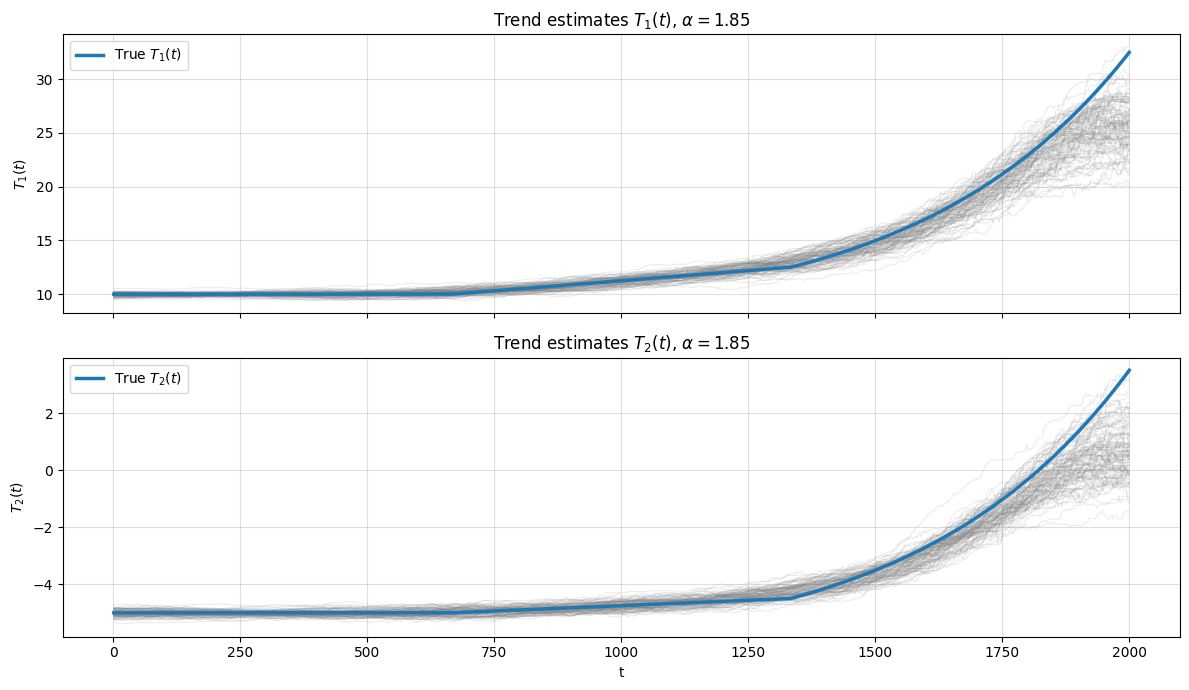

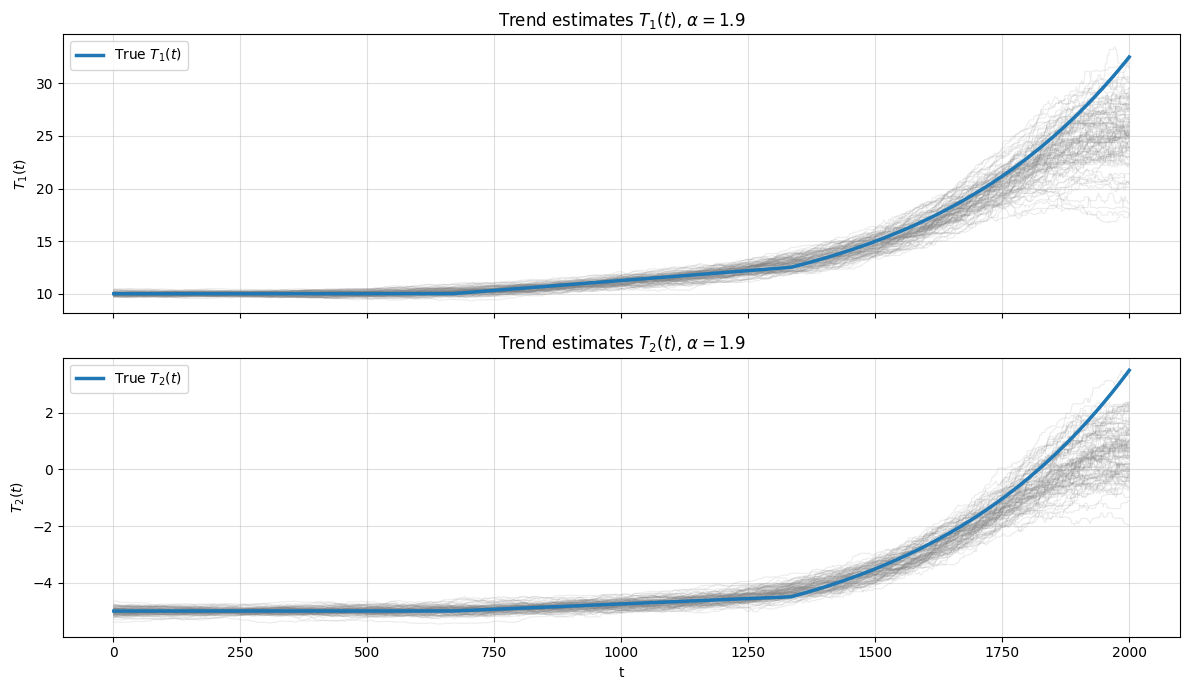

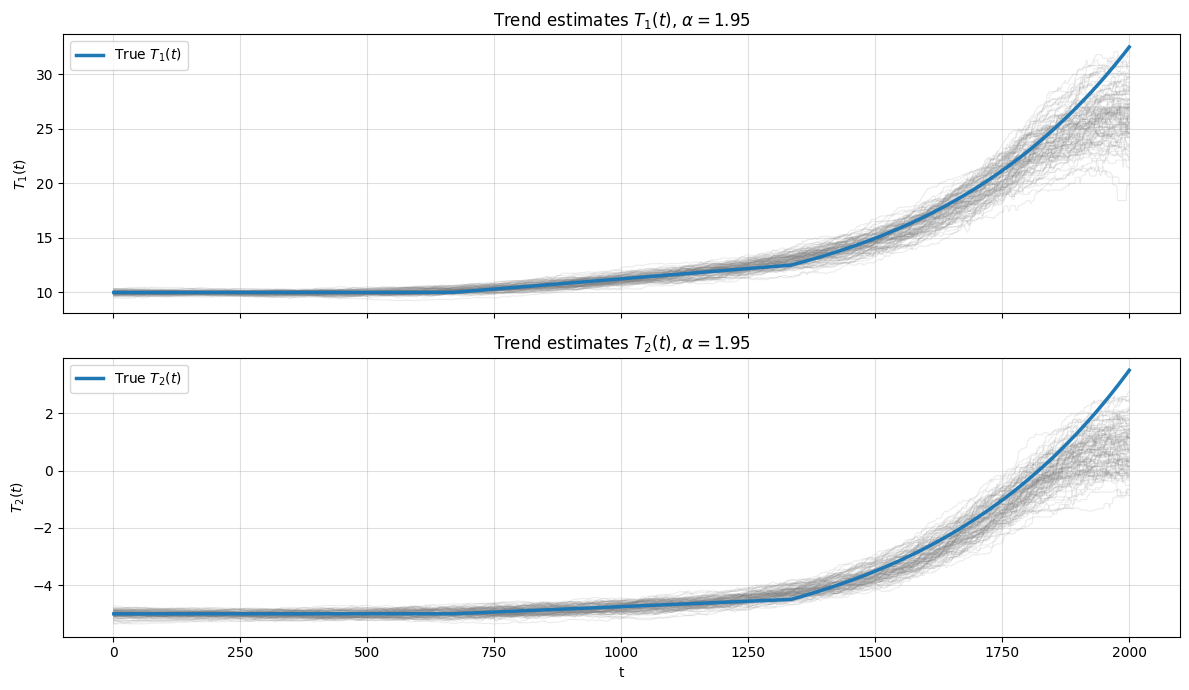

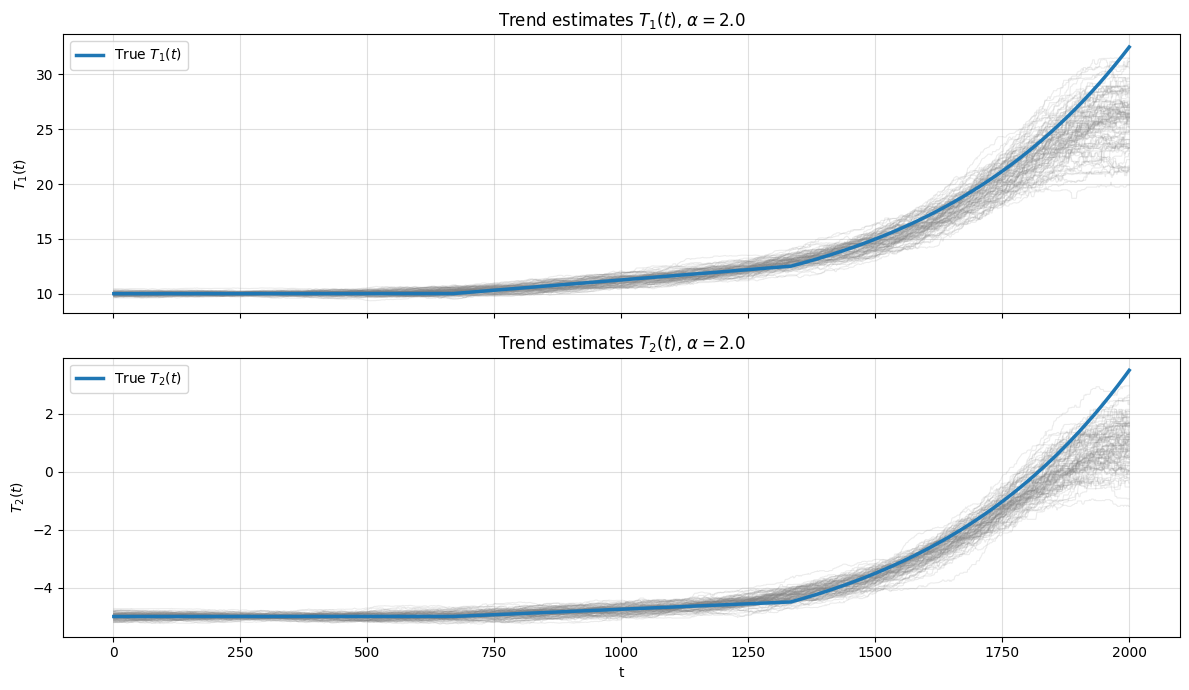

In [64]:
for alpha in MC_2D_ALPHA_VALUES:
    plotting_utils.plot_mc_2d_trend_trajectories(mc_2d_final_scaled[alpha])

The estimated trend trajectories closely follow the true trends for both signal components across all considered values of $\alpha$. Most estimates remain concentrated around the reference curves throughout the observation period, indicating good reconstruction accuracy. A larger spread is visible in the final stage of degradation, where the trend changes most rapidly and the estimation becomes more sensitive to random fluctuations. Despite this increased variability, the overall shape of both trends is consistently recovered in all Monte Carlo realizations.

### 3. Scale estimation

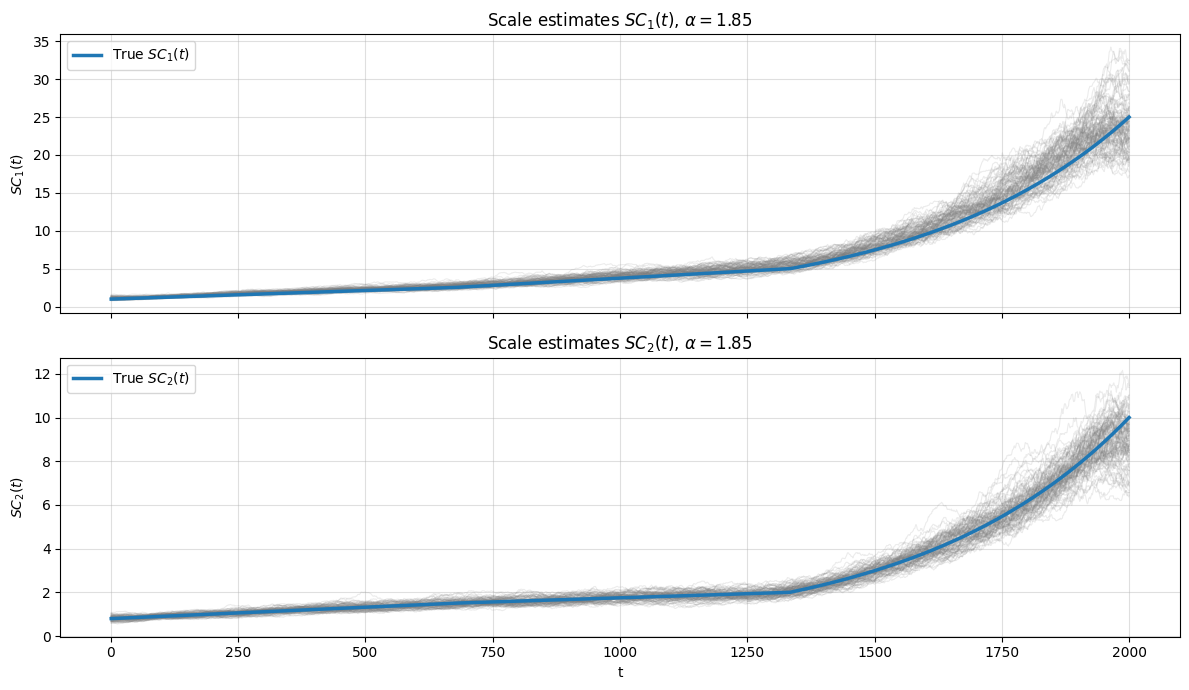

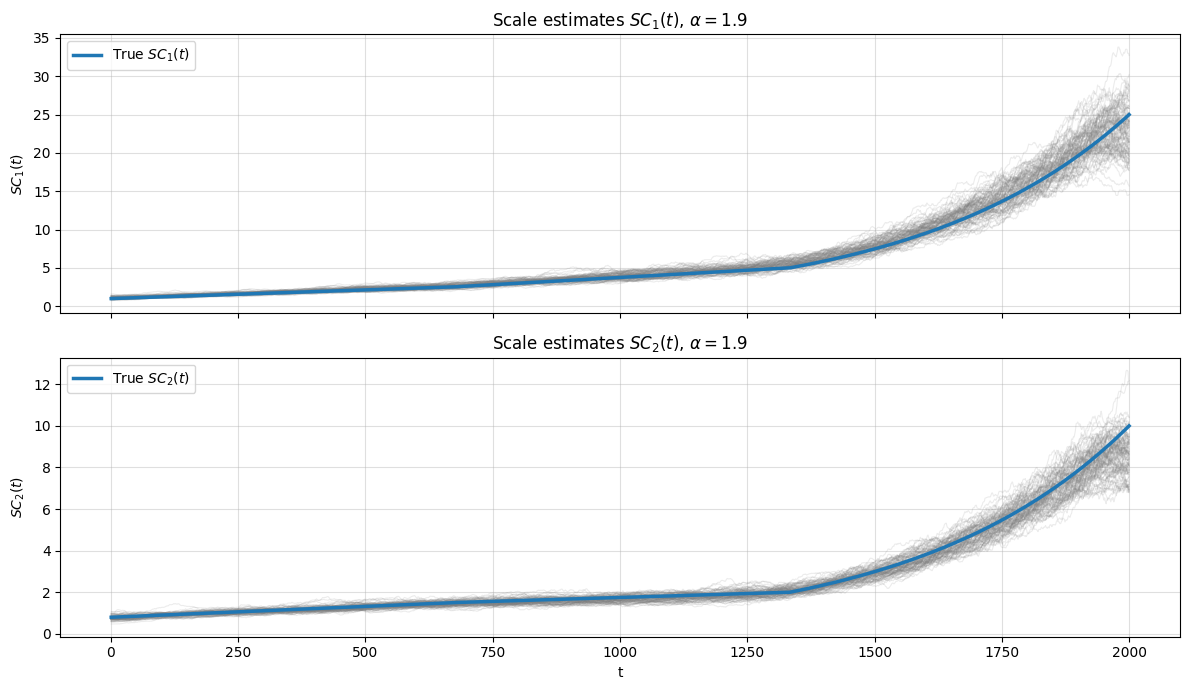

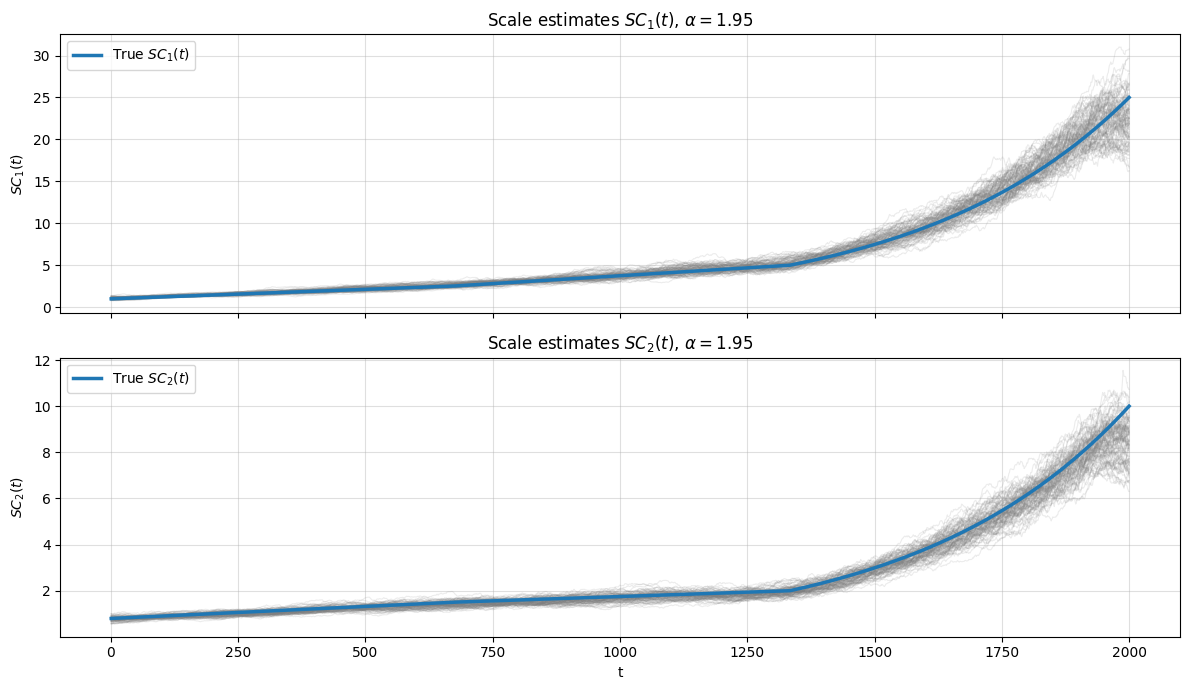

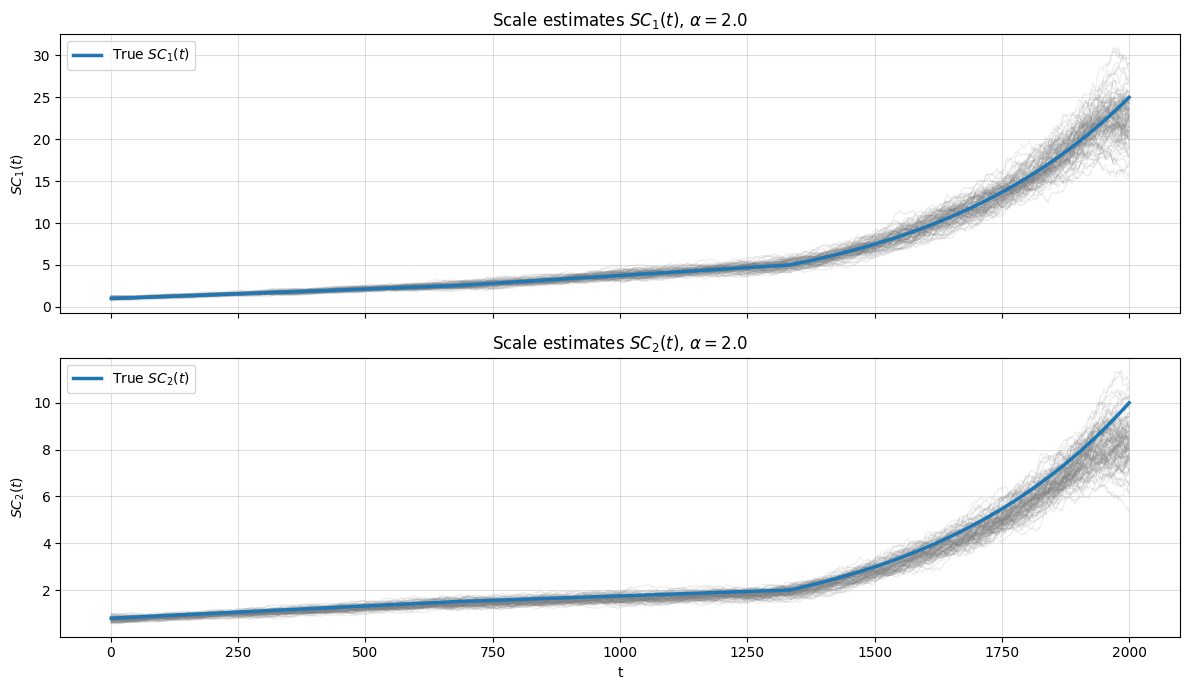

In [65]:
for alpha in MC_2D_ALPHA_VALUES:
    plotting_utils.plot_mc_2d_scale_trajectories(mc_2d_final_scaled[alpha])

The estimated scale trajectories remain closely aligned with the true scale functions throughout most of the observation period for both signal components. The variability between Monte Carlo realizations becomes more pronounced only in the final stage, where the rapid increase of the scale naturally amplifies the influence of random fluctuations. This effect is consistently observed for all considered values of the stability parameter $\alpha$. Although the spread of the estimates increases near the end of the trajectories, no systematic overestimation or underestimation is visible, and the estimates accurately reproduce the nonlinear growth of both scale functions. These results indicate that the estimation procedure remains stable even under increasingly variable degradation dynamics.

### 4. ACF/CCF before VAR fitting

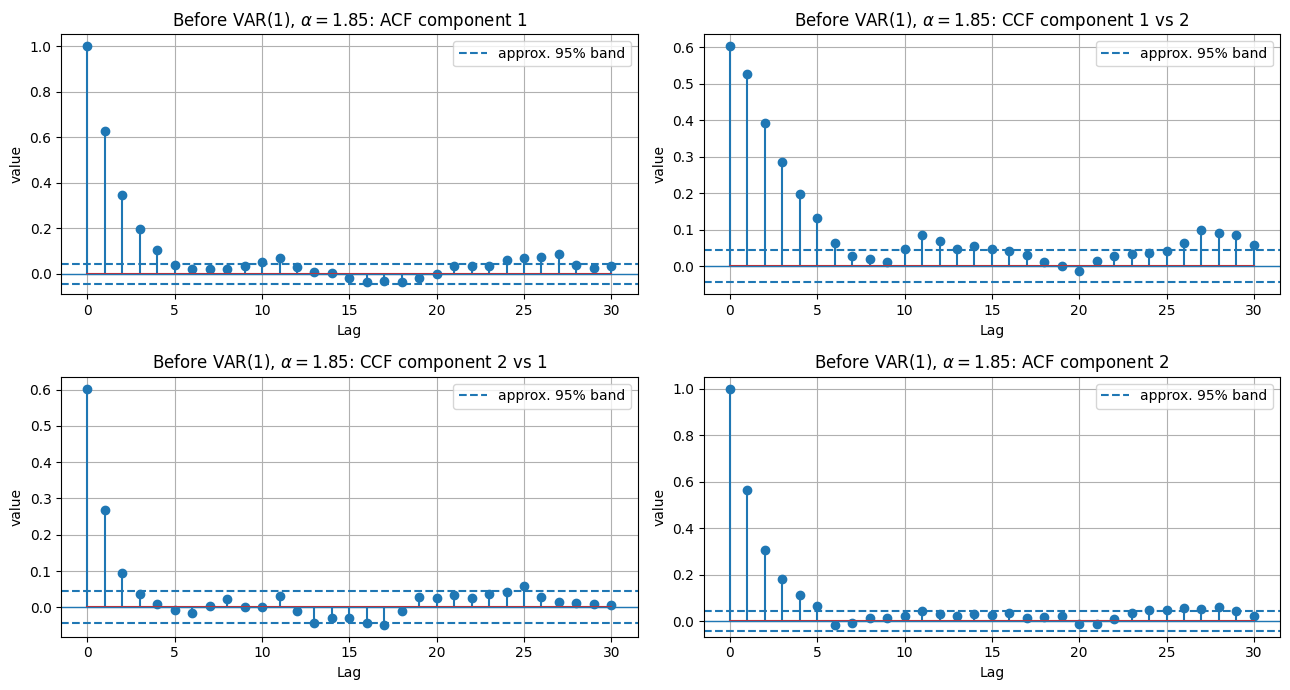

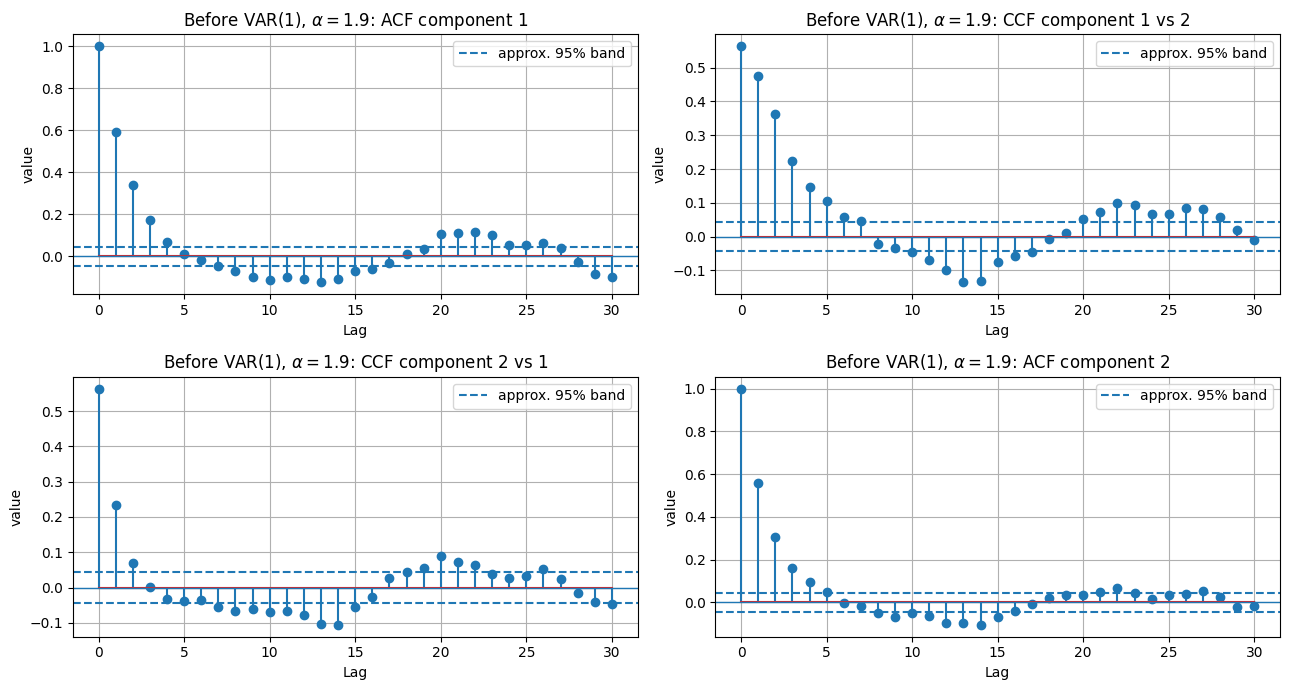

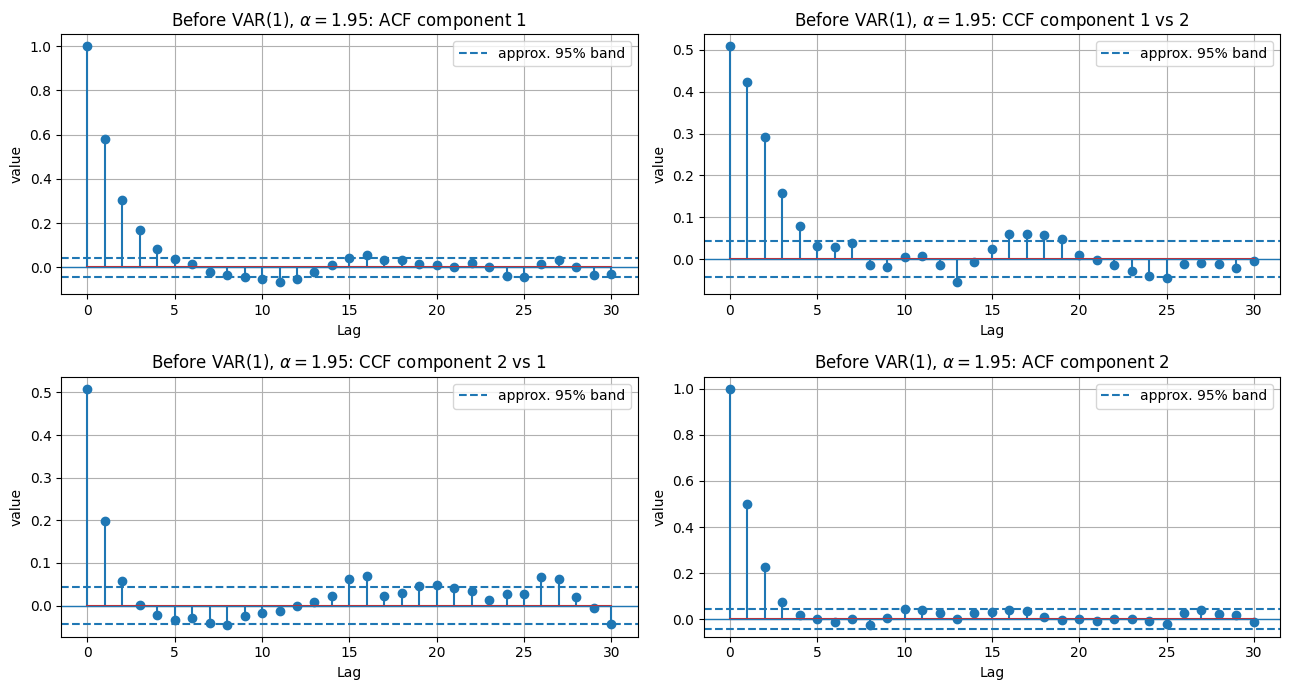

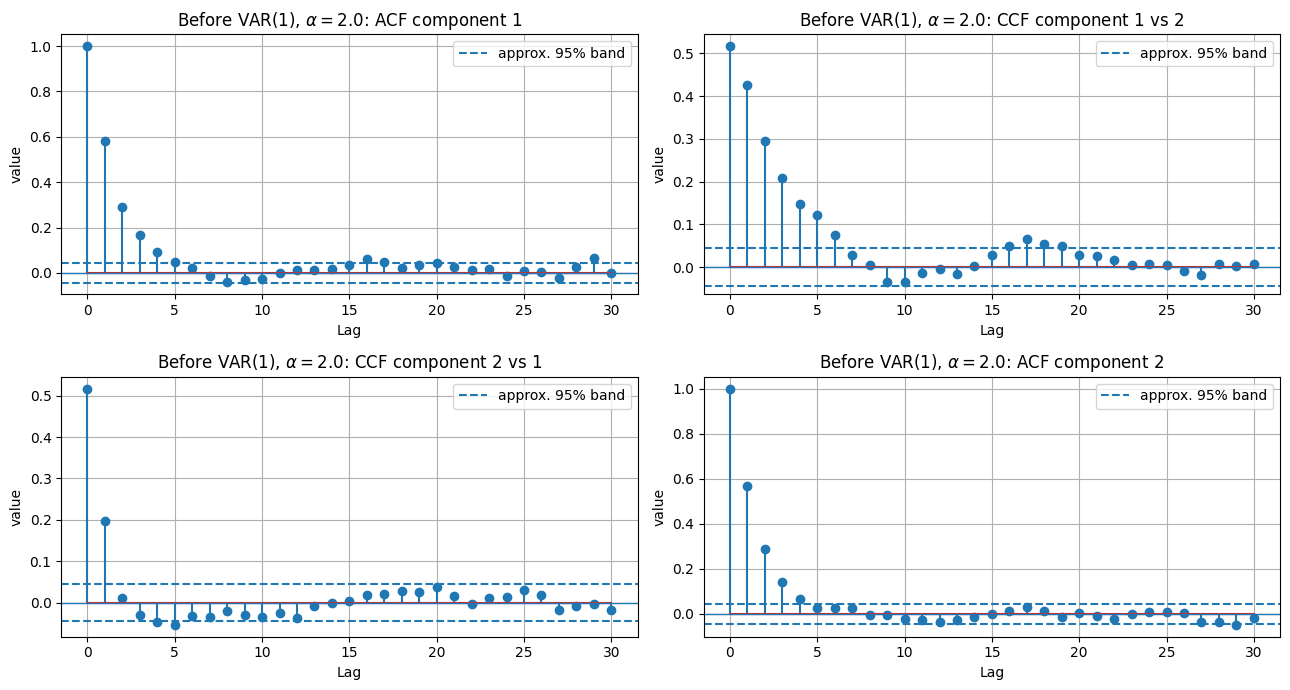

In [66]:
for alpha in MC_2D_ALPHA_VALUES:
    plotting_utils.plot_mc_2d_acf_ccf_before_var(mc_2d_final_scaled[alpha])

The autocorrelation and cross-correlation functions computed before fitting the VAR(1) model reveal a pronounced temporal dependence in both signal components for all considered values of $\alpha$. The autocorrelation functions exhibit a gradual decay, indicating that consecutive observations remain strongly correlated over several lags. At the same time, the cross-correlation functions show substantial dependence between the two components, particularly for small lags, confirming that the degradation processes evolve jointly rather than independently. The overall correlation structure remains qualitatively similar across all values of $\alpha$, suggesting that the deterministic and autoregressive components dominate the dependence pattern prior to model fitting.

### 5. VAR parameter estimation

In [67]:
theta_summary_2d = pd.DataFrame([
    {
        "true_alpha": alpha,
        "mean_theta_11": np.mean(mc_2d_final_scaled[alpha]["Theta_hats"][:, 0, 0]),
        "median_theta_11": np.median(mc_2d_final_scaled[alpha]["Theta_hats"][:, 0, 0]),
        "true_theta_11": Theta_true[0, 0],
        "mean_theta_12": np.mean(mc_2d_final_scaled[alpha]["Theta_hats"][:, 0, 1]),
        "median_theta_12": np.median(mc_2d_final_scaled[alpha]["Theta_hats"][:, 0, 1]),
        "true_theta_12": Theta_true[0, 1],
        "mean_theta_21": np.mean(mc_2d_final_scaled[alpha]["Theta_hats"][:, 1, 0]),
        "median_theta_21": np.median(mc_2d_final_scaled[alpha]["Theta_hats"][:, 1, 0]),
        "true_theta_21": Theta_true[1, 0],
        "mean_theta_22": np.mean(mc_2d_final_scaled[alpha]["Theta_hats"][:, 1, 1]),
        "median_theta_22": np.median(mc_2d_final_scaled[alpha]["Theta_hats"][:, 1, 1]),
        "true_theta_22": Theta_true[1, 1],
        "n_replications": MC_2D_REPLICATIONS,
    }
    for alpha in MC_2D_ALPHA_VALUES
])

theta_summary_2d

,true_alpha,mean_theta_11,median_theta_11,true_theta_11,mean_theta_12,median_theta_12,true_theta_12,mean_theta_21,median_theta_21,true_theta_21,mean_theta_22,median_theta_22,true_theta_22,n_replications
0,1.85,0.488665,0.486248,0.5,0.188118,0.189874,0.2,-0.108152,-0.108307,-0.1,0.596985,0.597428,0.6,100
1,1.90,0.497038,0.495775,0.5,0.188254,0.189149,0.2,-0.106244,-0.111650,-0.1,0.594643,0.594761,0.6,100
2,1.95,0.490795,0.492372,0.5,0.195107,0.195034,0.2,-0.116733,-0.116132,-0.1,0.603795,0.608446,0.6,100
3,2.00,0.490862,0.492024,0.5,0.192216,0.192791,0.2,-0.109185,-0.110934,-0.1,0.596896,0.596507,0.6,100


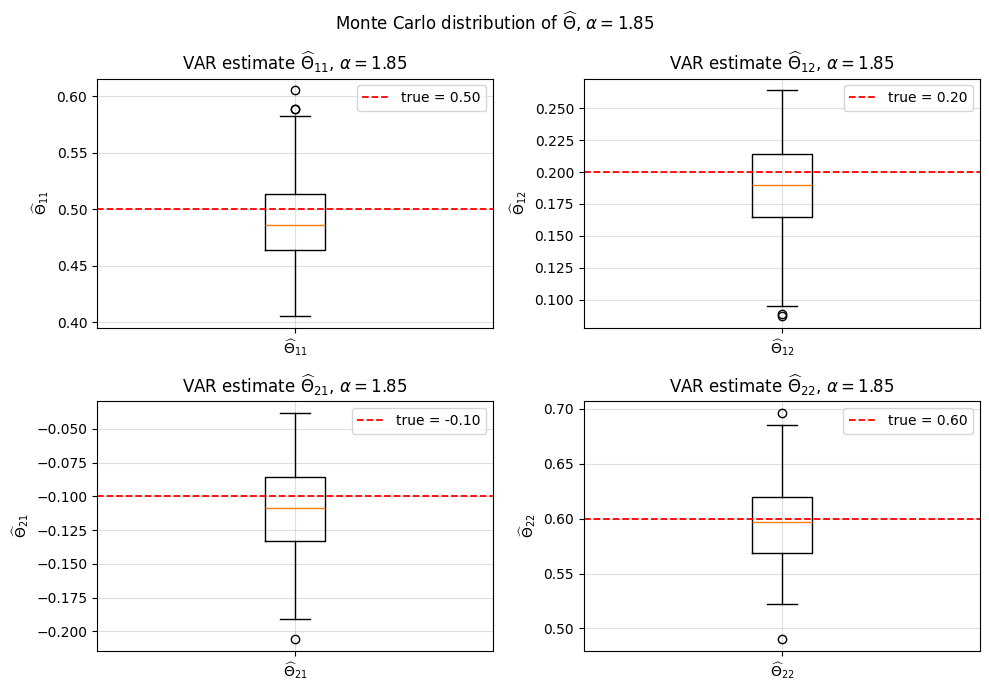

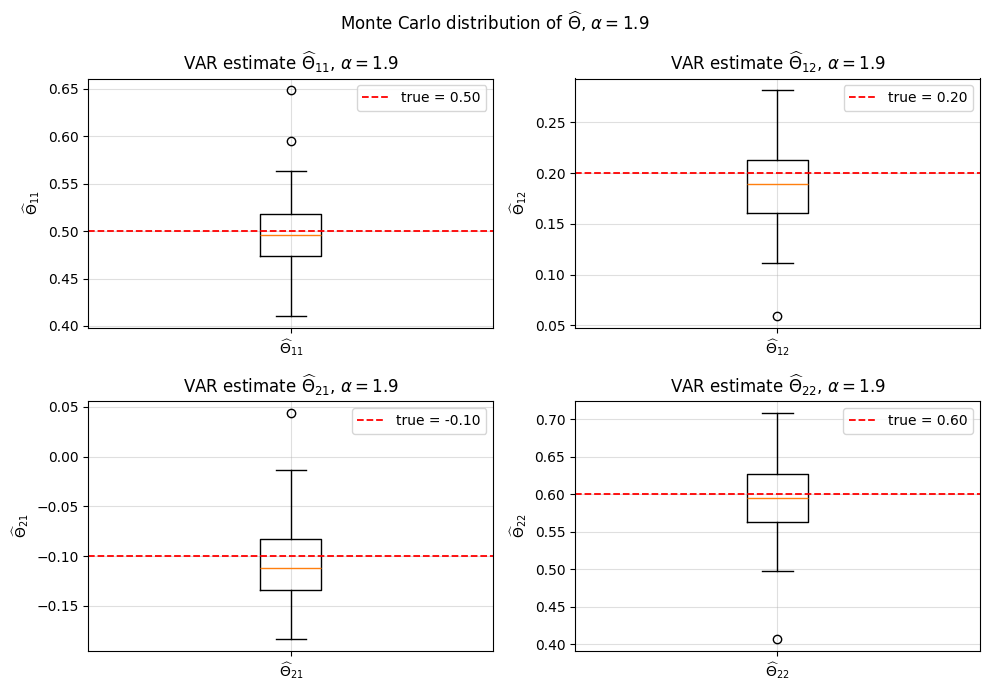

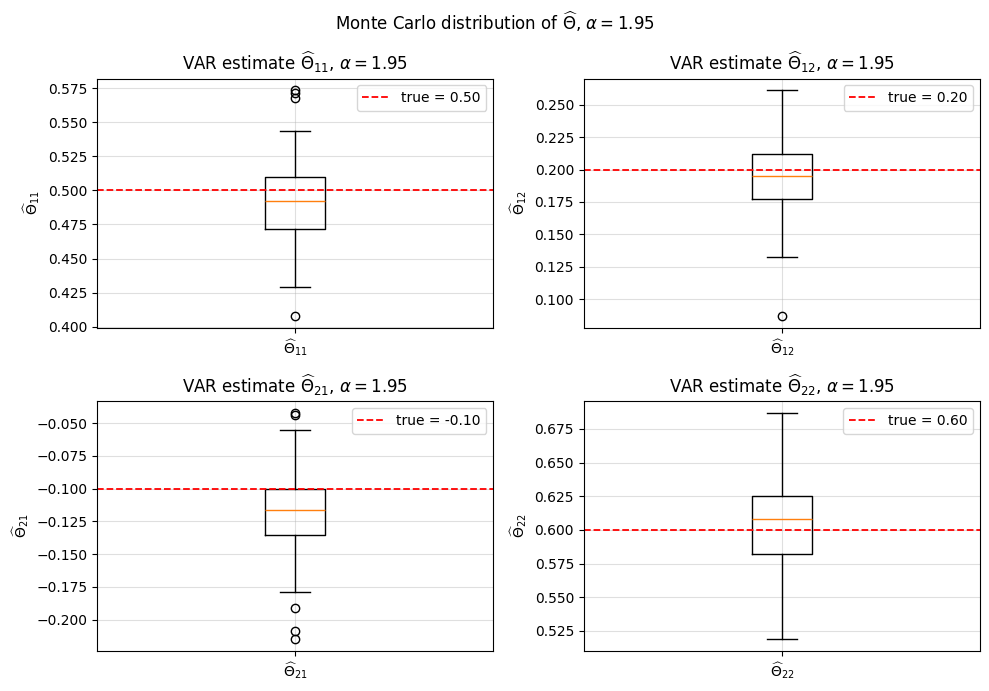

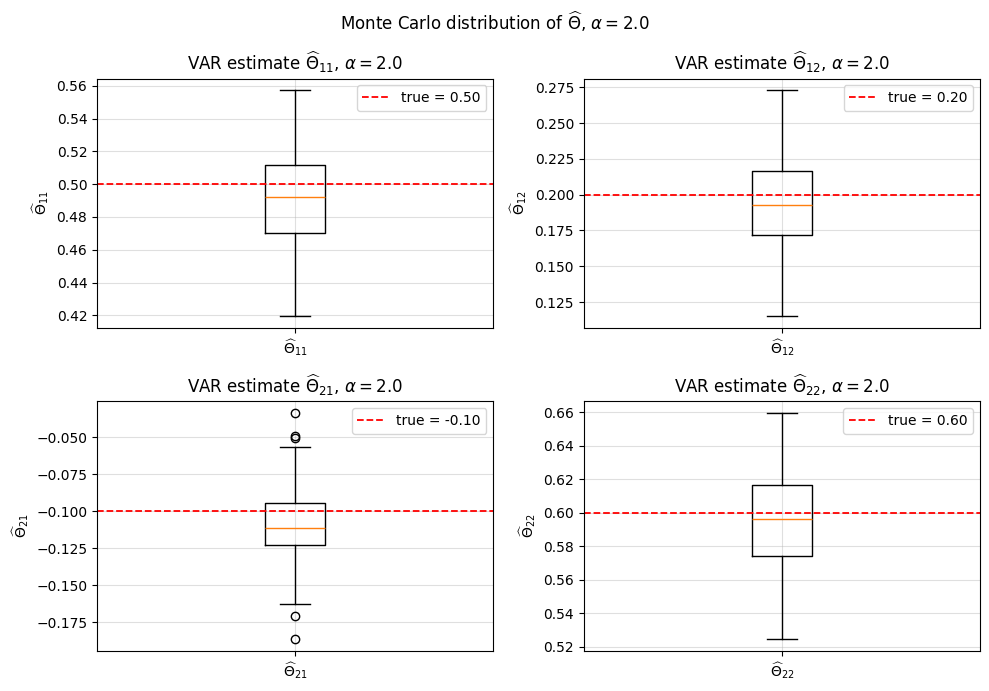

In [68]:
for alpha in MC_2D_ALPHA_VALUES:
    plotting_utils.plot_mc_2d_theta_boxplots(mc_2d_final_scaled[alpha])

The Monte Carlo distributions of the estimated VAR(1) coefficients remain centered around their corresponding true values for all considered values of $\alpha$. The medians closely match the reference parameters, while the relatively narrow interquartile ranges indicate good estimation precision. Although individual outliers are present, particularly for smaller values of $\alpha$, they occur only sporadically and do not introduce any systematic bias. The consistency of the results across all four matrix coefficients demonstrates that the proposed estimation procedure reliably recovers both the autoregressive effects within each component and the cross-dependencies between them under different noise distributions.

### 6. Residuals

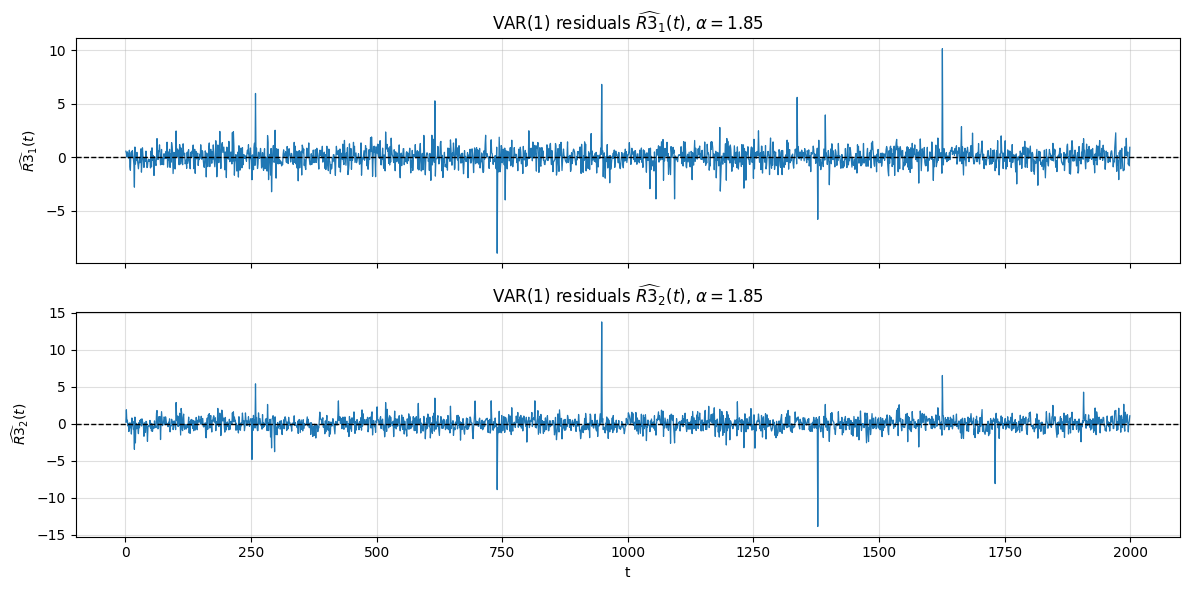

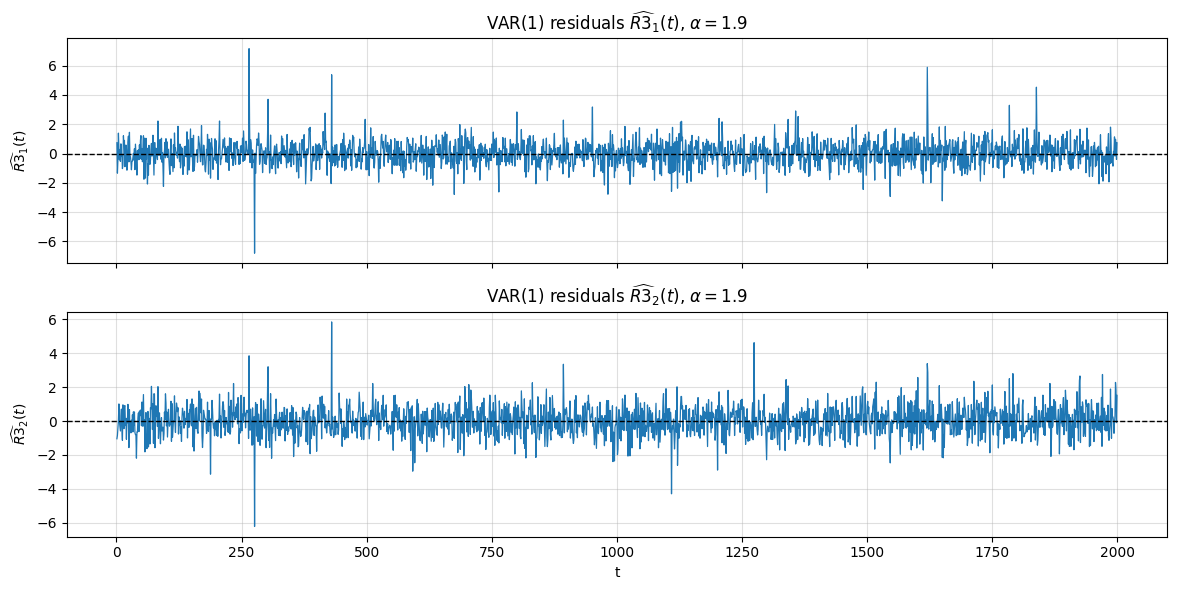

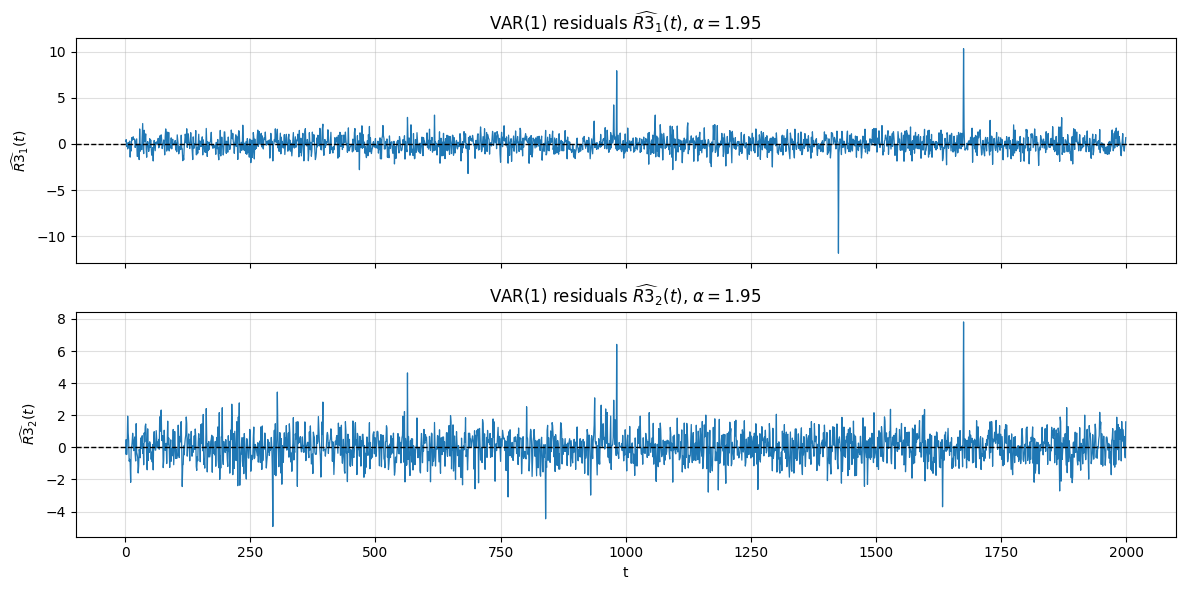

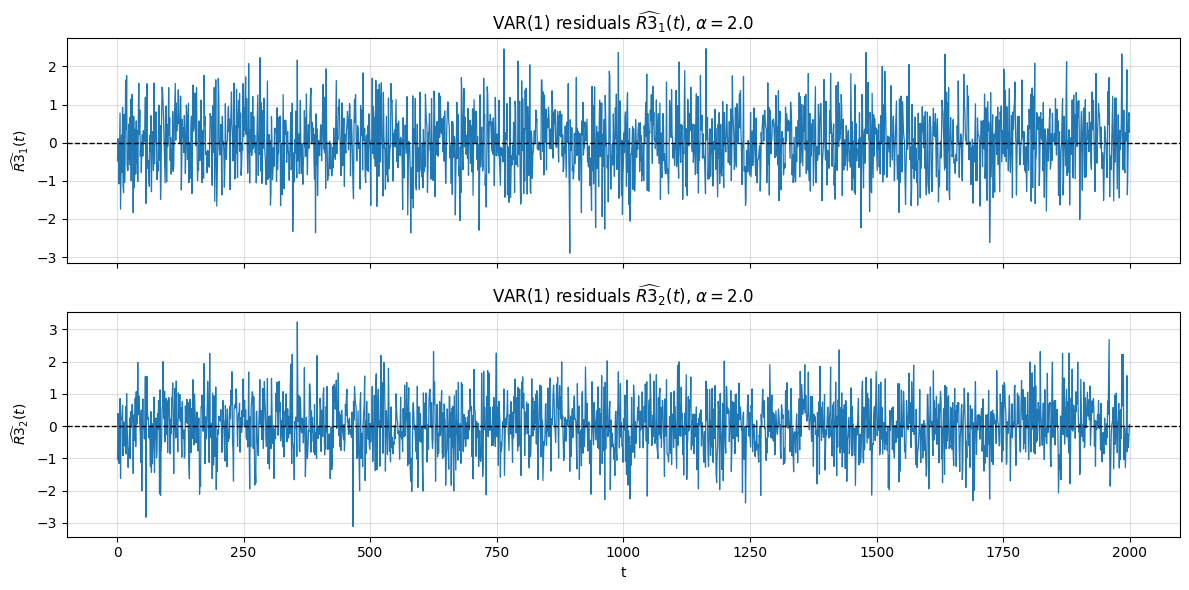

In [69]:
for alpha in MC_2D_ALPHA_VALUES:
    plotting_utils.plot_mc_2d_residual_trajectories(mc_2d_final_scaled[alpha])

The residual trajectories of both signal components fluctuate around zero throughout the entire observation period, without exhibiting any visible deterministic trend or persistent shifts in the mean. For all considered values of $\alpha$, the residual series remain largely stationary, with only occasional large positive or negative impulses corresponding to extreme realizations of the underlying noise. These impulsive observations become less pronounced as $\alpha$ approaches 2, leading to a more homogeneous residual process. The residual plots indicate that, after fitting the VAR(1) model, the remaining variability is primarily associated with random fluctuations rather than systematic features of the degradation process.The residual trajectories may still contain large impulses caused by heavy-tailed innovations, but they should no longer display systematic VAR-type temporal dependence.

### 7. ACF/CCF after VAR fitting

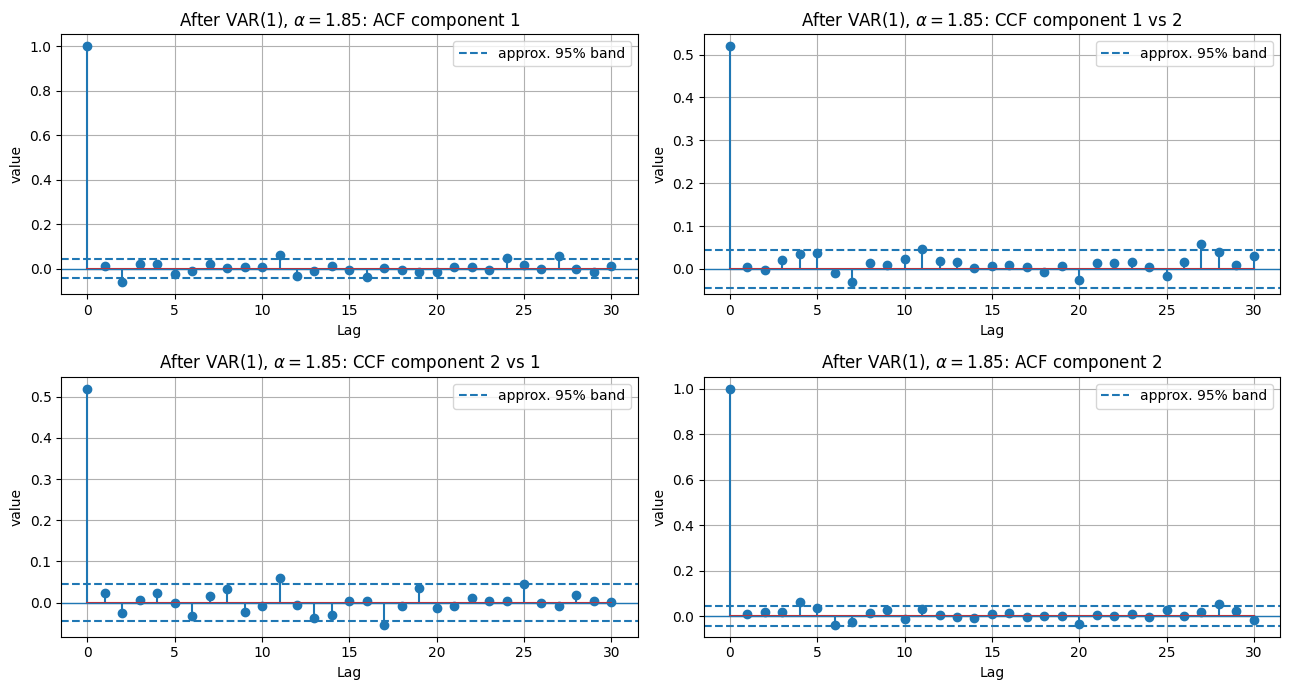

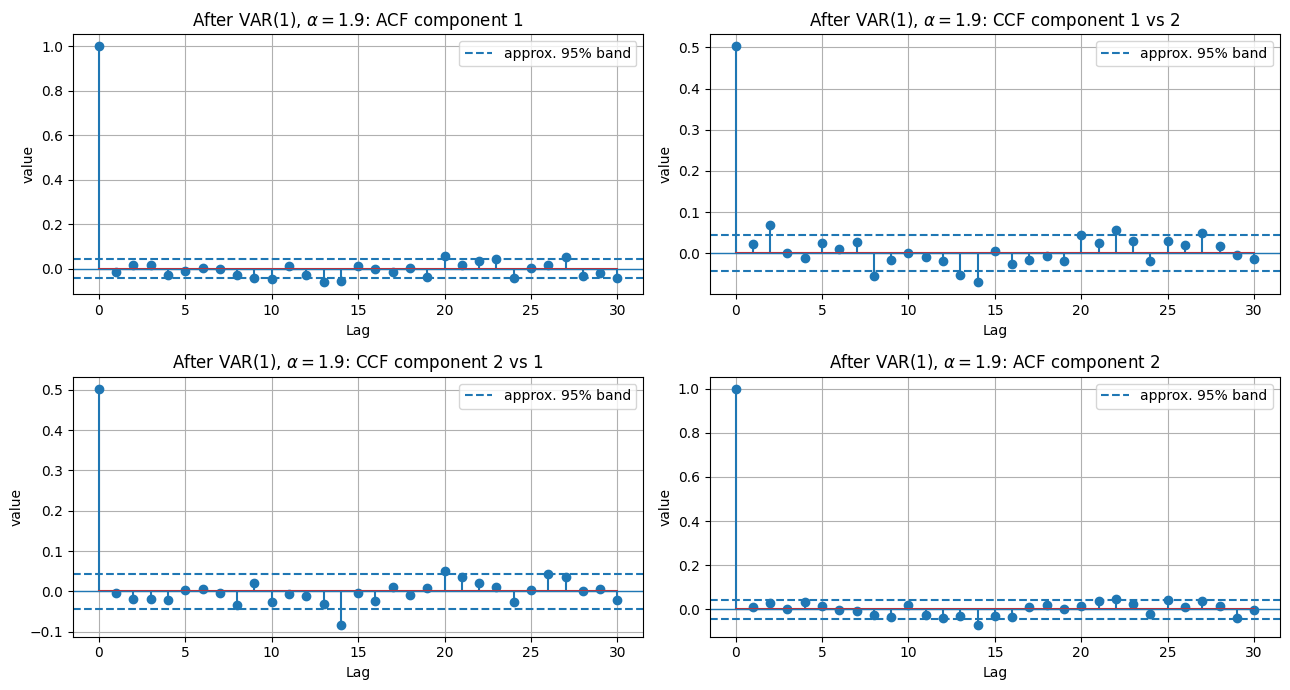

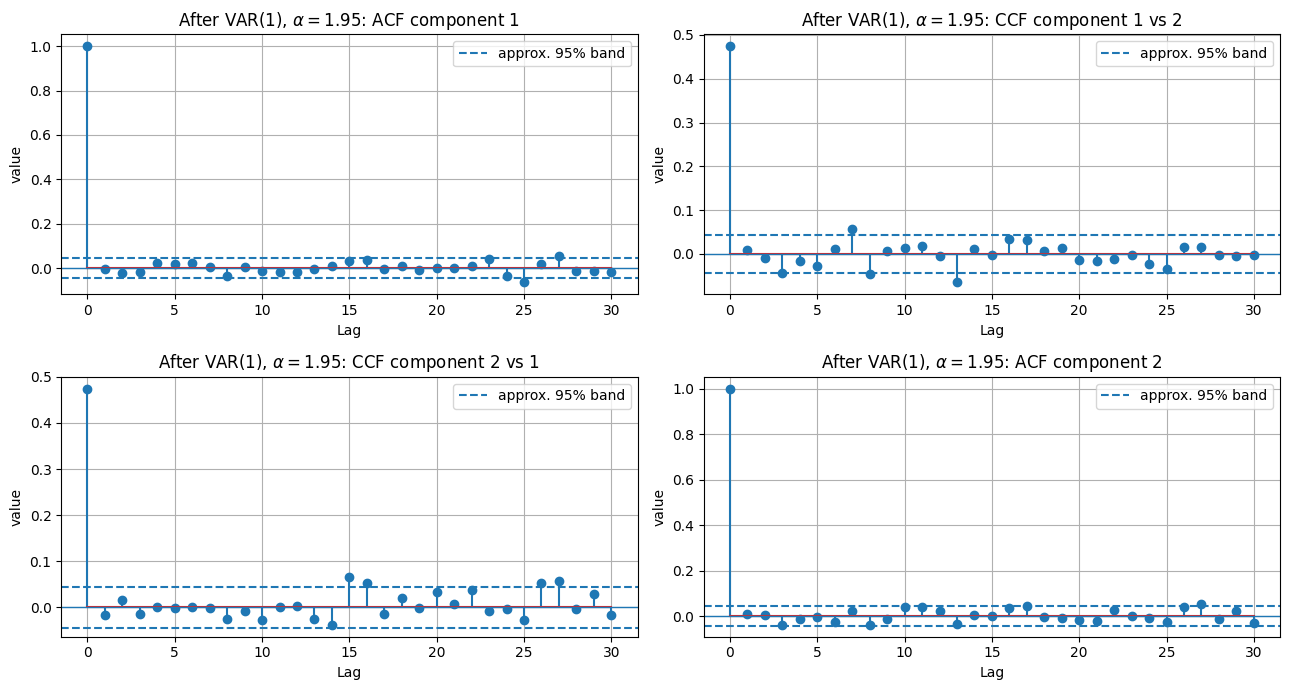

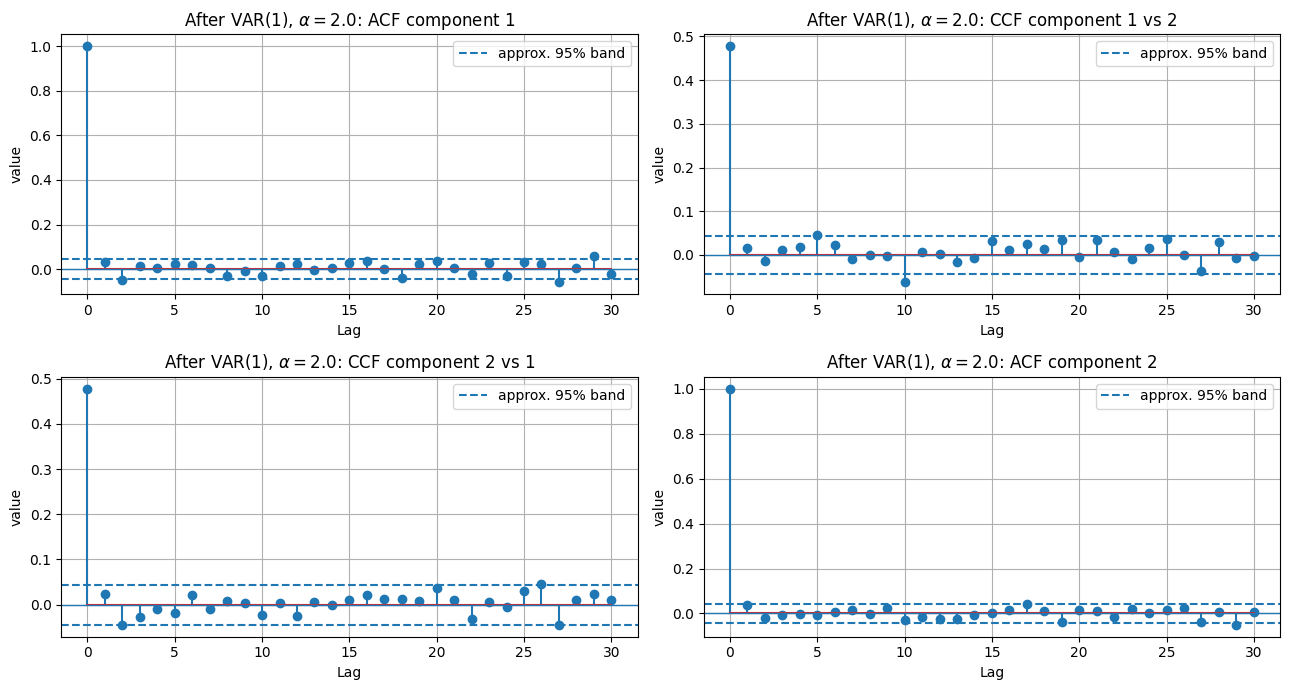

In [70]:
for alpha in MC_2D_ALPHA_VALUES:
    plotting_utils.plot_mc_2d_acf_ccf_after_var(mc_2d_final_scaled[alpha])

The autocorrelation and cross-correlation functions computed from the VAR(1) residuals indicate that the dependence structure observed before model fitting has been effectively removed. For all considered values of $\alpha$, the autocorrelation coefficients at non-zero lags remain close to zero, while the cross-correlation coefficients between the two residual components are likewise confined to the vicinity of zero and mostly lie within the 95% confidence bands. The absence of persistent temporal and cross-component dependence suggests that the fitted VAR(1) model successfully captures both the internal dynamics of each component and their mutual interactions. Consequently, the residuals exhibit the characteristics expected from an approximately uncorrelated multivariate noise process.

### 8. Stability index estimation

In [71]:
alpha_summary_2d = pd.DataFrame([
    {
        "true_alpha": alpha,
        "mean_alpha_hat": np.mean(mc_2d_final_scaled[alpha]["alpha_hats"]),
        "median_alpha_hat": np.median(mc_2d_final_scaled[alpha]["alpha_hats"]),
        "std_alpha_hat": np.std(mc_2d_final_scaled[alpha]["alpha_hats"], ddof=1),
        "mean_alpha_1_hat": np.mean(mc_2d_final_scaled[alpha]["alpha_1_hats"]),
        "mean_alpha_2_hat": np.mean(mc_2d_final_scaled[alpha]["alpha_2_hats"]),
        "n_replications": MC_2D_REPLICATIONS,
    }
    for alpha in MC_2D_ALPHA_VALUES
])

alpha_summary_2d

,true_alpha,mean_alpha_hat,median_alpha_hat,std_alpha_hat,mean_alpha_1_hat,mean_alpha_2_hat,n_replications
0,1.85,1.853972,1.852878,0.046767,1.852139,1.855805,100
1,1.90,1.886680,1.890752,0.047744,1.887711,1.885649,100
2,1.95,1.941391,1.939242,0.042502,1.941119,1.941662,100
3,2.00,1.967227,1.974637,0.032468,1.965264,1.969190,100


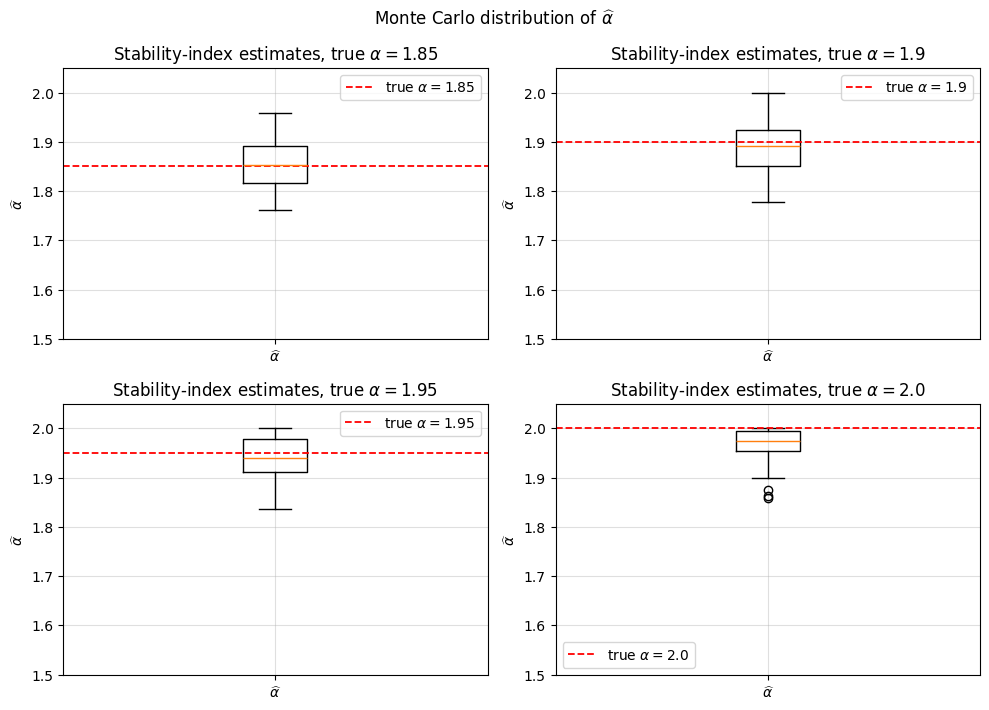

In [72]:
plotting_utils.plot_mc_2d_alpha_boxplots(
    mc_2d_final_scaled,
    MC_2D_ALPHA_VALUES,
)

The Monte Carlo distributions of the estimated stability index remain concentrated around the corresponding true values for all considered values of $\alpha$. The medians are consistently close to the reference parameters, while the relatively small interquartile ranges indicate good estimation precision. A slight bias can be observed in some scenarios, with the largest deviation occurring for the Gaussian case ($\alpha = 2$), where the estimator tends to produce mildly lower values. Nevertheless, these discrepancies remain small compared with the overall variability, demonstrating that the proposed procedure provides accurate and stable estimates of the stability index over the entire range of considered noise distributions.

### 9. Sigma estimation

In [73]:
if USE_CACHED_2D_MC and MC_2D_SIGMA_CACHE.exists() and not RECOMPUTE_2D_MC:
    with open(MC_2D_SIGMA_CACHE, "rb") as f:
        mc_2d_final_sigma = pickle.load(f)
    print(f"Loaded 2D Sigma Monte Carlo results from {MC_2D_SIGMA_CACHE}")
else:
    mc_2d_final_sigma = {}

    for idx, alpha in enumerate(MC_2D_ALPHA_VALUES):
        print(f"Running 2D Monte Carlo with Sigma estimation for alpha={alpha}...")
        mc_2d_final_sigma[alpha] = run_mc_2d_for_alpha(
            alpha=alpha,
            base_params_2d=base_params_2d,
            n_replications=MC_2D_REPLICATIONS,
            base_seed=40_000 + idx * 10_000,
            trend_window=MC_2D_TREND_WINDOW,
            scale_window=MC_2D_SCALE_WINDOW,
            h_max=MC_2D_H_MAX,
            scale_multiplier=scale_multiplier_2d,
            estimate_sigma=True,
        )

    mc_2d_final_sigma = monte_carlo_utils.prepare_final_sigma_estimates(
        mc_2d_final_sigma,
        MC_2D_ALPHA_VALUES,
        trim_edges=100,
    )

    with open(MC_2D_SIGMA_CACHE, "wb") as f:
        pickle.dump(mc_2d_final_sigma, f)

    print(f"Computed and saved 2D Sigma Monte Carlo results to {MC_2D_SIGMA_CACHE}")

if any("Sigma_hats_final" not in mc_2d_final_sigma[alpha] for alpha in MC_2D_ALPHA_VALUES):
    mc_2d_final_sigma = monte_carlo_utils.prepare_final_sigma_estimates(
        mc_2d_final_sigma,
        MC_2D_ALPHA_VALUES,
        trim_edges=100,
    )

Running 2D Monte Carlo with Sigma estimation for alpha=1.85...
Running 2D Monte Carlo with Sigma estimation for alpha=1.9...
Running 2D Monte Carlo with Sigma estimation for alpha=1.95...
Running 2D Monte Carlo with Sigma estimation for alpha=2.0...
Computed and saved 2D Sigma Monte Carlo results to mc_2d_sigma_results_VAR1_M100_alpha_185_190_195_200.pkl


In [75]:
sigma_summary_2d = monte_carlo_utils.final_sigma_summary(
    mc_2d_final_sigma,
    MC_2D_ALPHA_VALUES,
    Sigma_true,
)

sigma_summary_2d

,true_alpha,mean_sigma_11,median_sigma_11,true_sigma_11,mean_sigma_12,median_sigma_12,true_sigma_12,mean_sigma_21,median_sigma_21,true_sigma_21,mean_sigma_22,median_sigma_22,true_sigma_22
0,1.85,0.640351,0.636694,0.64,0.321182,0.319036,0.32,0.321182,0.319036,0.32,0.644775,0.642397,0.64
1,1.90,0.639784,0.640598,0.64,0.318295,0.318807,0.32,0.318295,0.318807,0.32,0.645151,0.645720,0.64
2,1.95,0.641328,0.637132,0.64,0.321054,0.319177,0.32,0.321054,0.319177,0.32,0.642425,0.644625,0.64
3,2.00,0.644524,0.642719,0.64,0.320682,0.318621,0.32,0.320682,0.318621,0.32,0.641894,0.644209,0.64


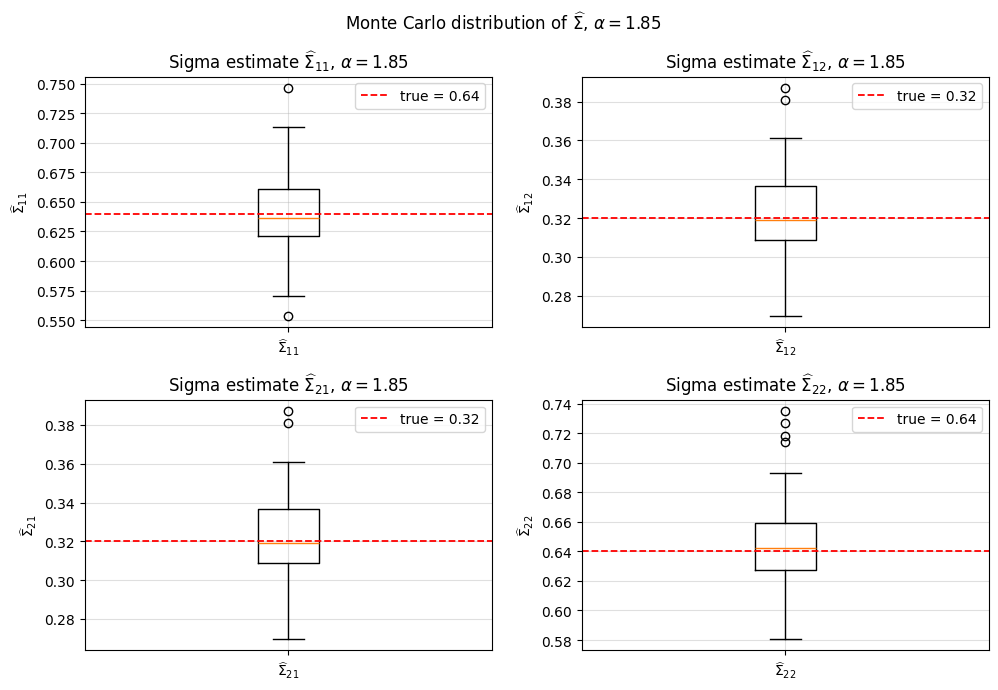

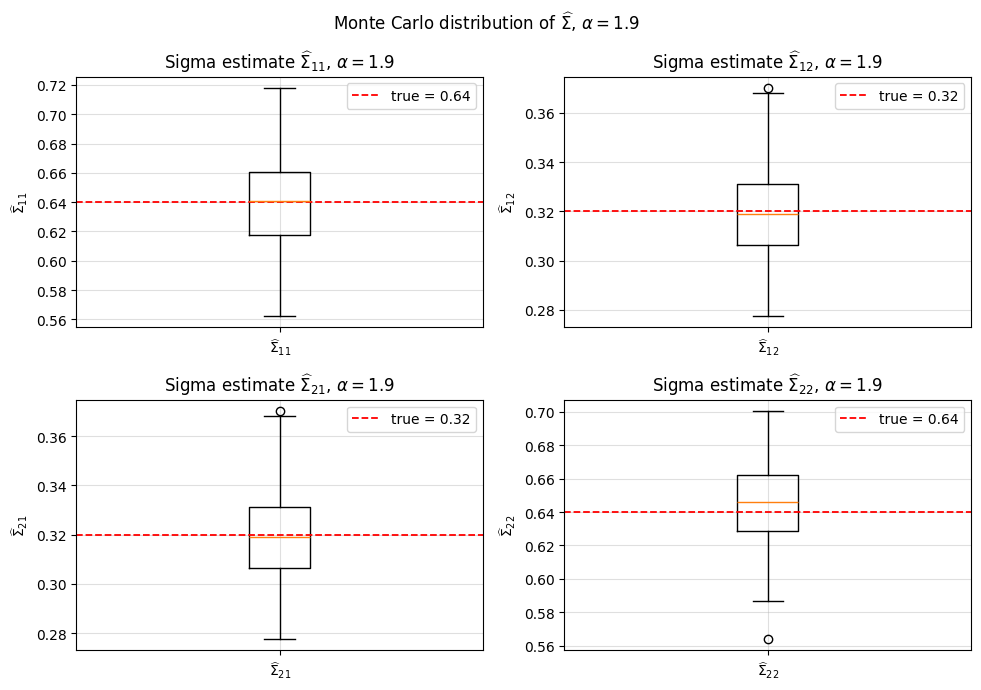

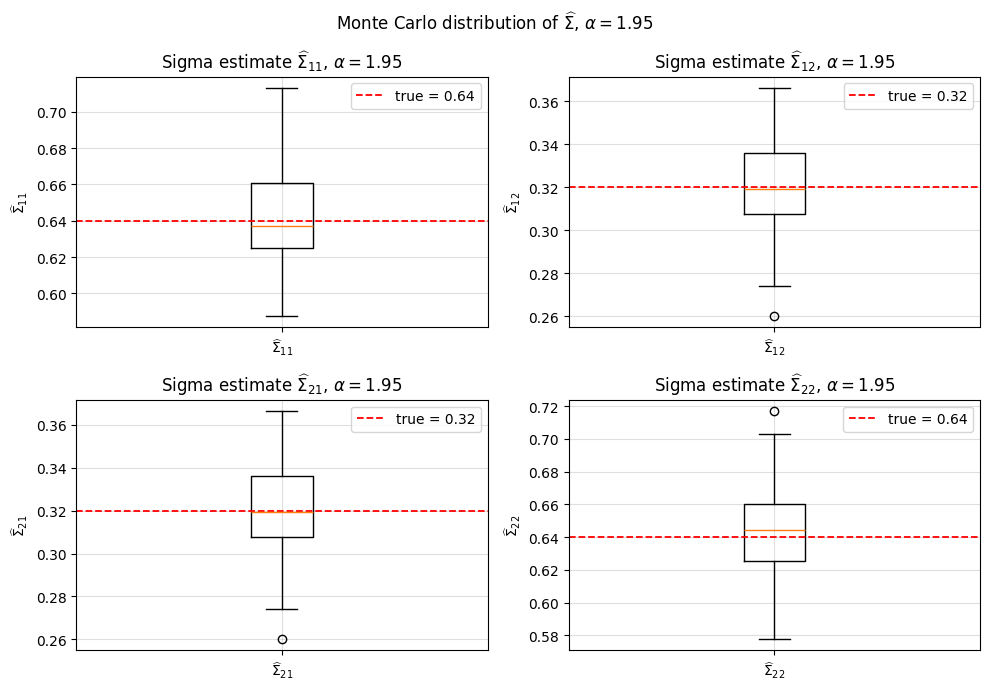

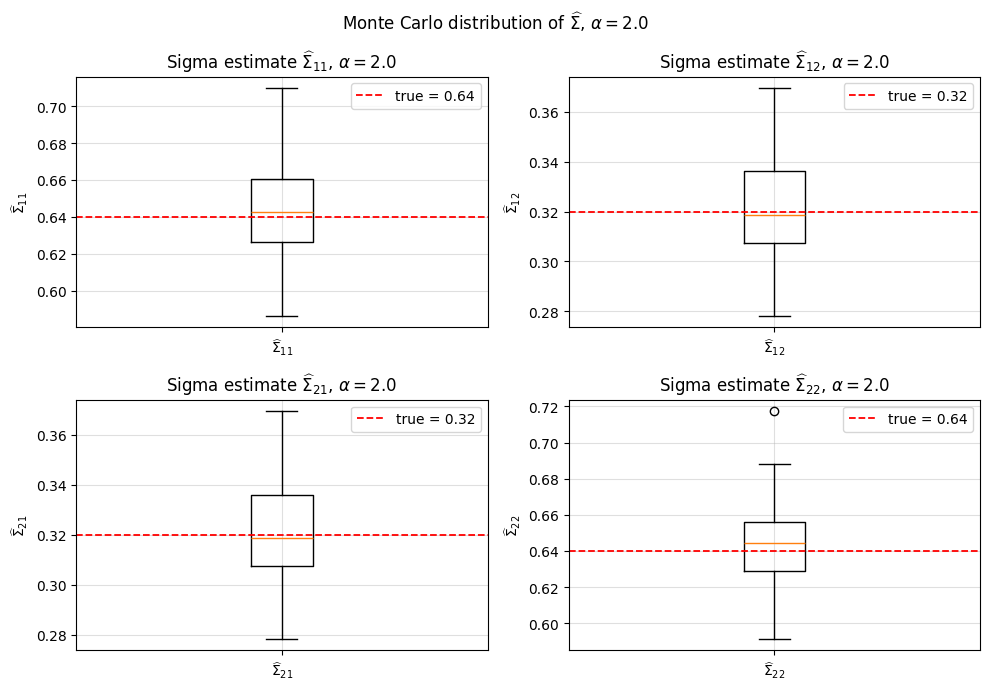

In [76]:
for alpha in MC_2D_ALPHA_VALUES:
    plotting_utils.plot_mc_2d_sigma_boxplots(mc_2d_final_sigma[alpha])

The Monte Carlo distributions of the estimated covariance matrix entries remain centered close to their corresponding true values for all considered values of $\alpha$. The medians closely coincide with the reference parameters, while the relatively compact interquartile ranges indicate stable estimation of both the diagonal and off-diagonal elements of $\Sigma$. Although a small number of outliers is visible, particularly for the diagonal entries, no systematic overestimation or underestimation can be observed across the considered scenarios. These results demonstrate that the covariance structure of the Gaussian vector underlying the sub-Gaussian noise is accurately recovered by the proposed estimation procedure.

-----

## Real data analysis: IMS bearing dataset

In this part, we apply the proposed multidimensional model to real vibration data from the IMS bearing dataset. The dataset was collected by the Center for Intelligent Maintenance Systems at the University of Cincinnati during a run-to-failure experiment.

The experimental setup consisted of four double-row bearings mounted on a common rotating shaft. The shaft worked under constant speed and constant load, while vibration signals were recorded using accelerometers placed on the bearing housings.

In this analysis, we use data from Bearing 1:

* `Subset1_Bearing1_Channel1`,
* `Subset1_Bearing1_Channel2`.

Each channel contains 2156 one-second vibration segments. Every segment consists of 20480 measurements recorded with a sampling frequency of 20 kHz.

To transform the raw vibration signals into health-index data, we calculate the RMS value for every segment in both channels. This gives a two-dimensional health index:

$$
S(t) =
\begin{pmatrix}
S_1(t) \
S_2(t)
\end{pmatrix},
$$

where $S_1(t)$ and $S_2(t)$ describe the degradation process observed from two vibration channels of the same bearing.

The goal of this part is to check whether the multidimensional degradation model can describe real run-to-failure data. In particular, we want to capture the increasing trend, increasing variability, dependence between channels, and possible heavy-tailed fluctuations present in practical diagnostic signals.

### 1. Health index construction

In [77]:
import real_data_analysis

importlib.reload(real_data_analysis)

from estimation2d import estimate_2d_model_fixed_var_order
from real_data_analysis import (
    load_ims_bearing1_rms,
    prepare_trimmed_hi,
    moving_block_bootstrap_diagnostics_ci,
    simulate_varp_paths_from_estimate,
    quantile_band_coverage,
)

IMS_FOLDER = Path("ims/1st_test/1st_test")
IMS_CACHE = Path("ims_set1_bearing1_rms_hi.csv")
REAL_DATA_START_INDEX = 245

ims_hi_df, ims_metadata = load_ims_bearing1_rms(
    ims_folder=IMS_FOLDER,
    cache_path=IMS_CACHE,
    force_recompute=False,
)

real_data_available = not ims_hi_df.empty
hi_real = np.empty((0, 2))
ims_trimmed_df = pd.DataFrame()
t_real = np.array([])

if real_data_available:
    hi_real, ims_trimmed_df = prepare_trimmed_hi(
        ims_hi_df,
        start_index=REAL_DATA_START_INDEX,
    )
    t_real = np.arange(1, len(hi_real) + 1)

ims_summary = pd.DataFrame([{
    "loaded_from": ims_metadata["loaded_from"],
    "raw_file_count": ims_metadata["raw_file_count"],
    "first_file_channels": ims_metadata["first_file_channels"],
    "first_file_rows": ims_metadata["first_file_rows"],
    "raw_HI_shape": tuple(ims_hi_df[["S1", "S2"]].shape) if real_data_available else None,
    "analysis_start_index": REAL_DATA_START_INDEX if real_data_available else None,
    "analysis_HI_shape": tuple(hi_real.shape) if real_data_available else None,
    "first_timestamp": ims_trimmed_df["timestamp"].iloc[0] if real_data_available else None,
    "last_timestamp": ims_trimmed_df["timestamp"].iloc[-1] if real_data_available else None,
}])

ims_summary

,loaded_from,raw_file_count,first_file_channels,first_file_rows,raw_HI_shape,analysis_start_index,analysis_HI_shape,first_timestamp,last_timestamp
0,cache,2156,8,20480,"(2156, 2)",245,"(1911, 2)",2003-10-31 01:49:46,2003-11-25 23:39:56


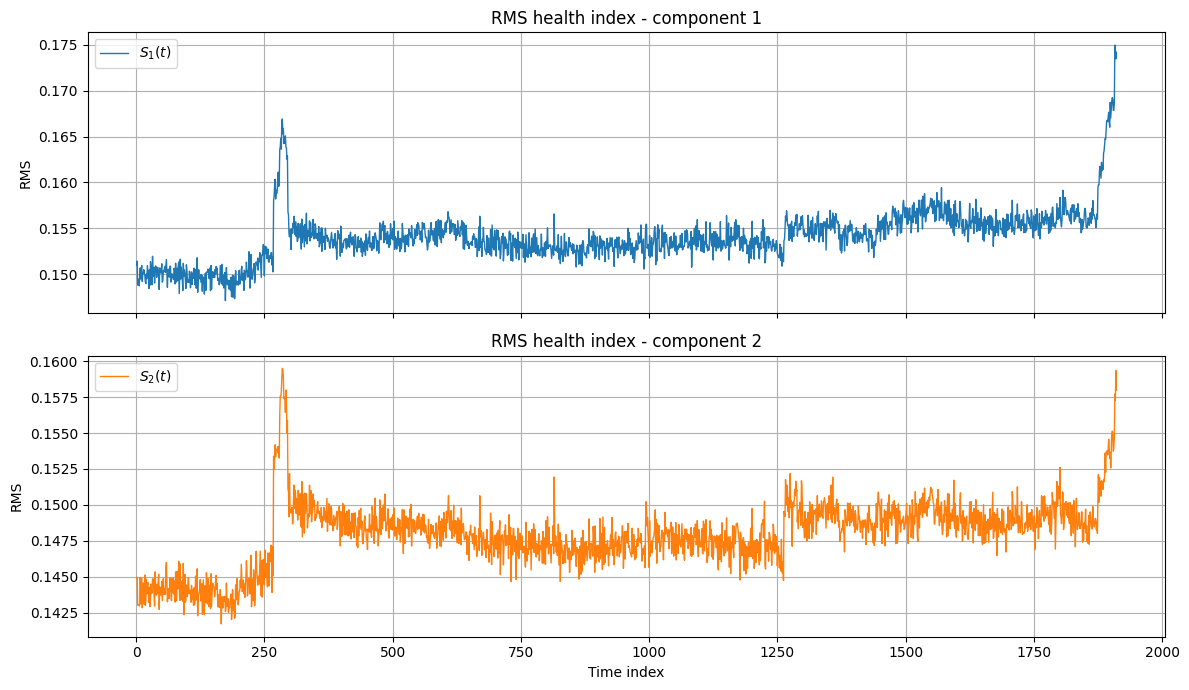

In [78]:
if real_data_available:
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    axes[0].plot(t_real, hi_real[:, 0], label=r"$S_1(t)$", linewidth=1)
    axes[0].set_title("RMS health index - component 1")
    axes[0].set_ylabel("RMS")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(t_real, hi_real[:, 1], label=r"$S_2(t)$", linewidth=1, color="tab:orange")
    axes[1].set_title("RMS health index - component 2")
    axes[1].set_xlabel("Time index")
    axes[1].set_ylabel("RMS")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()
else:
    pd.DataFrame({"message": ["IMS data are not available. Set IMS_FOLDER or provide the RMS cache CSV."]})

The health index remains low for a large part of the experiment and increases strongly near the end of the bearing lifetime. This behaviour is consistent with a degradation process in which both the level and variability of the vibration feature increase as the machine approaches failure.

### 2. Decomposition and normalization

In [79]:
REAL_TREND_WINDOW = 101
REAL_SCALE_WINDOW = 51
REAL_VAR_ORDER = 6
REAL_H_MAX = 20
REAL_DATA_ESTIMATE_SIGMA = True

real_est = None

if real_data_available:
    real_est = estimate_2d_model_fixed_var_order(
        hi_real,
        p=REAL_VAR_ORDER,
        trend_window=REAL_TREND_WINDOW,
        scale_window=REAL_SCALE_WINDOW,
        h_max=REAL_H_MAX,
        compute_diagnostics=True,
        estimate_sigma=REAL_DATA_ESTIMATE_SIGMA,
        sigma_grid_size=7,
        sigma_grid_max=3.0,
        sigma_maxiter=300,
    )

real_data_settings = pd.DataFrame([{
    "trend_window": REAL_TREND_WINDOW,
    "scale_window": REAL_SCALE_WINDOW,
    "VAR_order": REAL_VAR_ORDER,
    "acf_ccf_max_lag": REAL_H_MAX,
    "estimate_sigma": REAL_DATA_ESTIMATE_SIGMA,
    "n_observations": len(hi_real),
}])

real_data_settings

,trend_window,scale_window,VAR_order,acf_ccf_max_lag,estimate_sigma,n_observations
0,101,51,6,20,True,1911


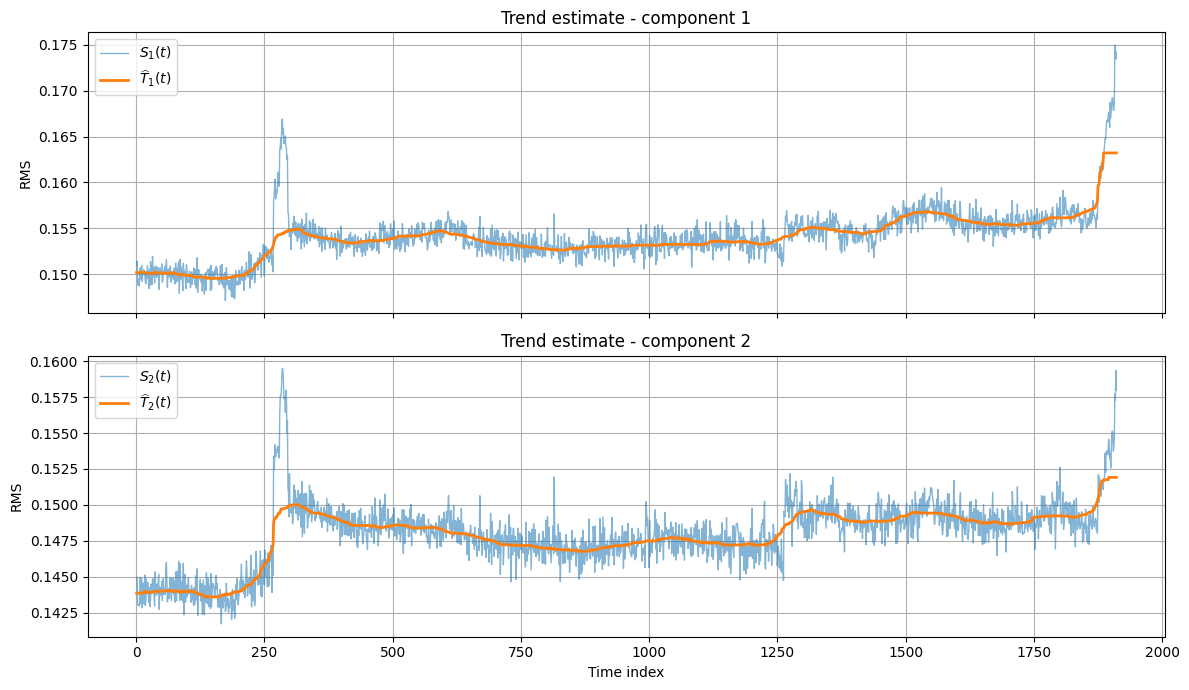

In [80]:
if real_est is not None:
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    axes[0].plot(t_real, hi_real[:, 0], label=r"$S_1(t)$", linewidth=1, alpha=0.55)
    axes[0].plot(t_real, real_est["T_hat"][:, 0], label=r"$\widehat{T}_1(t)$", linewidth=2)
    axes[0].set_title("Trend estimate - component 1")
    axes[0].set_ylabel("RMS")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(t_real, hi_real[:, 1], label=r"$S_2(t)$", linewidth=1, alpha=0.55)
    axes[1].plot(t_real, real_est["T_hat"][:, 1], label=r"$\widehat{T}_2(t)$", linewidth=2)
    axes[1].set_title("Trend estimate - component 2")
    axes[1].set_xlabel("Time index")
    axes[1].set_ylabel("RMS")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

The trend estimates capture the slow change of the health index level. They smooth out local impulses while preserving the long-term increase visible near the end of the run.

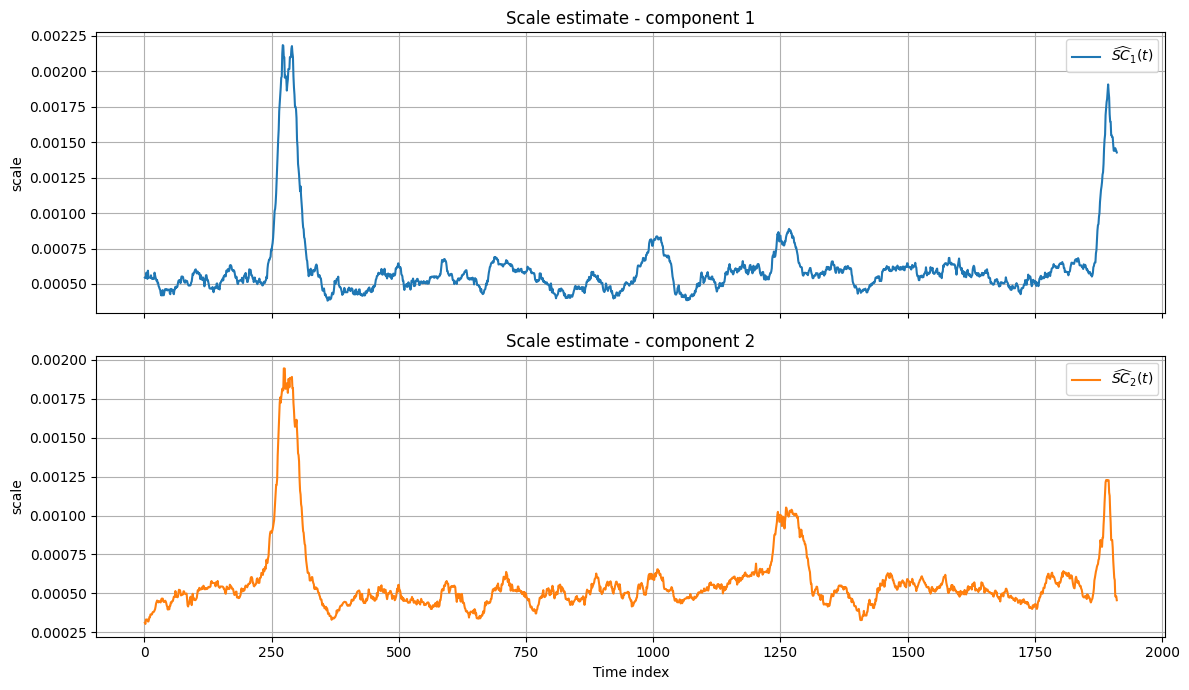

In [81]:
if real_est is not None:
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    axes[0].plot(t_real, real_est["SC_hat"][:, 0], label=r"$\widehat{SC}_1(t)$", linewidth=1.5)
    axes[0].set_title("Scale estimate - component 1")
    axes[0].set_ylabel("scale")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(t_real, real_est["SC_hat"][:, 1], label=r"$\widehat{SC}_2(t)$", linewidth=1.5, color="tab:orange")
    axes[1].set_title("Scale estimate - component 2")
    axes[1].set_xlabel("Time index")
    axes[1].set_ylabel("scale")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

The scale estimates describe the local variability of the detrended signal. Their growth indicates that the stochastic part of the health index becomes more volatile during degradation.

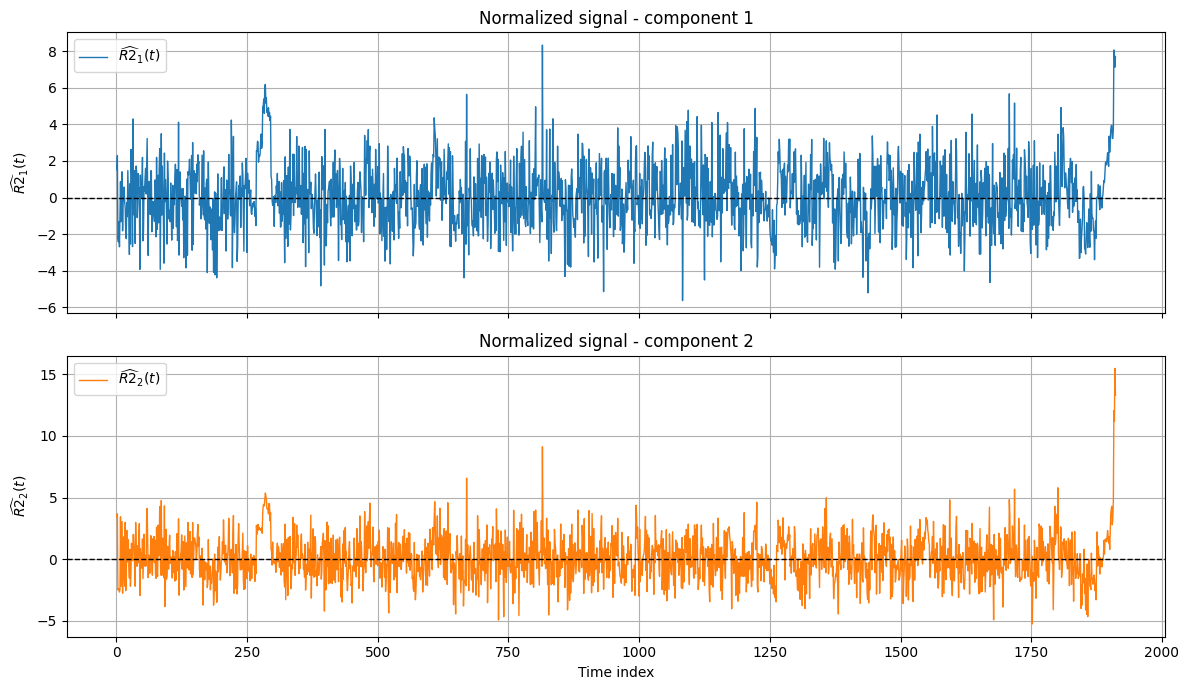

In [82]:
if real_est is not None:
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    axes[0].plot(t_real, real_est["R2_hat"][:, 0], label=r"$\widehat{R2}_1(t)$", linewidth=1)
    axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0].set_title("Normalized signal - component 1")
    axes[0].set_ylabel(r"$\widehat{R2}_1(t)$")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(t_real, real_est["R2_hat"][:, 1], label=r"$\widehat{R2}_2(t)$", linewidth=1, color="tab:orange")
    axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[1].set_title("Normalized signal - component 2")
    axes[1].set_xlabel("Time index")
    axes[1].set_ylabel(r"$\widehat{R2}_2(t)$")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

After normalization, the two components are closer to stationary signals around zero. Remaining temporal dependence is handled by the VAR model in the next steps.

### 3. Temporal-dependence diagnostics before VAR fitting

Before interpreting the VAR model, we inspect robust ACF and CCF of $\widehat{\mathbf{R2}}(t)$. These diagnostics show whether temporal dependence remains after trend removal and scale normalization. Confidence intervals are obtained with Moving Block Bootstrap, which is more appropriate for dependent time series than simple independent-sample bands.

In [89]:
MBB_REPS = 100
MBB_CACHE = Path(f"real_data_mbb_ci_VAR{REAL_VAR_ORDER}_h{REAL_H_MAX}_B{MBB_REPS}.pkl")

ci_R2 = None
ci_R3 = None

if real_est is not None:
    if MBB_CACHE.exists():
        with open(MBB_CACHE, "rb") as f:
            cached_ci = pickle.load(f)
        ci_R2 = cached_ci["ci_R2"]
        ci_R3 = cached_ci["ci_R3"]
    else:
        ci_R2 = moving_block_bootstrap_diagnostics_ci(
            real_est["R2_hat"],
            max_lags=REAL_H_MAX,
            n_reps=MBB_REPS,
            random_state=20260518,
        )
        ci_R3 = moving_block_bootstrap_diagnostics_ci(
            real_est["R3_hat"],
            max_lags=REAL_H_MAX,
            n_reps=MBB_REPS,
            random_state=20260519,
        )
        with open(MBB_CACHE, "wb") as f:
            pickle.dump(
                {
                    "ci_R2": ci_R2,
                    "ci_R3": ci_R3,
                    "MBB_REPS": MBB_REPS,
                    "REAL_H_MAX": REAL_H_MAX,
                    "REAL_VAR_ORDER": REAL_VAR_ORDER,
                },
                f,
            )

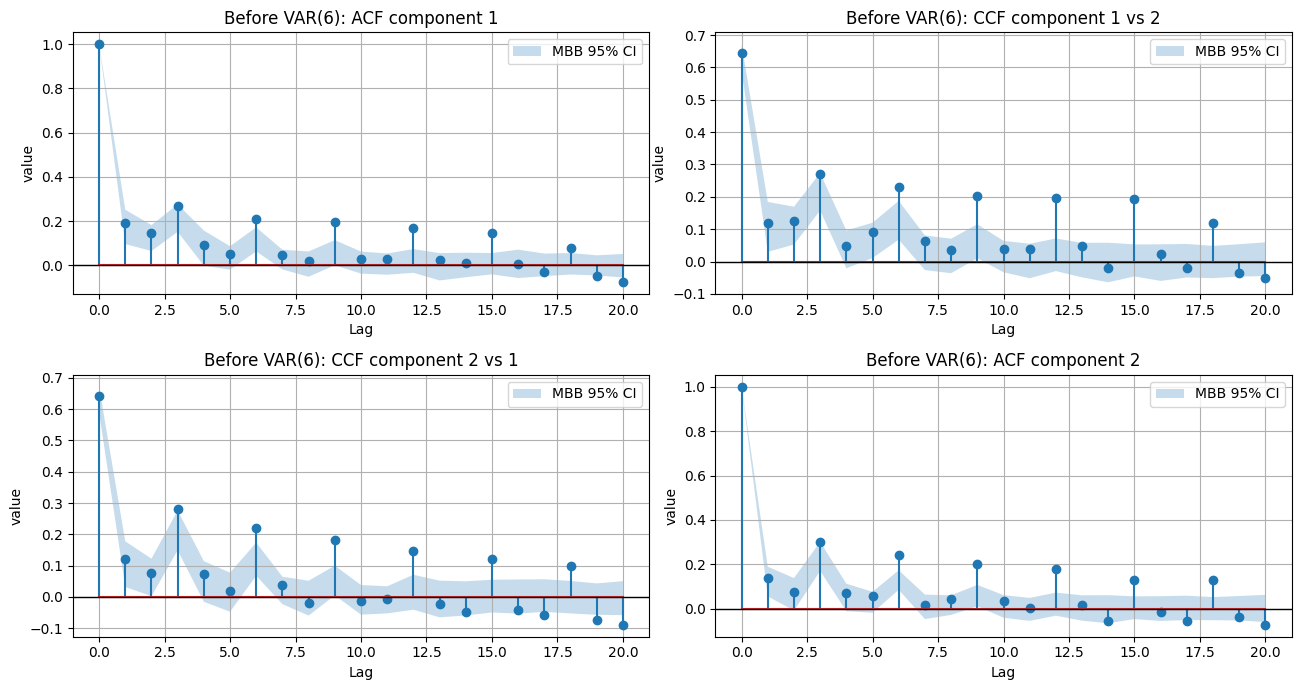

In [90]:
if real_est is not None:
    plot_real_acf_ccf_diagnostics(
        real_est["diagnostics_R2"],
        n_obs=len(real_est["R2_hat"]),
        title_prefix="Before VAR(6):",
        ci=ci_R2,
    )

The pre-VAR diagnostics show the dependence structure of the normalized process. Visible ACF/CCF values at positive lags indicate that normalization alone is not sufficient and that a VAR model is needed.

### 4. VAR fitting

A VAR(6) model is fitted to $\widehat{\mathbf{R2}}(t)$ to remove lagged temporal dependence within each component and lagged cross-dependence between components. The table below reports the six estimated VAR matrices. Each matrix multiplies the normalized signal at the corresponding lag.

In [83]:
if real_est is not None:
    theta_tables = []
    for lag, theta_lag in enumerate(real_est["Theta_hats"], start=1):
        theta_table = pd.DataFrame(
            theta_lag,
            index=pd.Index(["component 1", "component 2"], name=f"Theta_{lag}"),
            columns=["lagged component 1", "lagged component 2"],
        )
        theta_tables.append(theta_table)

    display(pd.concat(theta_tables))

,lagged component 1,lagged component 2
component 1,0.114058,0.008579
component 2,0.051961,0.057104
component 1,0.052844,0.030762
component 2,0.004226,0.034309
component 1,0.100509,0.156239
component 2,0.065865,0.214159
component 1,0.039695,-0.074844
component 2,-0.011359,-0.005426
component 1,-0.116868,0.121022
component 2,-0.062394,0.042308


The estimated VAR matrices summarize how the current normalized health-index vector depends on its recent past. This step is the real-data analogue of the AR/VAR fitting stage validated in the Monte Carlo sections.

### 5. Residuals

The residual process $\widehat{\mathbf{R3}}(t)$ is obtained after subtracting the fitted VAR(6) dependence from $\widehat{\mathbf{R2}}(t)$. These residuals represent the remaining stochastic innovation component of the real-data model.

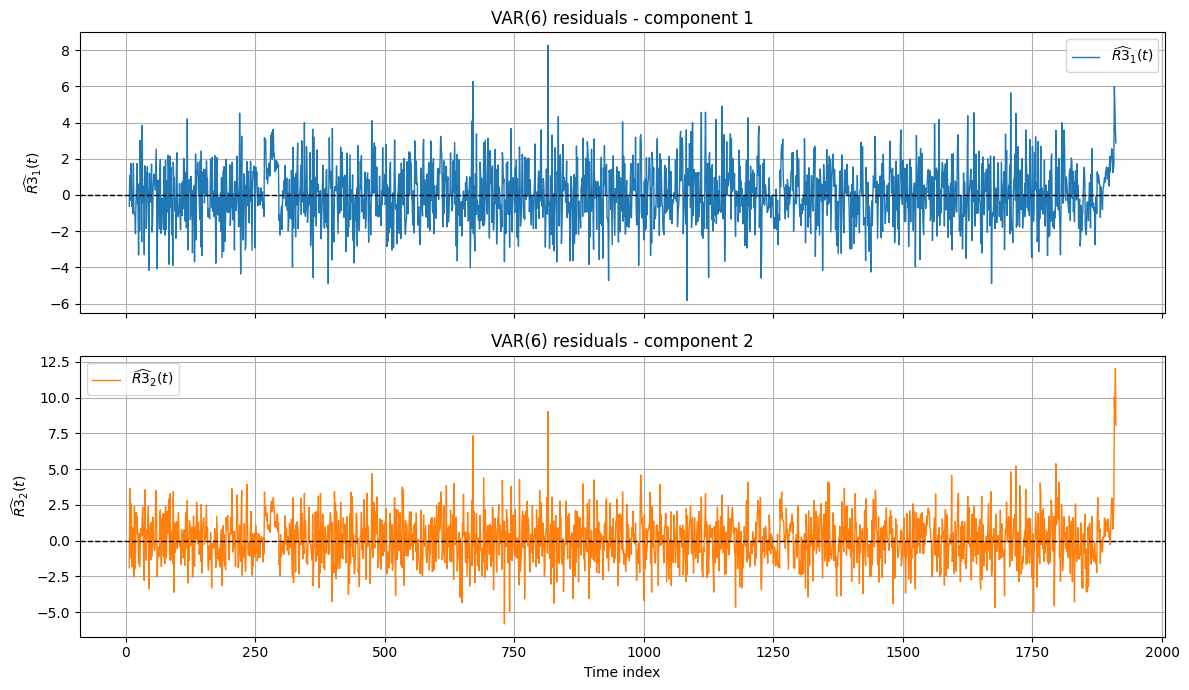

In [84]:
if real_est is not None:
    t_res = np.arange(REAL_VAR_ORDER + 1, len(hi_real) + 1)

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    axes[0].plot(t_res, real_est["R3_hat"][:, 0], label=r"$\widehat{R3}_1(t)$", linewidth=1)
    axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0].set_title("VAR(6) residuals - component 1")
    axes[0].set_ylabel(r"$\widehat{R3}_1(t)$")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(t_res, real_est["R3_hat"][:, 1], label=r"$\widehat{R3}_2(t)$", linewidth=1, color="tab:orange")
    axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[1].set_title("VAR(6) residuals - component 2")
    axes[1].set_xlabel("Time index")
    axes[1].set_ylabel(r"$\widehat{R3}_2(t)$")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

The residuals still contain impulses and heavy-tailed fluctuations, but the systematic lagged structure should be reduced compared with the normalized process before VAR fitting.

### 6. Temporal-dependence diagnostics after VAR fitting

We now repeat the robust ACF/CCF diagnostics for $\widehat{\mathbf{R3}}(t)$ using the same Moving Block Bootstrap confidence intervals. After VAR fitting, most positive-lag dependence should be reduced, so the residual process should be closer to a noise sequence.

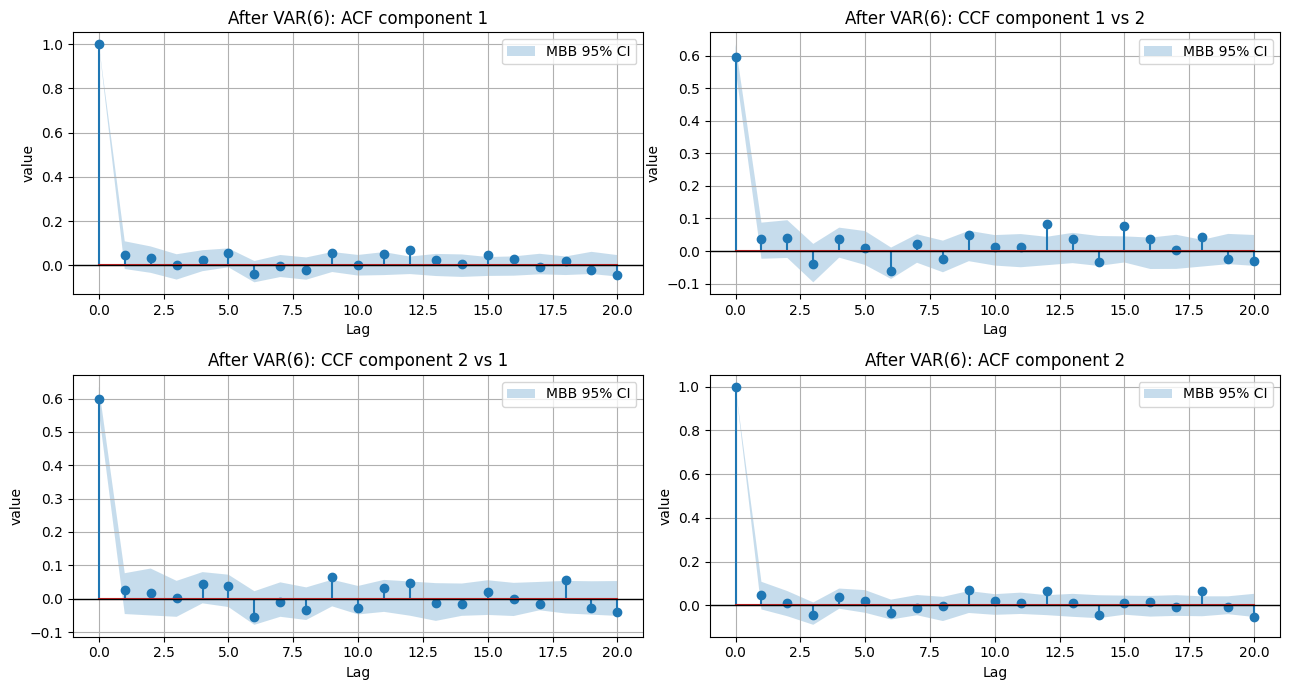

In [91]:
if real_est is not None:
    plot_real_acf_ccf_diagnostics(
        real_est["diagnostics_R3"],
        n_obs=len(real_est["R3_hat"]),
        title_prefix="After VAR(6):",
        ci=ci_R3,
    )

The post-VAR ACF/CCF plots are the main diagnostic check for the fitted temporal model. Values closer to zero at positive lags indicate that VAR(6) removed a substantial part of the serial and lagged cross-component dependence.

### 7. Distribution fitting

After VAR fitting, the residuals are treated as estimated innovations. The stability index $\alpha$ is estimated componentwise using McCulloch's quantile method and then averaged. The matrix $\Sigma$ is estimated from the residuals and describes contemporaneous dependence in the fitted sub-Gaussian innovation distribution.

In [86]:
if real_est is not None:
    distribution_summary = pd.DataFrame({
        "quantity": ["alpha_hat", "alpha_1_hat", "alpha_2_hat"],
        "estimated_value": [
            real_est["alpha_hat"],
            real_est["alpha_info"]["alpha_1"],
            real_est["alpha_info"]["alpha_2"],
        ],
    })

    display(distribution_summary)

    if real_est.get("Sigma_hat") is not None:
        sigma_hat_table = pd.DataFrame(
            real_est["Sigma_hat"],
            index=["component 1", "component 2"],
            columns=["component 1", "component 2"],
        )
        display(sigma_hat_table)

,quantity,estimated_value
0,alpha_hat,2.0
1,alpha_1_hat,2.0
2,alpha_2_hat,2.0


,component 1,component 2
component 1,2.687078,1.578848
component 2,1.578848,2.525895


The estimated $\alpha$ describes the tail heaviness of the residual innovations. The estimated $\Sigma$ matrix summarizes contemporaneous dependence between the two innovation components after lagged dependence has been removed.

### 8. Quantile-band validation

Using the parameters estimated from the real data, we simulate 100 new trajectories from the fitted model. From these simulated trajectories, we compute empirical quantile lines/bands and compare them with the observed health index. This allows us to check whether the fitted stochastic model reproduces the variability and degradation pattern observed in the real data.

In [87]:
N_REAL_SIMULATIONS = 100

real_simulations = None
q05_real = None
q95_real = None
coverage_estimated = None

if real_est is not None:
    real_simulations = simulate_varp_paths_from_estimate(
        real_est,
        n_simulations=N_REAL_SIMULATIONS,
        random_state=20260518,
    )

    q05_real = np.quantile(real_simulations, 0.05, axis=0)
    q95_real = np.quantile(real_simulations, 0.95, axis=0)
    coverage_estimated = quantile_band_coverage(hi_real, q05_real, q95_real)

coverage_estimated

,component,coverage_percent,outside_percent,n_points
0,S1,88.644689,11.355311,1911
1,S2,88.383046,11.616954,1911


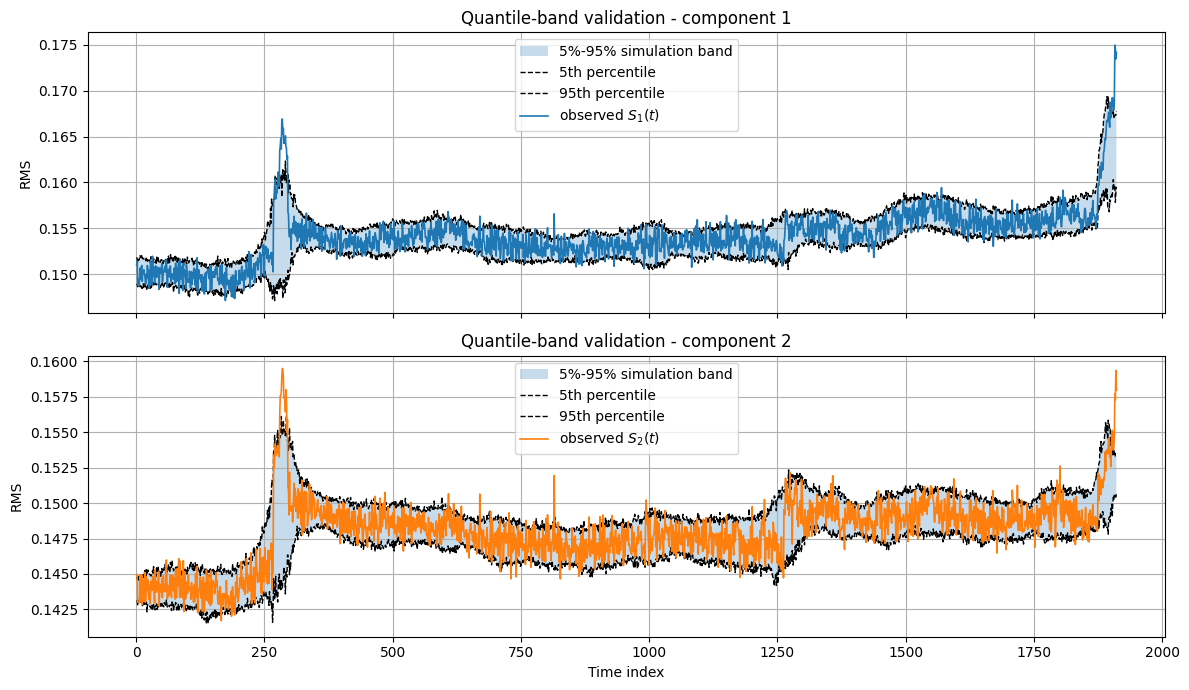

In [88]:
if real_est is not None and q05_real is not None and q95_real is not None:
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    axes[0].fill_between(t_real, q05_real[:, 0], q95_real[:, 0], alpha=0.25, label="5%-95% simulation band")
    axes[0].plot(t_real, q05_real[:, 0], color="black", linestyle="--", linewidth=1, label="5th percentile")
    axes[0].plot(t_real, q95_real[:, 0], color="black", linestyle="--", linewidth=1, label="95th percentile")
    axes[0].plot(t_real, hi_real[:, 0], color="tab:blue", linewidth=1.2, label=r"observed $S_1(t)$")
    axes[0].set_title("Quantile-band validation - component 1")
    axes[0].set_ylabel("RMS")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].fill_between(t_real, q05_real[:, 1], q95_real[:, 1], alpha=0.25, label="5%-95% simulation band")
    axes[1].plot(t_real, q05_real[:, 1], color="black", linestyle="--", linewidth=1, label="5th percentile")
    axes[1].plot(t_real, q95_real[:, 1], color="black", linestyle="--", linewidth=1, label="95th percentile")
    axes[1].plot(t_real, hi_real[:, 1], color="tab:orange", linewidth=1.2, label=r"observed $S_2(t)$")
    axes[1].set_title("Quantile-band validation - component 2")
    axes[1].set_xlabel("Time index")
    axes[1].set_ylabel("RMS")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

The coverage table reports the percentage of observed health-index values inside the simulated 5%-95% band. Coverage close to the nominal 90% level suggests that the fitted stochastic model reproduces the empirical variability reasonably well. Deviations from this level indicate parts of the real trajectory where the model underestimates or overestimates the observed variability.

-----

## Conclusions

The main goal of this work was to construct and analyze a multidimensional stochastic model for machine health indices. The motivation for this approach comes from the fact that machine degradation is usually observed through several related diagnostic signals. Modeling only one health index may lead to loss of information, while the multidimensional model allows us to describe the degradation process more completely.

The proposed model extends the one-dimensional degradation model to the multivariate case. The observed process is represented as a combination of a deterministic trend, a time-dependent scale, and a random component. This structure makes it possible to reproduce the main characteristics of health-index trajectories: non-stationarity, increasing variability, temporal dependence, cross-dependence between components, and impulsive random fluctuations.

An important part of the model is the use of sub-Gaussian noise. This assumption makes the model more flexible than the classical Gaussian approach. By changing the stability parameter $\alpha$, we can control the heaviness of the tails of the distribution. When $\alpha$ is close to 2, the noise is close to Gaussian. When $\alpha$ decreases, extreme observations become more likely. This is useful in the analysis of vibration signals, where sudden impulses often appear during machine degradation.

The multidimensional dependence structure is modeled using the VAR model. This is an important improvement over separate one-dimensional modeling, because it allows each health index to depend not only on its own past values, but also on the past values of the other components. As a result, the model can describe both temporal dependence and cross-dependence between diagnostic signals.

The simulation study confirmed that the model can generate realistic artificial degradation trajectories. The generated data reproduced the expected behavior of machine health indices: stable initial operation, visible degradation in the warning stage, and rapid deterioration in the final stage. The Monte Carlo experiment showed that the main model parameters can be estimated with good accuracy. In particular, the estimates of the VAR parameters and the stability index $\alpha$ were close to the true values in the analyzed cases.

The real data analysis showed that the methodology can also be applied to practical run-to-failure data. The IMS bearing dataset was used to construct a two-dimensional health index based on RMS values from two vibration channels. After estimating the model parameters, artificial trajectories were generated and used to build a prediction interval. The original health-index trajectory was mostly contained within this interval, which confirms that the model can capture the main behavior of the real degradation process.

However, the approach also has some limitations. First, the dependence structure is described by a linear VAR model with constant parameters. In real diagnostic signals, dependencies between components may be nonlinear or may change over time. Therefore, a simple VAR model may not fully capture all relationships present in more complex degradation processes.

Second, the trend and scale functions are assumed to have a fixed three-regime structure. This is reasonable for run-to-failure data, but in practice the number of regimes and the exact change points may not be known in advance. More automatic methods for detecting regime changes could improve the practical usability of the model.

Third, the accuracy of scale estimation depends on the stability parameter $\alpha$. The modified robust scale estimator works well for values of $\alpha$ close to 2, especially in the range commonly observed in real data. For much smaller values of $\alpha$, the estimation error may increase and additional calibration may be needed.

Another limitation is that the real-data validation was performed on one bearing dataset and two health-index components. Although the results are promising, a broader validation would be needed to confirm the robustness of the method for different machines, operating conditions, and higher-dimensional health-index vectors.

Possible extensions of this work include replacing the VAR model with more flexible structures, such as nonlinear VAR models, periodic VAR models, or models with time-varying parameters. Another direction is to develop a more adaptive procedure for estimating the scale function, especially for strongly heavy-tailed data. The method could also be extended by adding automatic change-point detection, testing different health indices, and applying the model to larger multidimensional datasets.

Overall, the results show that the proposed methodology provides a useful framework for multidimensional modeling of machine degradation. It combines stochastic modeling, robust estimation, and validation on real data. Therefore, it can be treated as a basis for further research in condition monitoring, degradation modeling, and predictive maintenance.

-----

### References